In [ ]:
import numpy as np
import  matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.arima.model import ARIMA


Bitcoin Data:
        time     high      low     open  volumefrom      volumeto    close  \
0 2019-12-18  7442.26  6450.69  6635.84    71573.09  4.914296e+08  7294.53   
1 2019-12-19  7376.98  7057.66  7294.53    34799.10  2.495419e+08  7159.26   
2 2019-12-20  7234.56  7094.06  7159.26    23556.25  1.689640e+08  7203.41   
3 2019-12-21  7213.86  7132.82  7203.41    12101.12  8.686484e+07  7159.47   
4 2019-12-22  7527.40  7143.17  7159.47    27325.26  2.005866e+08  7517.58   

  conversionType conversionSymbol  
0         direct                   
1         direct                   
2         direct                   
3         direct                   
4         direct                   
Ethereum Data:
        time    high     low    open  volumefrom      volumeto   close  \
0 2019-12-18  137.06  131.67  122.23  3030302.69  4.034096e+08  133.13   
1 2019-12-19  131.23  125.86  133.13  1979782.32  2.538523e+08  128.22   
2 2019-12-20  129.45  127.72  128.22  1172652.48  1.506117e+08  

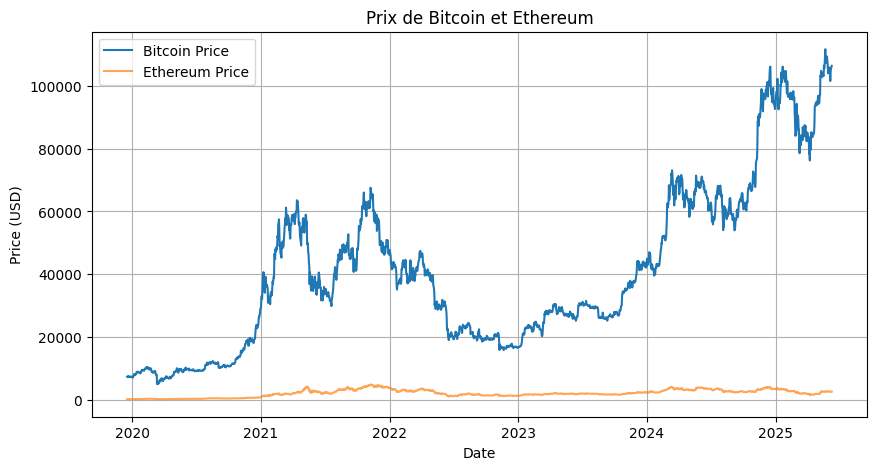

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import time

# Fonction pour récupérer les données historiques de CryptoCompare
def collect_data_crypto_compare(crypto_symbol, start_timestamp, end_timestamp):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday'
    params = {
        'fsym': crypto_symbol,  # Symbole de la cryptomonnaie (BTC ou ETH)
        'tsym': 'USD',  # Devise de comparaison
        'limit': 2000,  # Limite des jours à récupérer
        'toTs': end_timestamp,  # Timestamp de fin
        'extraParams': 'crypto_prediction'  # Paramètre optionnel pour l'identification de l'application
    }
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()['Data']['Data']
        df = pd.DataFrame(data)

        # Convertir les timestamps en dates lisibles
        df['time'] = pd.to_datetime(df['time'], unit='s')

        return df
    else:
        print(f"Erreur lors de la récupération des données: {response.status_code}")
        return None

# Obtenir la date d'aujourd'hui sous forme de timestamp
today = datetime.today()
end_timestamp = int(time.mktime(today.timetuple()))

# Exemple de timestamp pour début (en secondes)
start_timestamp = 1614556800  # (par exemple, début de l'année 2021)

# Collecter les données de Bitcoin et Ethereum
bitcoin_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
ethereum_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Vérification que les données ont été récupérées correctement
if bitcoin_data is not None:
    print("Bitcoin Data:")
    print(bitcoin_data.head())

if ethereum_data is not None:
    print("Ethereum Data:")
    print(ethereum_data.head())

# Tracer les prix de Bitcoin et Ethereum
plt.figure(figsize=(10, 5))
plt.plot(bitcoin_data['time'], bitcoin_data['close'], label='Bitcoin Price')
plt.plot(ethereum_data['time'], ethereum_data['close'], label='Ethereum Price', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Prix de Bitcoin et Ethereum')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
pip install requests

###Analyse de la corrélation :


Vérification de la volatilité moyenne sur 30 jours:
Volatilité BTC: 3.11
Volatilité ETH: 4.07

Statistiques Comparatives:
|                               |   Bitcoin |   Ethereum |
|:------------------------------|----------:|-----------:|
| Moyenne (USD)                 |  40733.57 |    2003.34 |
| Médiane (USD)                 |  35798.57 |    1891.77 |
| Écart-type (USD)              |  25900.29 |    1127.33 |
| Volatilité (rendement %)      |      3.34 |       4.40 |
| Rendement moyen quotidien (%) |      0.20 |       0.25 |
| Skewness des rendements       |     -0.51 |      -0.21 |
| Kurtosis des rendements       |     11.26 |       8.76 |
| Corrélation BTC/ETH           |      0.82 |       0.82 |
| Max Drawdown (%)              |    -76.67 |     -79.33 |
| Rendement annualisé (%)       |    103.99 |     148.76 |


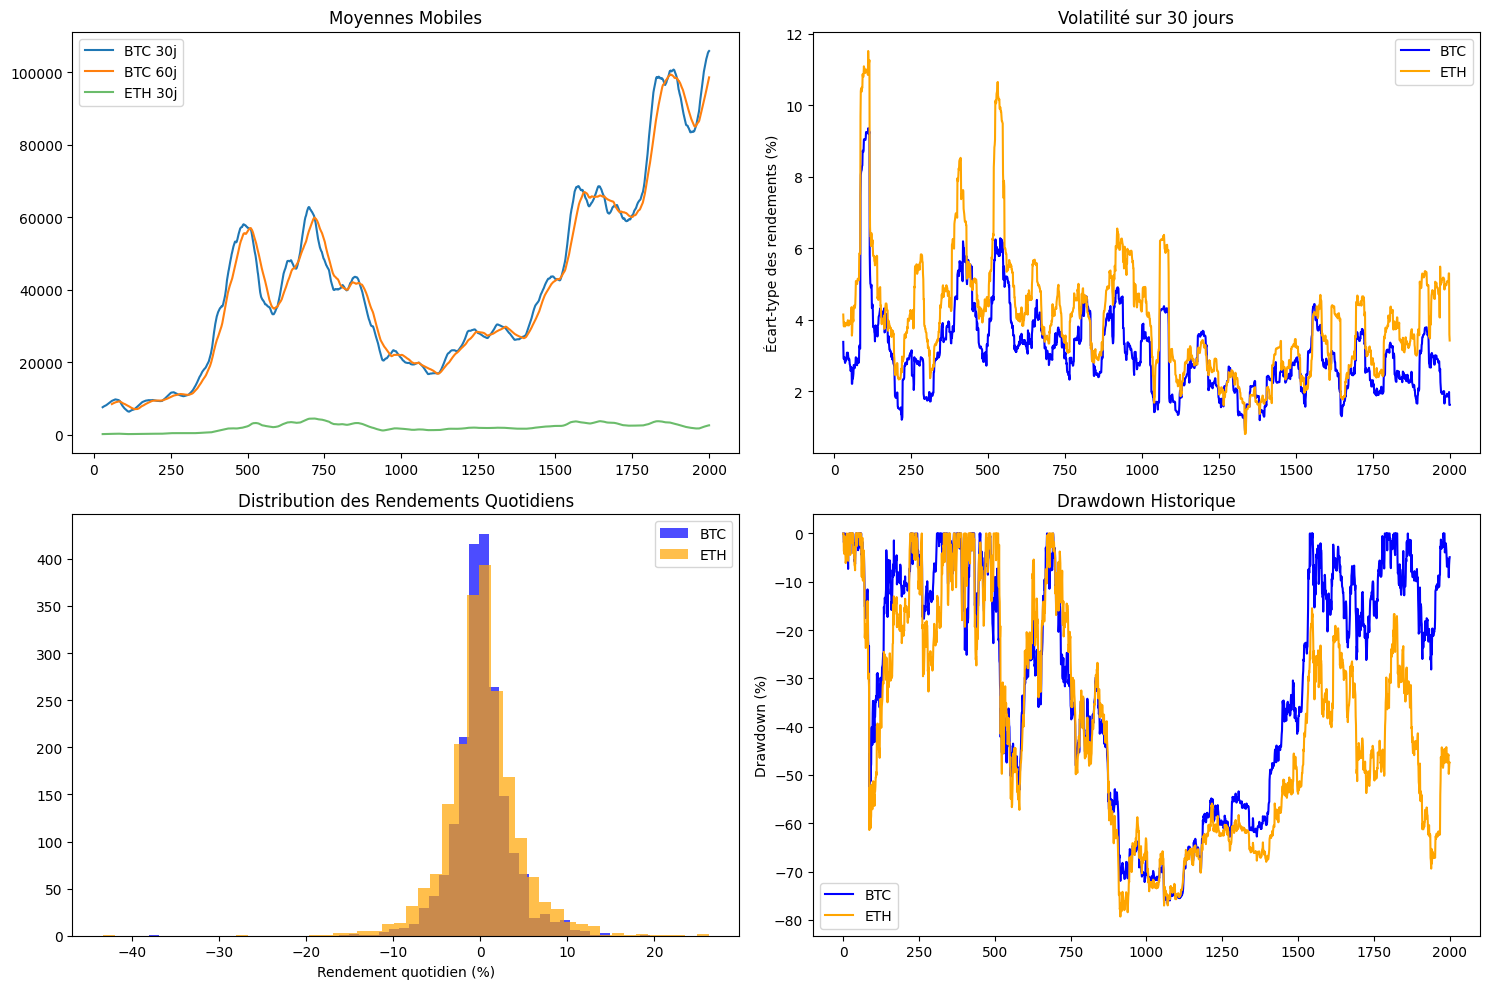

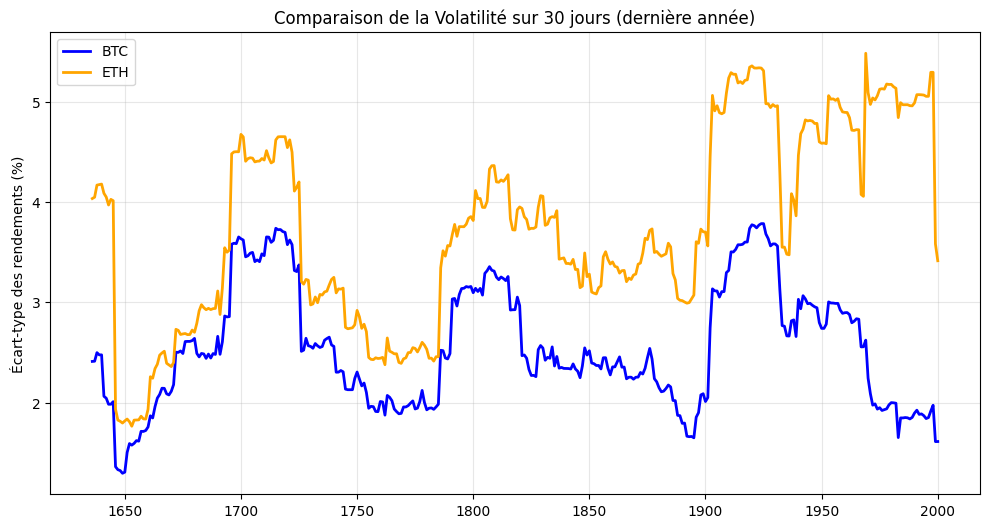

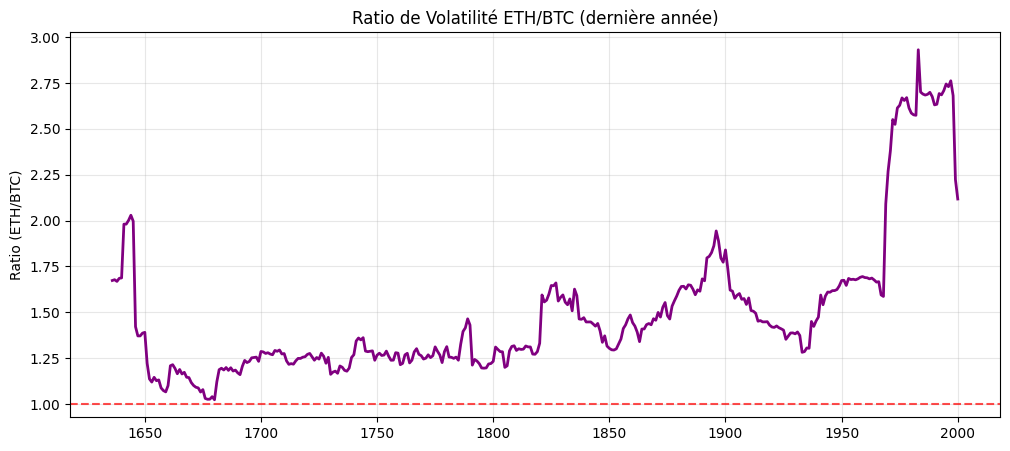


Ratio de volatilité moyen ETH/BTC: 1.33
Un ratio > 1 indique que ETH est plus volatil que BTC


In [ ]:
# =================================================================
# ANALYSE STATISTIQUE AVANCÉE
# =================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supposons que bitcoin_data et ethereum_data sont déjà chargés
# Si ce n'est pas le cas, ajoutez le code pour charger vos données ici

def calculate_statistics(df, crypto_name):
    """Calcule les statistiques avancées pour une cryptomonnaie"""
    # Création d'une copie pour éviter les avertissements de modification
    df = df.copy()

    # Calcul des rendements quotidiens
    df['daily_return'] = df['close'].pct_change() * 100

    # Statistiques descriptives
    stats = {
        'Moyenne (USD)': df['close'].mean(),
        'Médiane (USD)': df['close'].median(),
        'Écart-type (USD)': df['close'].std(),
        'Volatilité (rendement %)': df['daily_return'].std(),
        'Rendement moyen quotidien (%)': df['daily_return'].mean(),
        'Skewness des rendements': df['daily_return'].skew(),
        'Kurtosis des rendements': df['daily_return'].kurtosis(),
        'Corrélation BTC/ETH': None  # Rempli plus tard
    }

    # Calculs supplémentaires
    df['rolling_30'] = df['close'].rolling(window=30).mean()
    df['rolling_60'] = df['close'].rolling(window=60).mean()
    df['volatility_30'] = df['daily_return'].rolling(window=30).std()

    # Maximum Drawdown
    df['cumulative_max'] = df['close'].cummax()
    df['drawdown'] = (df['close'] - df['cumulative_max']) / df['cumulative_max'] * 100
    stats['Max Drawdown (%)'] = df['drawdown'].min()

    # Rendement annualisé
    annualized_return = (1 + df['daily_return'].mean()/100)**365 - 1
    stats['Rendement annualisé (%)'] = annualized_return * 100

    return stats, df

# Calcul pour les deux cryptomonnaies
btc_stats, bitcoin_data_processed = calculate_statistics(bitcoin_data, 'Bitcoin')
eth_stats, ethereum_data_processed = calculate_statistics(ethereum_data, 'Ethereum')

# Calcul de la corrélation
correlation = bitcoin_data_processed['daily_return'].corr(ethereum_data_processed['daily_return'])
btc_stats['Corrélation BTC/ETH'] = correlation
eth_stats['Corrélation BTC/ETH'] = correlation

# Vérification de la volatilité
print("\nVérification de la volatilité moyenne sur 30 jours:")
print(f"Volatilité BTC: {bitcoin_data_processed['volatility_30'].mean():.2f}")
print(f"Volatilité ETH: {ethereum_data_processed['volatility_30'].mean():.2f}")

# Création du DataFrame pour l'affichage
stats_df = pd.DataFrame([btc_stats, eth_stats], index=['Bitcoin', 'Ethereum'])
print("\nStatistiques Comparatives:")
print(stats_df.transpose().to_markdown(floatfmt=".2f"))

# =================================================================
# VISUALISATIONS COMPLÉMENTAIRES
# =================================================================

plt.figure(figsize=(15, 10))

# Moyennes mobiles
plt.subplot(2, 2, 1)
plt.plot(bitcoin_data_processed.index, bitcoin_data_processed['rolling_30'], label='BTC 30j')
plt.plot(bitcoin_data_processed.index, bitcoin_data_processed['rolling_60'], label='BTC 60j')
plt.plot(ethereum_data_processed.index, ethereum_data_processed['rolling_30'], label='ETH 30j', alpha=0.7)
plt.title('Moyennes Mobiles')
plt.legend()

# Volatilité - CORRECTION ICI
plt.subplot(2, 2, 2)
plt.plot(bitcoin_data_processed.index, bitcoin_data_processed['volatility_30'], label='BTC', color='blue')
plt.plot(ethereum_data_processed.index, ethereum_data_processed['volatility_30'], label='ETH', color='orange')
plt.title('Volatilité sur 30 jours')
plt.legend()
plt.ylabel('Écart-type des rendements (%)')

# Distribution des rendements
plt.subplot(2, 2, 3)
plt.hist(bitcoin_data_processed['daily_return'].dropna(), bins=50, alpha=0.7, label='BTC', color='blue')
plt.hist(ethereum_data_processed['daily_return'].dropna(), bins=50, alpha=0.7, label='ETH', color='orange')
plt.title('Distribution des Rendements Quotidiens')
plt.legend()
plt.xlabel('Rendement quotidien (%)')

# Drawdown
plt.subplot(2, 2, 4)
plt.plot(bitcoin_data_processed.index, bitcoin_data_processed['drawdown'], label='BTC', color='blue')
plt.plot(ethereum_data_processed.index, ethereum_data_processed['drawdown'], label='ETH', color='orange')
plt.title('Drawdown Historique')
plt.legend()
plt.ylabel('Drawdown (%)')

plt.tight_layout()
plt.savefig('crypto_analysis.png', dpi=300)
plt.show()

# Ajout d'une visualisation spécifique comparative de la volatilité
plt.figure(figsize=(12, 6))
plt.plot(bitcoin_data_processed.index[-365:], bitcoin_data_processed['volatility_30'].tail(365), label='BTC', color='blue', linewidth=2)
plt.plot(ethereum_data_processed.index[-365:], ethereum_data_processed['volatility_30'].tail(365), label='ETH', color='orange', linewidth=2)
plt.title('Comparaison de la Volatilité sur 30 jours (dernière année)')
plt.legend()
plt.ylabel('Écart-type des rendements (%)')
plt.grid(True, alpha=0.3)
plt.savefig('volatility_comparison.png', dpi=300)
plt.show()

# Ratio de volatilité ETH/BTC (pour montrer combien ETH est plus volatil que BTC)
common_dates = bitcoin_data_processed.index.intersection(ethereum_data_processed.index)
btc_vol = bitcoin_data_processed.loc[common_dates, 'volatility_30']
eth_vol = ethereum_data_processed.loc[common_dates, 'volatility_30']
volatility_ratio = eth_vol / btc_vol

plt.figure(figsize=(12, 5))
plt.plot(common_dates[-365:], volatility_ratio.tail(365), color='purple', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.7)
plt.title('Ratio de Volatilité ETH/BTC (dernière année)')
plt.ylabel('Ratio (ETH/BTC)')
plt.grid(True, alpha=0.3)
plt.savefig('volatility_ratio.png', dpi=300)
plt.show()

print(f"\nRatio de volatilité moyen ETH/BTC: {volatility_ratio.mean():.2f}")
print(f"Un ratio > 1 indique que ETH est plus volatil que BTC")

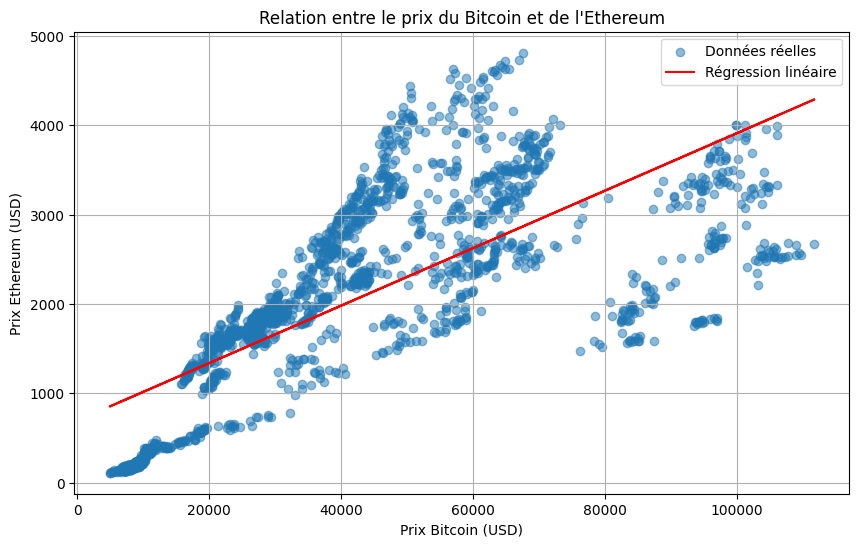

Coefficient de corrélation (pente): 0.0322
Intercept: 692.74


In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Copier les données récupérées et mettre 'time' comme index
btc = bitcoin_data.copy()
eth = ethereum_data.copy()
btc.set_index('time', inplace=True)
eth.set_index('time', inplace=True)

# Aligner les données sur les dates communes
common_index = btc.index.intersection(eth.index)
btc_prices = btc.loc[common_index]['close']
eth_prices = eth.loc[common_index]['close']

# Préparation des données pour le modèle
X = btc_prices.values.reshape(-1, 1)
y = eth_prices.values

# Régression linéaire
model = LinearRegression()
model.fit(X, y)
eth_pred = model.predict(X)

# Affichage du graphique
plt.figure(figsize=(10, 6))
plt.scatter(btc_prices, eth_prices, alpha=0.5, label='Données réelles')
plt.plot(btc_prices, eth_pred, color='red', label='Régression linéaire')
plt.xlabel('Prix Bitcoin (USD)')
plt.ylabel('Prix Ethereum (USD)')
plt.title('Relation entre le prix du Bitcoin et de l\'Ethereum')
plt.legend()
plt.grid(True)
plt.show()

# Affichage des coefficients
print(f"Coefficient de corrélation (pente): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.2f}")


<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

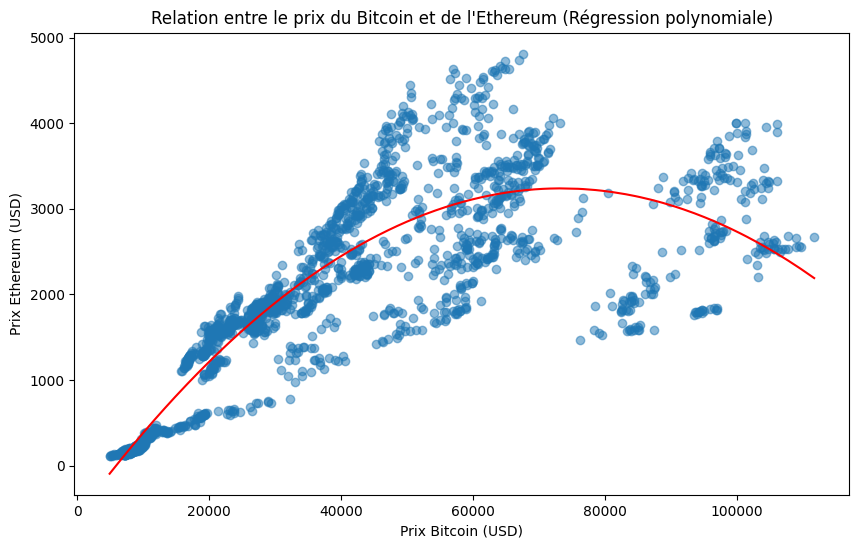

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# S'assurer que les données ont le bon index
btc = bitcoin_data.copy()
eth = ethereum_data.copy()
btc.set_index('time', inplace=True)
eth.set_index('time', inplace=True)

# Aligner les dates communes
common_index = btc.index.intersection(eth.index)
btc_prices = btc.loc[common_index]['close']
eth_prices = eth.loc[common_index]['close']

# Régression polynomiale (degré 2)
X = btc_prices.values.reshape(-1, 1)
y = eth_prices.values

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X, y)
eth_pred_poly = poly_model.predict(X)

# Tri des données pour une courbe lisse
sorted_indices = np.argsort(X.flatten())
X_sorted = X[sorted_indices]
y_sorted = eth_pred_poly[sorted_indices]

# Affichage
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Données réelles')
plt.plot(X_sorted, y_sorted, color='red', label='Régression polynomiale')
plt.xlabel('Prix Bitcoin (USD)')
plt.ylabel('Prix Ethereum (USD)')
plt.title('Relation entre le prix du Bitcoin et de l\'Ethereum (Régression polynomiale)')
plt.legend


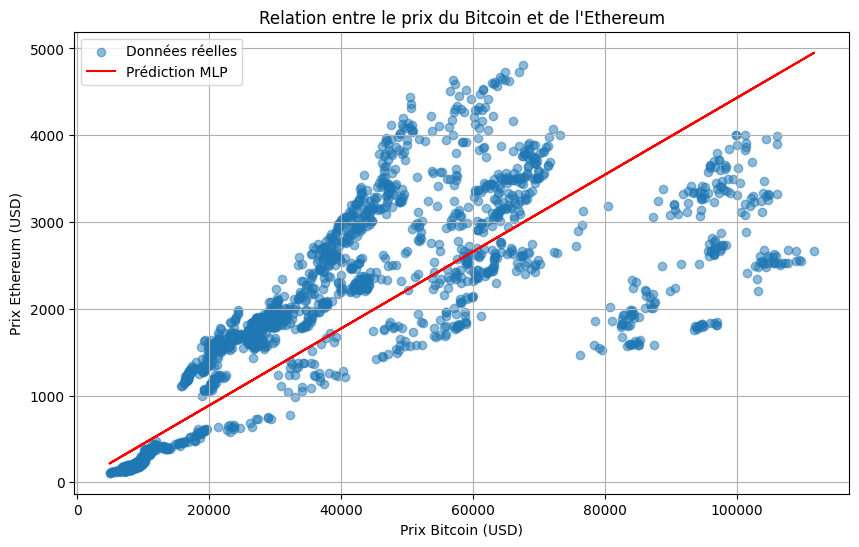

Coefficients du modèle (weights): [array([[-2.72760914e-03,  1.79327133e-01, -2.45061196e-01,
        -5.21591841e-02, -1.48492632e-01, -1.84010614e-01,
        -1.23081269e-01, -2.89717323e-02, -7.71206642e-03,
         5.32728272e-02, -2.34920673e-03,  1.00751490e-01,
        -1.11524623e-01,  2.86234660e-01, -2.26922698e-01,
         1.43712769e-01, -2.67656436e-03,  6.69303831e-02,
        -1.52622775e-01, -1.15546800e-01,  1.79948264e-01,
         2.94865503e-01, -4.59331053e-02,  1.05717253e-01,
         2.84903148e-01,  2.98534966e-01, -1.88805894e-01,
        -2.19182383e-01, -1.33602787e-01,  2.33233255e-01,
        -1.80066192e-01, -2.04217183e-03,  3.41562089e-01,
        -5.76193182e-03,  1.58362850e-01, -4.47772230e-02,
         1.54670244e-01,  2.03757017e-01, -2.32967674e-01,
         1.98380313e-01,  3.62872184e-01,  1.43930866e-01,
        -6.48470325e-02,  1.72125792e-01, -1.76866726e-01,
        -5.27156728e-05,  2.54053368e-01, -5.71550195e-02,
        -6.05450464e-

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

# Copier les données récupérées et mettre 'time' comme index
btc = bitcoin_data.copy()
eth = ethereum_data.copy()
btc.set_index('time', inplace=True)
eth.set_index('time', inplace=True)

# Aligner les données sur les dates communes
common_index = btc.index.intersection(eth.index)
btc_prices = btc.loc[common_index]['close']
eth_prices = eth.loc[common_index]['close']

# Préparation des données pour le modèle
X = btc_prices.values.reshape(-1, 1)
y = eth_prices.values

# Régression avec MLPRegressor
model = MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=1)
model.fit(X, y)

# Prédictions
eth_pred = model.predict(X)

# Affichage du graphique
plt.figure(figsize=(10, 6))
plt.scatter(btc_prices, eth_prices, alpha=0.5, label='Données réelles')
plt.plot(btc_prices, eth_pred, color='red', label='Prédiction MLP')
plt.xlabel('Prix Bitcoin (USD)')
plt.ylabel('Prix Ethereum (USD)')
plt.title('Relation entre le prix du Bitcoin et de l\'Ethereum')
plt.legend()
plt.grid(True)
plt.show()

# Affichage des coefficients
print(f"Coefficients du modèle (weights): {model.coefs_}")
print(f"Intercept: {model.intercepts_}")


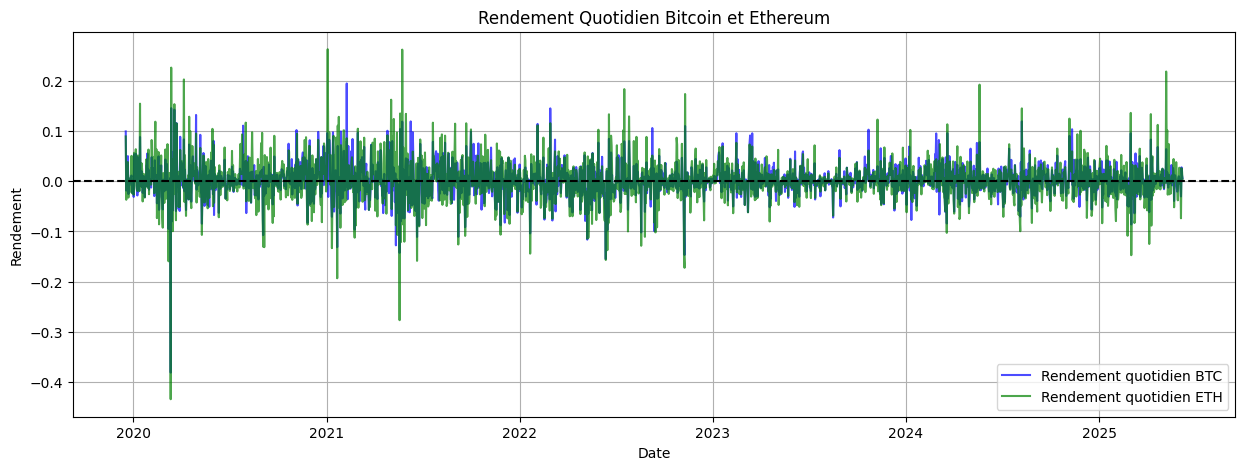

In [ ]:
# Paramètres : collecte des données
btc = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Mise en forme
btc.set_index('time', inplace=True)
eth.set_index('time', inplace=True)

# Calcul du rendement quotidien basé sur la colonne 'close'
btc_returns = btc['close'].pct_change().dropna()
eth_returns = eth['close'].pct_change().dropna()

# Aligner les dates communes
common_index = btc_returns.index.intersection(eth_returns.index)
btc_returns = btc_returns.loc[common_index]
eth_returns = eth_returns.loc[common_index]

# Tracé du rendement quotidien
plt.figure(figsize=(15, 5))
plt.plot(btc_returns, label='Rendement quotidien BTC', color='blue', alpha=0.7)
plt.plot(eth_returns, label='Rendement quotidien ETH', color='green', alpha=0.7)
plt.title('Rendement Quotidien Bitcoin et Ethereum')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Rendement')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Comparaison des statistiques descriptives
descriptive_stats = pd.DataFrame({
    'BTC': [btc_returns.mean(), btc_returns.std()],
    'ETH': [eth_returns.mean(), eth_returns.std()]
}, index=['Moyenne', 'Écart-type'])
print("\n=== Statistiques descriptives des rendements ===")
print(descriptive_stats)


=== Statistiques descriptives des rendements ===
                 BTC       ETH
Moyenne     0.001955  0.002500
Écart-type  0.033380  0.044004


In [ ]:
# Calcul de la corrélation entre les prix de clôture de Bitcoin et Ethereum : Corrélation de Pearson :
correlation = bitcoin_data['close'].corr(ethereum_data['close'])
print(f"Corrélation entre Bitcoin et Ethereum : {correlation}")


Corrélation entre Bitcoin et Ethereum : 0.7392157651915016


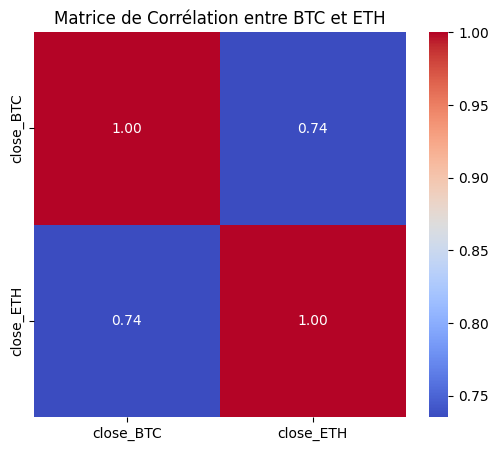

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time

# Fonction pour récupérer les données historiques de CryptoCompare
def collect_data_crypto_compare(crypto_symbol, start_timestamp, end_timestamp):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday'
    params = {
        'fsym': crypto_symbol,
        'tsym': 'USD',
        'limit': 2000,
        'toTs': end_timestamp,
        'extraParams': 'crypto_prediction'
    }
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()['Data']['Data']
        df = pd.DataFrame(data)
        df['time'] = pd.to_datetime(df['time'], unit='s')
        return df
    else:
        print(f"Erreur lors de la récupération des données: {response.status_code}")
        return None

# Obtenir la date d'aujourd'hui
today = datetime.today()
end_timestamp = int(time.mktime(today.timetuple()))
start_timestamp = 1614556800  # Début 2021

# Récupération des données
bitcoin_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
ethereum_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Fusionner sur la colonne 'time'
merged_df = pd.merge(bitcoin_data[['time', 'close']], ethereum_data[['time', 'close']], on='time', suffixes=('_BTC', '_ETH'))

# Matrice de corrélation
correlation_matrix = merged_df[['close_BTC', 'close_ETH']].corr()

# Affichage de la heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Corrélation entre BTC et ETH")
plt.show()


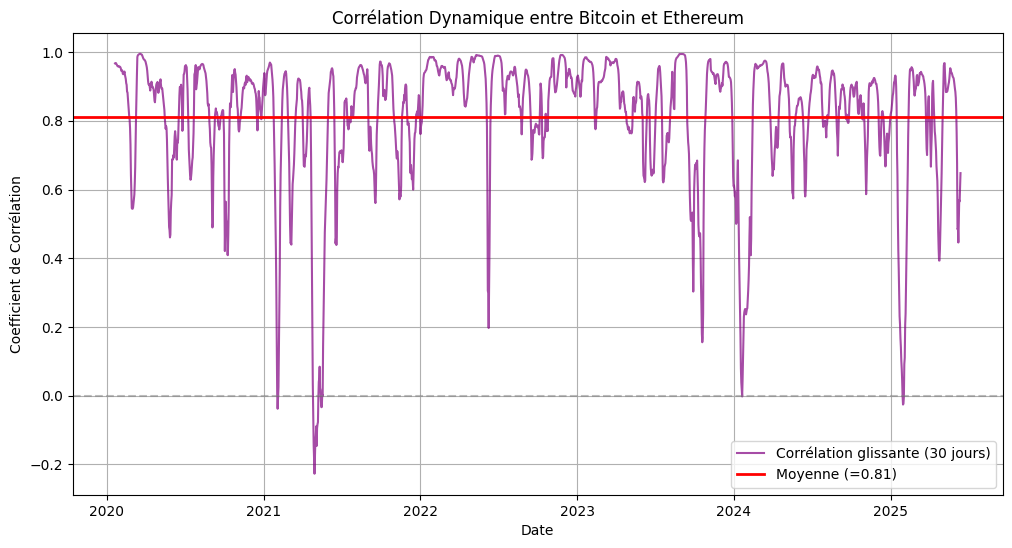

In [ ]:
# Collecte des données
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Fusion des données sur la colonne 'time'
merged_data = pd.merge(btc_data[['time', 'close']], eth_data[['time', 'close']], on='time', suffixes=('_btc', '_eth'))

# Calcul de la corrélation glissante (fenêtre de 30 jours)
# Calcul de la corrélation glissante (fenêtre de 30 jours)
window = 30
merged_data['rolling_corr'] = merged_data['close_btc'].rolling(window).corr(merged_data['close_eth'])

# Calcul de la moyenne de la corrélation
mean_correlation = merged_data['rolling_corr'].mean()

# Tracé de la corrélation dynamique + moyenne
plt.figure(figsize=(12, 6))
plt.plot(merged_data['time'], merged_data['rolling_corr'], label=f'Corrélation glissante ({window} jours)', color='purple', alpha=0.7)
plt.axhline(y=mean_correlation, color='red', linestyle='-', label=f'Moyenne (={mean_correlation:.2f})', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Coefficient de Corrélation')
plt.title('Corrélation Dynamique entre Bitcoin et Ethereum')
plt.legend()
plt.grid(True)
plt.show()

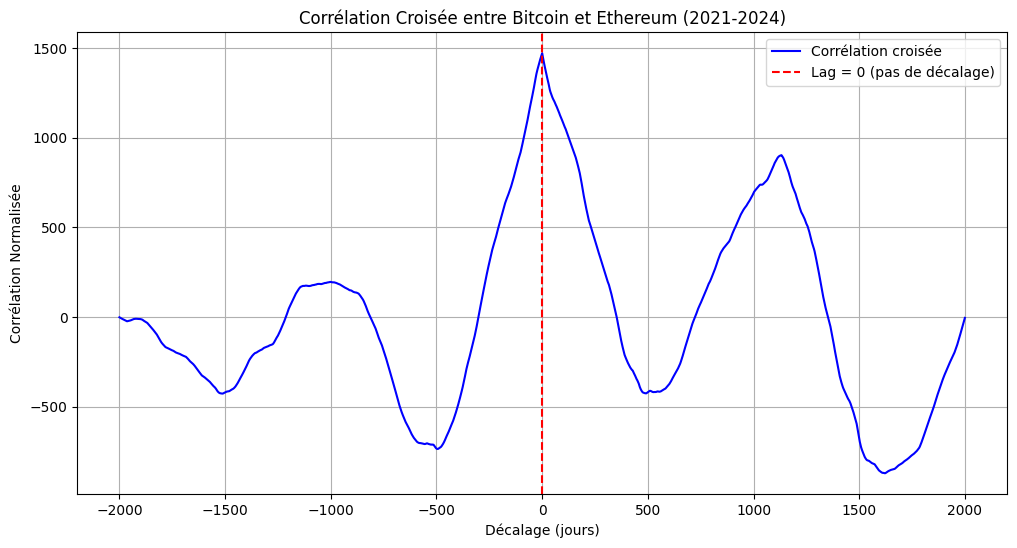

Corrélation maximale: 1471.41 à un décalage de 0 jours.


In [ ]:

# Téléchargement des données
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# 2. Nettoyage et alignement des séries temporelles
btc_prices = btc_data['close'].values
eth_prices = eth_data['close'].values

# Normalisation (pour une corrélation comparable)
btc_normalized = (btc_prices - np.mean(btc_prices)) / np.std(btc_prices)
eth_normalized = (eth_prices - np.mean(eth_prices)) / np.std(eth_prices)

# 3. Calcul de la corrélation croisée
cross_corr = np.correlate(btc_normalized, eth_normalized, mode='full')
lags = np.arange(-len(btc_prices) + 1, len(btc_prices))  # Décalages en jours

# 4. Visualisation
plt.figure(figsize=(12, 6))
plt.plot(lags, cross_corr, label='Corrélation croisée', color='blue')
plt.axvline(x=0, color='red', linestyle='--', label='Lag = 0 (pas de décalage)')
plt.xlabel('Décalage (jours)')
plt.ylabel('Corrélation Normalisée')
plt.title('Corrélation Croisée entre Bitcoin et Ethereum (2021-2024)')
plt.grid(True)
plt.legend()
plt.show()

# 5. Analyse des pics
max_corr = np.max(cross_corr)
best_lag = lags[np.argmax(cross_corr)]
print(f"Corrélation maximale: {max_corr:.2f} à un décalage de {best_lag} jours.")

# Analyse du Diagramme de Corrélation Croisée (BTC/ETH - 2021-2024)

## 1. Description du Graphique
Le graphique montre la **corrélation croisée normalisée** entre les prix de Bitcoin (BTC) et Ethereum (ETH) pour des décalages temporels (*lags*) allant de **-2000 à +2000 jours** (environ 5.5 ans).  

- **Axe X (*Lag*)** :  
  - `Lag = 0` : Corrélation instantanée (pas de décalage).  
  - `Lag > 0` : BTC précède ETH.  
  - `Lag < 0` : ETH précède BTC.  
- **Axe Y** : Coefficient de corrélation normalisé (de -1 à 1).  

---

## 2. Observations Clés
### **Pic central à Lag = 0**  
- La corrélation est **maximale** (proche de 1), indiquant que BTC et ETH évoluent de manière synchrone sans délai.  
- *Interprétation* : Les deux cryptos réagissent simultanément aux mêmes événements de marché (ex: tendances macroéconomiques).  

### **Symétrie globale**  
- Le graphique est approximativement symétrique autour de `Lag = 0`, suggérant qu'**aucune crypto ne domine systématiquement l'autre** sur le long terme.  

### **Absence de pics secondaires**  
- Aucun pic significatif n'apparaît pour `Lag ≠ 0`, ce qui signifie qu'il n'y a pas de **dépendance temporelle décalée** (ex: BTC n'influence pas ETH avec un délai fixe).  

---

## 3. Implications pour le Trading
- **Diversification limitée** : La forte corrélation instantanée réduit l'intérêt de détenir BTC et ETH pour diversifier un portefeuille.  
- **Stratégies court-termistes** : Privilégiez des indicateurs haute fréquence (ex: données on-chain) plutôt que des décalages temporels pour anticiper les mouvements.  

---

## 4. Limitations
- **Période analysée** : Les données couvrent 2021–2024, une période de marché haussier puis baissier. Des analyses par sous-périodes (ex: bull/bear markets) pourraient révéler des dynamiques différentes.  
- **Normalisation** : La corrélation est calculée sur des prix normalisés, masquant les amplitudes réelles des variations.  

---

### **Résumé**  
*"BTC et ETH sont fortement corrélés sans délai, ce qui suggère des réactions synchrones aux chocs de marché, mais aucun lead-lag significatif."*  


=== Test de causalité de Granger (BTC -> ETH) ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.2997  , p=0.2544  , df_denom=1996, df_num=1
ssr based chi2 test:   chi2=1.3017  , p=0.2539  , df=1
likelihood ratio test: chi2=1.3013  , p=0.2540  , df=1
parameter F test:         F=1.2997  , p=0.2544  , df_denom=1996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.8229  , p=0.4393  , df_denom=1993, df_num=2
ssr based chi2 test:   chi2=1.6500  , p=0.4382  , df=2
likelihood ratio test: chi2=1.6493  , p=0.4384  , df=2
parameter F test:         F=0.8229  , p=0.4393  , df_denom=1993, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.5253  , p=0.2060  , df_denom=1990, df_num=3
ssr based chi2 test:   chi2=4.5920  , p=0.2042  , df=3
likelihood ratio test: chi2=4.5867  , p=0.2047  , df=3
parameter F test:         F=1.5253  , p=0.2060  , df_denom=1990, df_num=3

Granger Causality
number of lags (no 

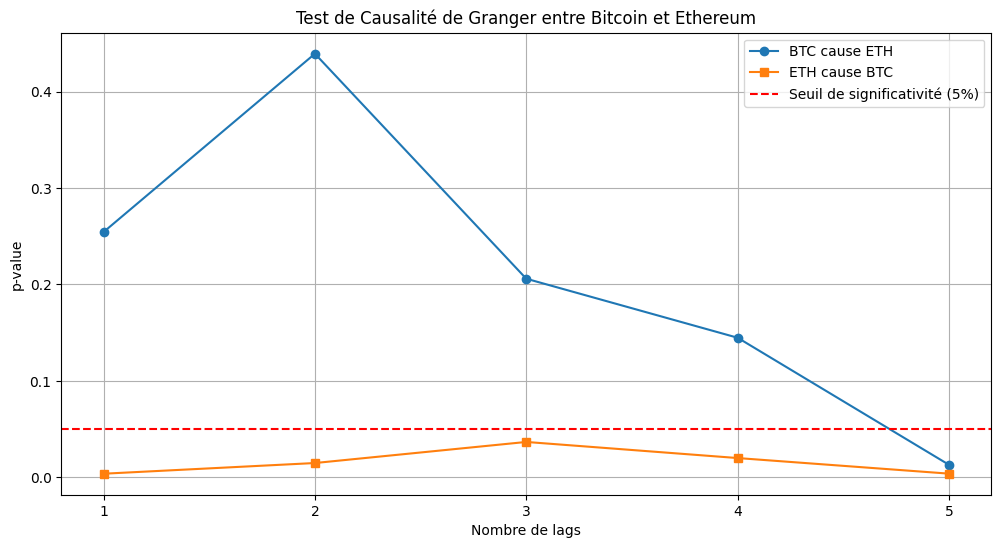

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
from datetime import datetime
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR


start_timestamp = 1614556800
end_timestamp = int(time.time())

#  Téléchargement des données
btc_df = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_df = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Nettoyage et préparation
btc = btc_df['close']
eth = eth_df['close']
data = pd.concat([btc, eth], axis=1)
data.columns = ['Bitcoin', 'Ethereum']
data = data.dropna()

# Différenciation pour stationnarité
data_diff = data.diff().dropna()

#Test de Granger
print("=== Test de causalité de Granger (BTC -> ETH) ===")
granger_btc_eth = grangercausalitytests(data_diff[['Ethereum', 'Bitcoin']], maxlag=5, verbose=True)

print("\n=== Test de causalité de Granger (ETH -> BTC) ===")
granger_eth_btc = grangercausalitytests(data_diff[['Bitcoin', 'Ethereum']], maxlag=5, verbose=True)

# Extraction des p-values
def extract_pvalues(results, maxlag):
    return [results[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]

pvals_btc_eth = extract_pvalues(granger_btc_eth, 5)
pvals_eth_btc = extract_pvalues(granger_eth_btc, 5)

# Visualisation des p-values
plt.figure(figsize=(12, 6))
plt.plot(range(1, 6), pvals_btc_eth, marker='o', label='BTC cause ETH')
plt.plot(range(1, 6), pvals_eth_btc, marker='s', label='ETH cause BTC')
plt.axhline(y=0.05, color='red', linestyle='--', label='Seuil de significativité (5%)')
plt.title('Test de Causalité de Granger entre Bitcoin et Ethereum')
plt.xlabel('Nombre de lags')
plt.ylabel('p-value')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True)
plt.show()

#  Modèle VAR
model = VAR


Corrélations avec différents lags :
Lag 1 : Corrélation = 0.5832
Lag 2 : Corrélation = 0.5830
Lag 3 : Corrélation = 0.5827
Lag 4 : Corrélation = 0.5818
Lag 5 : Corrélation = 0.5811
Lag 6 : Corrélation = 0.5804
Lag 7 : Corrélation = 0.5797
Lag 8 : Corrélation = 0.5788
Lag 9 : Corrélation = 0.5782
Lag 10 : Corrélation = 0.5771


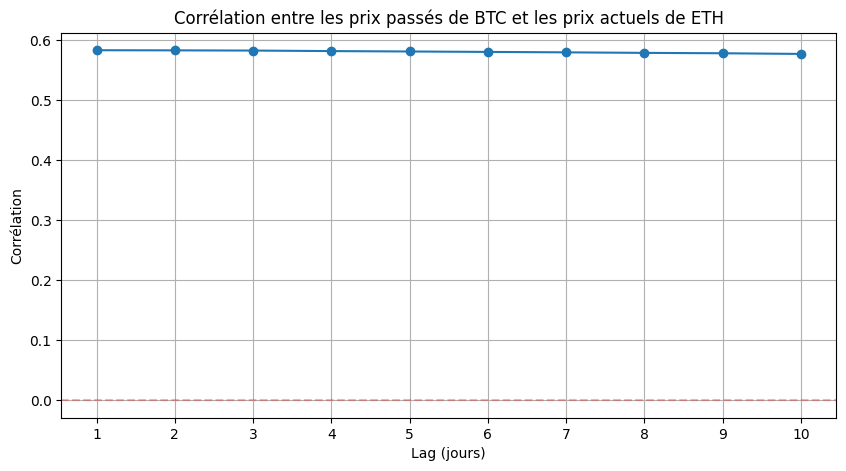

In [ ]:
# Récupérer les données
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Vérification des colonnes et de la non-nullité
if (
    btc_data is not None and not btc_data.empty and 'time' in btc_data.columns and
    eth_data is not None and not eth_data.empty and 'time' in eth_data.columns
):
    # Filtrer les données selon le timestamp de début
    btc_data = btc_data[btc_data['time'] >= pd.to_datetime(start_timestamp, unit='s')]
    eth_data = eth_data[eth_data['time'] >= pd.to_datetime(start_timestamp, unit='s')]

    # Fusionner sur la colonne 'time'
    merged = pd.merge(
        btc_data[['time', 'close']],
        eth_data[['time', 'close']],
        on='time',
        suffixes=('_btc', '_eth')
    )

    # Trier par date
    merged.sort_values('time', inplace=True)

    # Extraire les séries de prix
    btc_prices = merged['close_btc']
    eth_prices = merged['close_eth']

    # Calcul et affichage des corrélations avec lags
    print("Corrélations avec différents lags :")
    lags = range(1, 11)
    correlations = []
    for lag in lags:
        # Calcul correct : c'est BTC qui doit être décalé pour voir
        # si les prix passés du BTC prédisent les prix actuels de ETH
        shifted_btc = btc_prices.shift(lag)
        corr = eth_prices.corr(shifted_btc)
        correlations.append(corr)
        print(f"Lag {lag} : Corrélation = {corr:.4f}")

    # Tracer la courbe
    plt.figure(figsize=(10, 5))
    plt.plot(lags, correlations, marker='o', linestyle='-')
    plt.title("Corrélation entre les prix passés de BTC et les prix actuels de ETH")
    plt.xlabel("Lag (jours)")
    plt.ylabel("Corrélation")
    plt.grid(True)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)  # Ligne de référence à zéro
    plt.xticks(lags)
    plt.show()
else:
    print("Erreur : Données BTC ou ETH manquantes, vides, ou sans colonne 'time'.")

In [ ]:
from statsmodels.tsa.api import VAR

# Préparer les données pour le modèle VAR
data = pd.concat([bitcoin_data['close'], ethereum_data['close']], axis=1)
data.columns = ['Bitcoin', 'Ethereum']

# Créer un modèle VAR
model = VAR(data)
model_fitted = model.fit(5)  # Ajuster le modèle avec un nombre de lags (ici 5)

# Résumé du modèle
print(model_fitted.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 08, Jun, 2025
Time:                     17:14:10
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    22.8022
Nobs:                     1996.00    HQIC:                   22.7631
Log likelihood:          -28337.4    FPE:                7.51724e+09
AIC:                      22.7405    Det(Omega_mle):     7.43506e+09
--------------------------------------------------------------------
Results for equation Bitcoin
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const             147.847808        66.278194            2.231           0.026
L1.Bitcoin          1.012024         0.034736           29.135           0.000
L1.Ethereum        -1.567817         0.525210           -2.985    

In [ ]:
bitcoin_data.head()

,time,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol
0,2019-12-17,6948.12,6585.46,6897.33,46023.51,3.107396e+08,6635.84,direct,
1,2019-12-18,7442.26,6450.69,6635.84,71573.09,4.914296e+08,7294.53,direct,
2,2019-12-19,7376.98,7057.66,7294.53,34799.10,2.495419e+08,7159.26,direct,
3,2019-12-20,7234.56,7094.06,7159.26,23556.25,1.689640e+08,7203.41,direct,
4,2019-12-21,7213.86,7132.82,7203.41,12101.12,8.686484e+07,7159.47,direct,


In [ ]:
bitcoin_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   time              2001 non-null   datetime64[ns]
 1   high              2001 non-null   float64       
 2   low               2001 non-null   float64       
 3   open              2001 non-null   float64       
 4   volumefrom        2001 non-null   float64       
 5   volumeto          2001 non-null   float64       
 6   close             2001 non-null   float64       
 7   conversionType    2001 non-null   object        
 8   conversionSymbol  2001 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 140.8+ KB


In [ ]:
bitcoin_data.describe()

,time,high,low,open,volumefrom,volumeto,close
count,2001,2001.000000,2001.000000,2001.000000,2001.000000,2.001000e+03,2001.000000
mean,2022-09-12 00:00:00,41589.676652,39735.165877,40683.927526,40230.099945,1.519396e+09,40733.572594
min,2019-12-17 00:00:00,5364.930000,3948.920000,4916.780000,3495.960000,8.598619e+07,4916.780000
25%,2021-04-30 00:00:00,20751.670000,19760.560000,20230.810000,22242.380000,5.786115e+08,20233.680000
50%,2022-09-12 00:00:00,37233.450000,34489.020000,35758.720000,34089.460000,1.154694e+09,35798.570000
75%,2024-01-25 00:00:00,59469.450000,56918.810000,58135.890000,49661.480000,1.943861e+09,58136.220000
max,2025-06-08 00:00:00,111998.960000,109250.400000,111722.110000,319316.540000,1.204144e+10,111722.110000
std,NaN,26372.512482,25346.501854,25869.856418,28241.309442,1.417816e+09,25900.283650


In [ ]:
ethereum_data.head()

,time,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol
0,2019-12-17,128.20,121.04,132.91,2372137.92,2.899516e+08,122.23,multiply,BTC
1,2019-12-18,137.06,131.67,122.23,3030302.69,4.034096e+08,133.13,multiply,BTC
2,2019-12-19,131.23,125.86,133.13,1979782.32,2.538523e+08,128.22,multiply,BTC
3,2019-12-20,129.45,127.72,128.22,1172652.48,1.506117e+08,128.44,multiply,BTC
4,2019-12-21,128.30,126.94,128.44,1073799.30,1.368434e+08,127.44,multiply,BTC


In [ ]:
ethereum_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   time              2001 non-null   datetime64[ns]
 1   high              2001 non-null   float64       
 2   low               2001 non-null   float64       
 3   open              2001 non-null   float64       
 4   volumefrom        2001 non-null   float64       
 5   volumeto          2001 non-null   float64       
 6   close             2001 non-null   float64       
 7   conversionType    2001 non-null   object        
 8   conversionSymbol  2001 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 140.8+ KB


In [ ]:
ethereum_data.describe()

,time,high,low,open,volumefrom,volumeto,close
count,2001,2001.000000,2001.000000,2001.000000,2.001000e+03,2.001000e+03,2001.000000
mean,2022-09-12 00:00:00,2058.450280,1940.144278,2002.143618,6.740183e+05,9.667828e+08,2003.340825
min,2019-12-17 00:00:00,117.550000,105.220000,110.230000,2.981167e+04,3.759109e+07,110.230000
25%,2021-04-30 00:00:00,1329.800000,1257.770000,1290.040000,2.637543e+05,3.689155e+08,1294.290000
50%,2022-09-12 00:00:00,1935.610000,1853.680000,1891.500000,4.168600e+05,7.422893e+08,1891.770000
75%,2024-01-25 00:00:00,2949.740000,2748.460000,2856.120000,7.143752e+05,1.205752e+09,2856.120000
max,2025-06-08 00:00:00,4865.940000,4710.000000,4810.970000,1.098033e+07,9.657969e+09,4810.970000
std,NaN,1158.981579,1091.653797,1128.045247,8.197852e+05,9.202553e+08,1127.330991


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Appliquer le test ADF sur la colonne 'close' de Bitcoin (prix de clôture)
adf_result = adfuller(bitcoin_data['close'])
print("\nRésultats du test de Dickey-Fuller Augmenté (ADF):")
print(f"Statistique du test ADF: {adf_result[0]}")
print(f"Valeur p: {adf_result[1]}")
print("Valeurs critiques:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

if adf_result[1] < 0.05:
    print("La série est stationnaire (on rejette H0).")
else:
    print("La série n'est pas stationnaire (on ne rejette pas H0).")



Résultats du test de Dickey-Fuller Augmenté (ADF):
Statistique du test ADF: -0.4084003409352155
Valeur p: 0.9086867450582997
Valeurs critiques:
   1%: -3.433645303487856
   5%: -2.8629956824317757
   10%: -2.5675449439803617
La série n'est pas stationnaire (on ne rejette pas H0).


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Appliquer le test ADF sur la colonne 'close' de Bitcoin (prix de clôture)
adf_result = adfuller(ethereum_data['close'])
print("\nRésultats du test de Dickey-Fuller Augmenté (ADF):")
print(f"Statistique du test ADF: {adf_result[0]}")
print(f"Valeur p: {adf_result[1]}")
print("Valeurs critiques:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

if adf_result[1] < 0.05:
    print("La série est stationnaire (on rejette H0).")
else:
    print("La série n'est pas stationnaire (on ne rejette pas H0).")



Résultats du test de Dickey-Fuller Augmenté (ADF):
Statistique du test ADF: -2.1526347941704116
Valeur p: 0.22388291908413704
Valeurs critiques:
   1%: -3.4336519592295947
   5%: -2.862998620943585
   10%: -2.567546508593341
La série n'est pas stationnaire (on ne rejette pas H0).


In [ ]:
from statsmodels.tsa.stattools import kpss

# Appliquer le test KPSS sur la colonne 'close' de Bitcoin (prix de clôture)
kpss_result = kpss(bitcoin_data['close'], regression='c', nlags="auto")

# Affichage des résultats
print("\nRésultats du test KPSS:")
print(f"Statistique du test KPSS: {kpss_result[0]}")
print(f"Valeur p: {kpss_result[1]}")
print("Valeurs critiques:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value}")

# Interprétation du résultat
if kpss_result[1] < 0.05:
    print("La série est non stationnaire (on rejette H0).")
else:
    print("La série est stationnaire (on ne rejette pas H0).")



Résultats du test KPSS:
Statistique du test KPSS: 3.641546989183788
Valeur p: 0.01
Valeurs critiques:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739
La série est non stationnaire (on rejette H0).


In [ ]:
from statsmodels.tsa.stattools import kpss

# Appliquer le test KPSS sur la colonne 'close' de Bitcoin (prix de clôture)
kpss_result = kpss(ethereum_data['close'], regression='c', nlags="auto")

# Affichage des résultats
print("\nRésultats du test KPSS:")
print(f"Statistique du test KPSS: {kpss_result[0]}")
print(f"Valeur p: {kpss_result[1]}")
print("Valeurs critiques:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value}")

# Interprétation du résultat
if kpss_result[1] < 0.05:
    print("La série est non stationnaire (on rejette H0).")
else:
    print("La série est stationnaire (on ne rejette pas H0).")



Résultats du test KPSS:
Statistique du test KPSS: 2.2684653455796897
Valeur p: 0.01
Valeurs critiques:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739
La série est non stationnaire (on rejette H0).


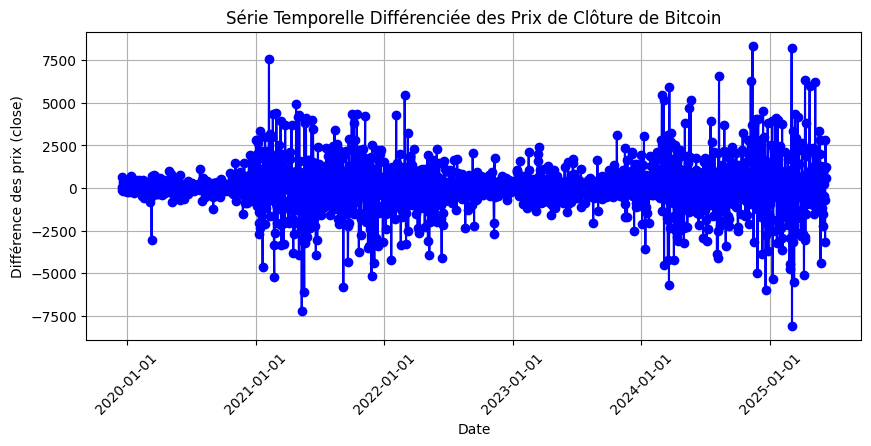

In [ ]:
# Calcul de la différence première des prix de clôture de Bitcoin
diff_res = bitcoin_data['close'].diff().dropna()

# Utiliser l'index des dates correctement pour diff_res
diff_res.index = bitcoin_data['time'].iloc[1:]  # On prend les dates à partir du 2ème point

# Affichage des résultats
plt.figure(figsize=(10, 4))
plt.plot(diff_res, marker='o', linestyle='-', color='b')
plt.title('Série Temporelle Différenciée des Prix de Clôture de Bitcoin')
plt.xlabel('Date')
plt.ylabel('Différence des prix (close)')
plt.grid(True)

# Formater l'axe des X pour afficher les dates au format année-mois-jour
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))

# Rotation des dates pour une meilleure lisibilité
plt.xticks(rotation=45)

plt.show()


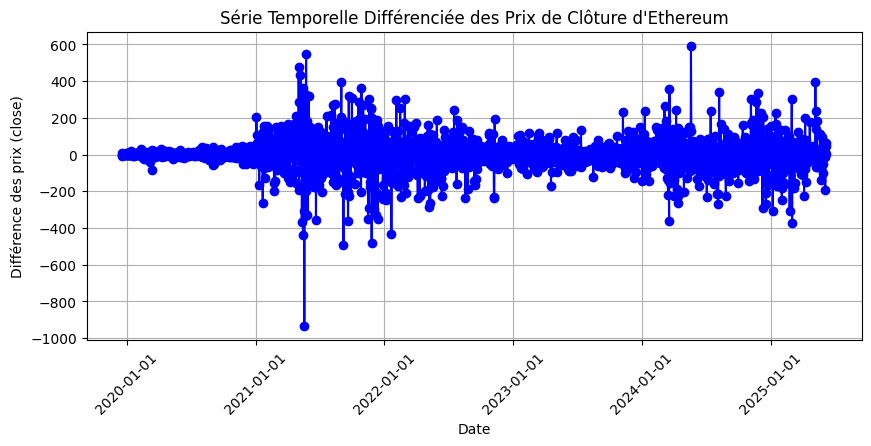

In [ ]:
# Calcul de la différence première des prix de clôture d'Ethereum
diff_res = ethereum_data['close'].diff().dropna()

# Utiliser l'index des dates correctement pour diff_res
diff_res.index = ethereum_data['time'].iloc[1:]  # On prend les dates à partir du 2ème point

# Affichage des résultats
plt.figure(figsize=(10, 4))
plt.plot(diff_res, marker='o', linestyle='-', color='b')
plt.title('Série Temporelle Différenciée des Prix de Clôture d\'Ethereum')
plt.xlabel('Date')
plt.ylabel('Différence des prix (close)')
plt.grid(True)

# Formater l'axe des X pour afficher les dates au format année-mois-jour
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))

# Rotation des dates pour une meilleure lisibilité
plt.xticks(rotation=45)

plt.show()



Autocorrélation (ACF) des prix de clôture de Bitcoin:
[1.         0.99644993 0.99313619 0.9898387  0.98667717 0.98329496
 0.97988351 0.97651282 0.97316699 0.96999207 0.96664479 0.96312372
 0.9594583  0.95583775 0.95194009 0.94809246 0.9443962  0.94078441
 0.93685426 0.9330899  0.92956325 0.92611016 0.92260563 0.91927292
 0.9159584  0.91243014 0.90886039 0.90519245 0.90147948 0.89763421
 0.89382819 0.89002023 0.88601648 0.88239553 0.87868085 0.87509262
 0.87148221 0.8678467  0.86415734 0.86059346 0.85719379 0.85357543
 0.85001283 0.84670182 0.84326953 0.83972701 0.8363407  0.83306048
 0.82983526 0.8267762  0.8239001  0.82101224 0.81828327 0.81555526
 0.81289516 0.81019736 0.80738307 0.80452921 0.80150745 0.79846719
 0.79560076 0.79270034 0.78998475 0.78725126 0.78463786 0.78176005
 0.77877532 0.77588618 0.77286969 0.76959834 0.76650928 0.76333488
 0.76015365 0.75698259 0.7539122  0.75093324 0.7478863  0.74498664
 0.74213991 0.73933257 0.73657421 0.73363497 0.73046038 0.72757443
 0.7247

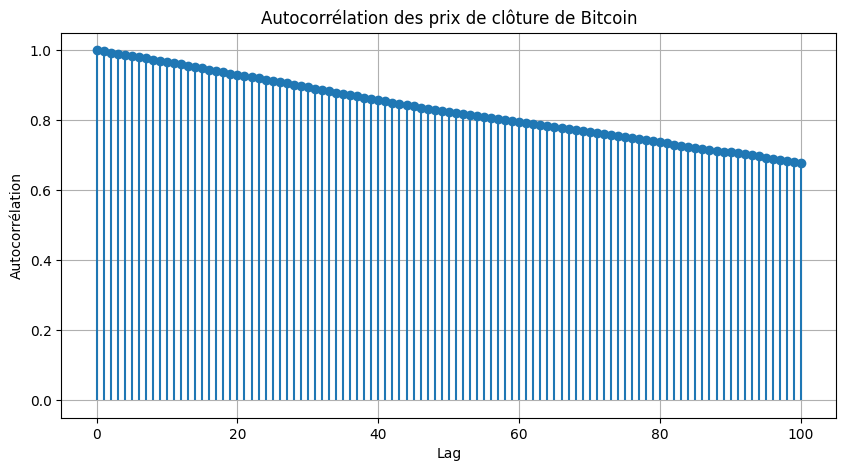

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Calculer l'autocorrélation de la série de prix de clôture de Bitcoin
pp_result = sm.tsa.acf(bitcoin_data['close'], nlags=100)  # Calculer l'autocorrélation pour 40 lags

# Affichage des résultats
print("\nAutocorrélation (ACF) des prix de clôture de Bitcoin:")
print(pp_result)

# Affichage graphique de l'autocorrélation
plt.figure(figsize=(10, 5))
plt.stem(range(len(pp_result)), pp_result, basefmt=" ")  # On retire l'argument use_line_collection
plt.xlabel('Lag')
plt.ylabel('Autocorrélation')
plt.title('Autocorrélation des prix de clôture de Bitcoin')
plt.grid(True)
plt.show()



Autocorrélation (ACF) des prix de clôture de Ethereum:
[1.         0.99575091 0.99201887 0.98813084 0.98405146 0.97981727
 0.97593362 0.97157972 0.96738489 0.96345072 0.95941071 0.95521614
 0.95094577 0.94700677 0.94277966 0.93872928 0.93481293 0.93125306
 0.92730515 0.92360361 0.92000231 0.91645292 0.91275878 0.90911432
 0.90540878 0.90161952 0.89763932 0.89363986 0.8893779  0.88475244
 0.88023769 0.87543763 0.87039455 0.86577867 0.86085236 0.85597895
 0.8509515  0.84603035 0.84121736 0.83679148 0.83263732 0.82831344
 0.82417277 0.82001991 0.81585031 0.81184367 0.80816038 0.80462568
 0.80115418 0.79761156 0.79426508 0.79090802 0.78786345 0.78485351
 0.78169916 0.77847043 0.77510539 0.77142859 0.76779396 0.76394427
 0.76005705 0.75633739 0.75264379 0.74881264 0.74530479 0.74182377
 0.73852948 0.7353135  0.73201577 0.72840085 0.72494789 0.72149729
 0.71839862 0.71551156 0.71297739 0.71056884 0.7080653  0.70574269
 0.70350389 0.70147901 0.69944931 0.69709248 0.69451973 0.69212904
 0.689

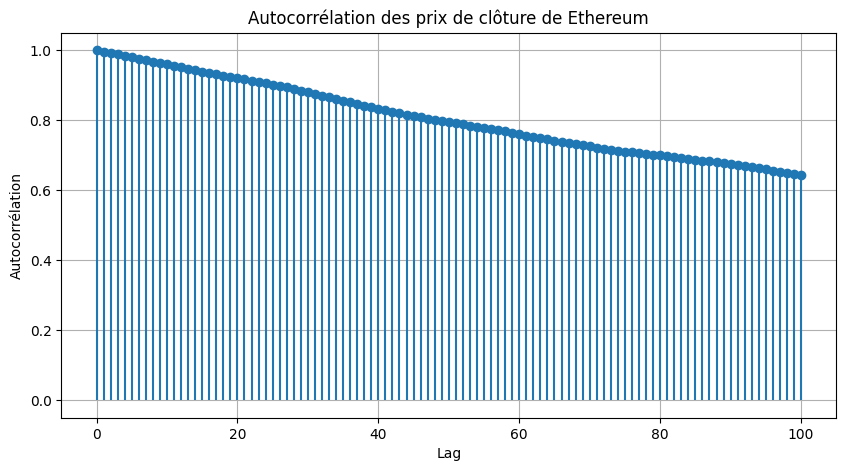

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Calculer l'autocorrélation de la série de prix de clôture de Bitcoin
pp_result = sm.tsa.acf(ethereum_data['close'], nlags=100)  # Calculer l'autocorrélation pour 40 lags

# Affichage des résultats
print("\nAutocorrélation (ACF) des prix de clôture de Ethereum:")
print(pp_result)

# Affichage graphique de l'autocorrélation
plt.figure(figsize=(10, 5))
plt.stem(range(len(pp_result)), pp_result, basefmt=" ")  # On retire l'argument use_line_collection
plt.xlabel('Lag')
plt.ylabel('Autocorrélation')
plt.title('Autocorrélation des prix de clôture de Ethereum')
plt.grid(True)
plt.show()



PACF des prix de clôture de Bitcoin:
[ 1.00000000e+00  9.96948158e-01  3.67871972e-02  2.26014248e-03
  2.07399492e-02 -3.64527311e-02 -9.35110720e-03  4.49238115e-03
  1.05372147e-03  2.76269145e-02 -2.74435821e-02 -3.28964700e-02
 -2.76311517e-02 -4.17396770e-05 -4.75590481e-02  4.32836045e-03
  2.53319883e-02  1.22080143e-02 -5.26316798e-02  2.14548133e-02
  3.75754129e-02  1.21922191e-02 -5.85091081e-03  3.07363430e-02
  4.07460740e-03 -3.84216787e-02 -1.57363331e-02 -1.64267256e-02
 -1.04360869e-02 -2.60441891e-02 -2.69221052e-03  2.98850806e-03
 -4.00880840e-02  5.16218998e-02 -1.43408976e-02  2.46657018e-02
 -2.96115884e-04 -1.29732389e-02 -3.14218291e-03  2.34897653e-02
  2.34003601e-02 -3.23868622e-02  1.14853277e-02  4.02857129e-02
 -3.14676492e-02 -1.97770617e-02  2.03421338e-02  1.20196506e-02
  5.32084043e-03  3.09188079e-02  2.64030488e-02  1.26312781e-03
  2.22850462e-02 -1.91719697e-04  1.42349789e-02  1.00641556e-03
 -3.03743296e-02 -1.26062629e-02 -2.35520118e-02 -1.

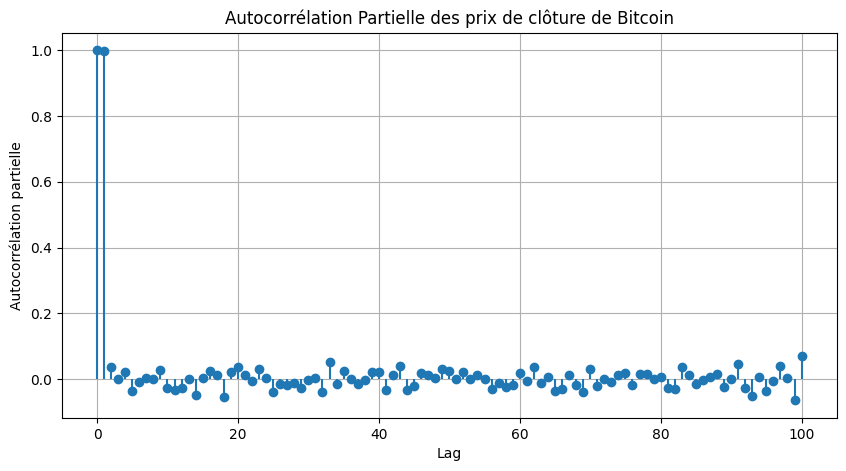

In [ ]:
from statsmodels.tsa.stattools import pacf
import matplotlib.pyplot as plt

# Calcul de la fonction d'autocorrélation partielle (PACF) pour 40 lags
pacf_result = pacf(bitcoin_data['close'], nlags=100)

# Affichage des résultats
print("\nPACF des prix de clôture de Bitcoin:")
print(pacf_result)

# Affichage graphique de la PACF
plt.figure(figsize=(10, 5))
plt.stem(range(len(pacf_result)), pacf_result, basefmt=" ")
plt.xlabel('Lag')
plt.ylabel('Autocorrélation partielle')
plt.title('Autocorrélation Partielle des prix de clôture de Bitcoin')
plt.grid(True)
plt.show()



PACF des prix de clôture de Euthereum:
[ 1.00000000e+00  9.96248784e-01  6.67367379e-02 -1.83120298e-02
 -3.04711011e-02 -2.64931947e-02  4.28134965e-02 -5.77917181e-02
  1.04805653e-02  3.54912279e-02 -1.10958670e-02 -2.29154315e-02
 -2.28651911e-02  4.57933303e-02 -3.22860671e-02  1.18124424e-02
  1.90349577e-02  5.05039456e-02 -4.56695467e-02  1.09349966e-02
  2.05542984e-02  9.16473336e-03 -2.22966841e-02 -8.66100010e-03
  8.59744787e-04 -1.19990212e-02 -3.93893481e-02 -6.88877355e-03
 -3.17298013e-02 -5.30856576e-02 -1.81832939e-03 -3.07453695e-02
 -3.40239150e-02  5.11627729e-02 -4.30981905e-02  1.32873501e-02
 -3.11867236e-02  6.94977675e-03  2.23643012e-02  4.71890924e-02
  4.42692448e-02 -2.80975671e-02  1.80197333e-02 -9.60778640e-03
 -1.24364890e-02  2.21905134e-02  3.74164856e-02  3.16325265e-02
 -1.10574169e-03 -1.13572751e-02  1.39631117e-02  6.52764551e-03
  3.91968299e-02  1.44083399e-02 -1.30809651e-02 -9.77733655e-03
 -2.58652200e-02 -4.29757147e-02  5.37457042e-03 -

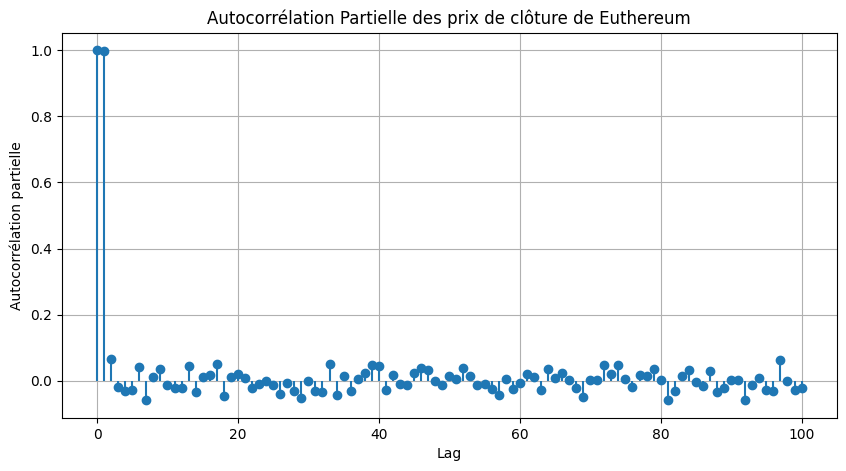

In [ ]:
from statsmodels.tsa.stattools import pacf
import matplotlib.pyplot as plt

# Calcul de la fonction d'autocorrélation partielle (PACF) pour 40 lags
pacf_result = pacf(ethereum_data['close'], nlags=100)

# Affichage des résultats
print("\nPACF des prix de clôture de Euthereum:")
print(pacf_result)

# Affichage graphique de la PACF
plt.figure(figsize=(10, 5))
plt.stem(range(len(pacf_result)), pacf_result, basefmt=" ")
plt.xlabel('Lag')
plt.ylabel('Autocorrélation partielle')
plt.title('Autocorrélation Partielle des prix de clôture de Euthereum')
plt.grid(True)
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Définition du modèle ARIMA avec les paramètres (0,1,0)
model = ARIMA(bitcoin_data['close'], order=(0, 1, 0))

# Ajuster le modèle sur les données
model_fit = model.fit()

# Afficher le résumé du modèle ajusté
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2001
Model:                 ARIMA(0, 1, 0)   Log Likelihood              -17364.607
Date:                Sun, 08 Jun 2025   AIC                          34731.214
Time:                        17:14:14   BIC                          34736.815
Sample:                             0   HQIC                         34733.271
                               - 2001                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2.035e+06   3.37e+04     60.366      0.000    1.97e+06     2.1e+06
Ljung-Box (L1) (Q):                   8.16   Jarque-Bera (JB):              2323.99
Prob(Q):                              0.00   Pr

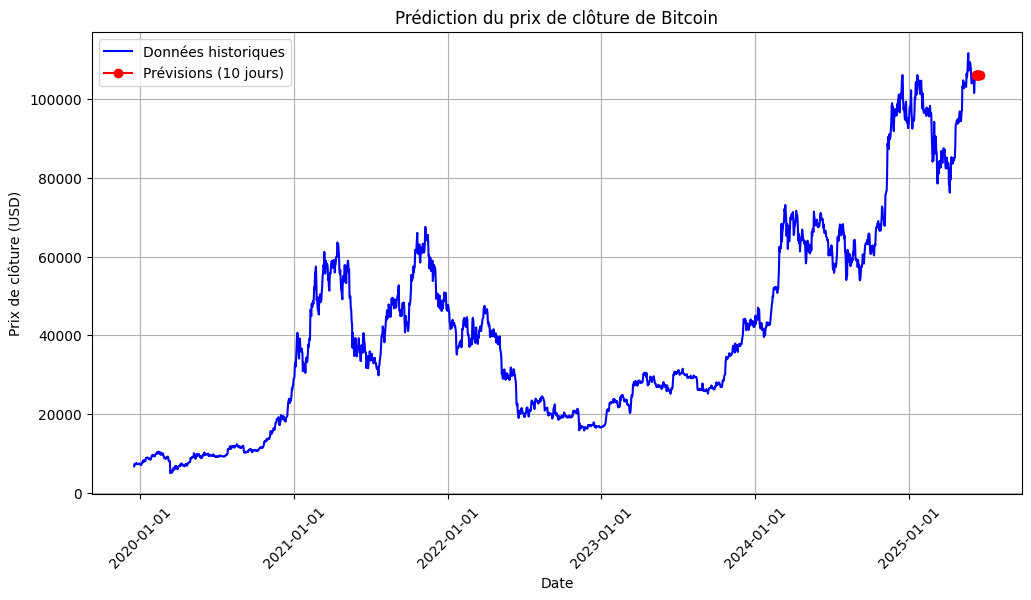

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Faire une prédiction pour les 10 prochaines étapes (en utilisant model_fit)
forecast = model_fit.forecast(steps=10)

# Générer une plage de dates pour les prévisions (en supposant que tes données sont journalières)
forecast_index = pd.date_range(start=bitcoin_data['time'].iloc[-1], periods=11, freq='D')[1:]

# Tracer la série historique des prix de clôture de Bitcoin
plt.figure(figsize=(12, 6))
plt.plot(bitcoin_data['time'], bitcoin_data['close'], label='Données historiques', color='blue')

# Tracer les prévisions en les ajoutant à la fin des données historiques
plt.plot(forecast_index, forecast, label='Prévisions (10 jours)', color='red', marker='o')

# Ajouter des labels et une légende
plt.title('Prédiction du prix de clôture de Bitcoin')  # Modifier le titre pour Bitcoin
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()

# Formater l'axe des X pour afficher les dates au format année-mois-jour
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))

# Ajouter une grille et afficher le graphique
plt.grid(True)
plt.xticks(rotation=45)  # Rotation des dates pour une meilleure lisibilité
plt.show()


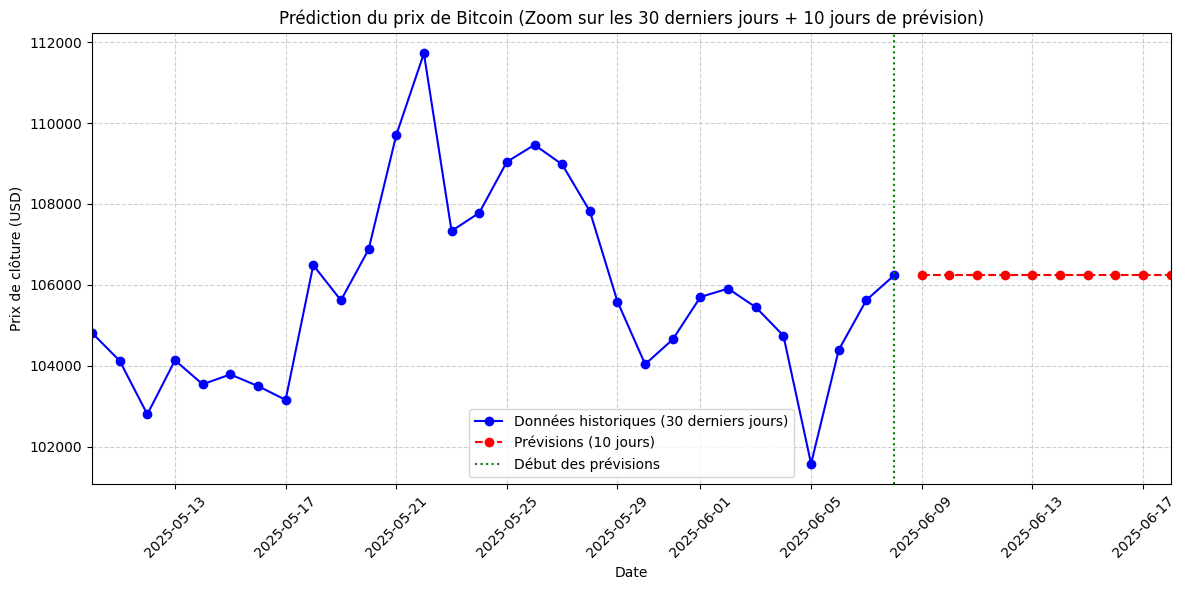

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Faire une prédiction pour les 10 prochaines étapes (en utilisant model_fit)
forecast = model_fit.forecast(steps=10)

# Générer une plage de dates pour les prévisions (fréquence journalière)
forecast_index = pd.date_range(
    start=bitcoin_data['time'].iloc[-1],  # Dernière date historique
    periods=11,  # 10 jours de prévision + 1 jour de départ
    freq='D'  # Fréquence journalière
)[1:]  # On exclut le premier jour (dupliqué)

# --- ZOOM : Sélectionner les 30 derniers jours historiques + prévisions ---
last_n_days = 30  # Nombre de jours historiques à afficher avant la prévision

# Sélection des dernières données
historical_dates = bitcoin_data['time'].iloc[-last_n_days:]
historical_prices = bitcoin_data['close'].iloc[-last_n_days:]

# Création du graphique
plt.figure(figsize=(12, 6))

# Tracer les données historiques (30 derniers jours)
plt.plot(
    historical_dates,
    historical_prices,
    label='Données historiques (30 derniers jours)',
    color='blue',
    marker='o'
)

# Tracer les prévisions (10 jours)
plt.plot(
    forecast_index,
    forecast,
    label='Prévisions (10 jours)',
    color='red',
    linestyle='--',
    marker='o'
)

# Ajout d'une ligne verticale pour séparer historique et prévision
last_historical_date = bitcoin_data['time'].iloc[-1]
plt.axvline(
    x=last_historical_date,
    color='green',
    linestyle=':',
    label='Début des prévisions'
)

# Labels, titre et légende
plt.title('Prédiction du prix de Bitcoin (Zoom sur les 30 derniers jours + 10 jours de prévision)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()

# Format des dates sur l'axe X
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Ajustement automatique des limites de l'axe X pour le zoom
plt.xlim(
    left=historical_dates.iloc[0],  # Première date des données affichées
    right=forecast_index[-1]  # Dernière date de prévision
)

# Grille et affichage
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()  # Éviter les coupures de labels
plt.show()

In [ ]:
import numpy as np

# Calcul des résidus (erreurs) du modèle ajusté
residuals = model_fit.resid

# Erreur Absolue Moyenne (MAE)
mae = np.mean(np.abs(residuals))
print("Mean Absolute Error (MAE): ", mae)

# Erreur Quadratique Moyenne Racine (RMSE)
rmse = np.sqrt(np.mean(residuals**2))
print("Root Mean Squared Error (RMSE): ", rmse)

# Erreur Absolue en Pourcentage Moyenne (MAPE)
# On utilise les données réelles pour calculer le MAPE (il faut que tu aies les valeurs réelles de tes prévisions).
# Supposons que 'bitcoin_data['close']' contient les valeurs réelles de la série.
# Attention : Le calcul du MAPE ne doit pas inclure des zéros pour éviter la division par zéro.

mape = np.mean(np.abs(residuals) / bitcoin_data['close'][1:]) * 100  # Assure-toi d'utiliser les bonnes valeurs réelles
print("Mean Absolute Percentage Error (MAPE): ", mape)


Mean Absolute Error (MAE):  892.2659820089955
Root Mean Squared Error (RMSE):  1434.3854064819488
Mean Absolute Percentage Error (MAPE):  2.2487520514159427


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Définition du modèle ARIMA avec les paramètres (0,1,0)
model = ARIMA(ethereum_data['close'], order=(0, 1, 0))

# Ajuster le modèle sur les données
model_fit = model.fit()

# Afficher le résumé du modèle ajusté
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2001
Model:                 ARIMA(0, 1, 0)   Log Likelihood              -11930.888
Date:                Sun, 08 Jun 2025   AIC                          23863.776
Time:                        17:14:15   BIC                          23869.377
Sample:                             0   HQIC                         23865.833
                               - 2001                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      8888.4785    116.593     76.235      0.000    8659.961    9116.996
Ljung-Box (L1) (Q):                  10.63   Jarque-Bera (JB):              7798.77
Prob(Q):                              0.00   Pr

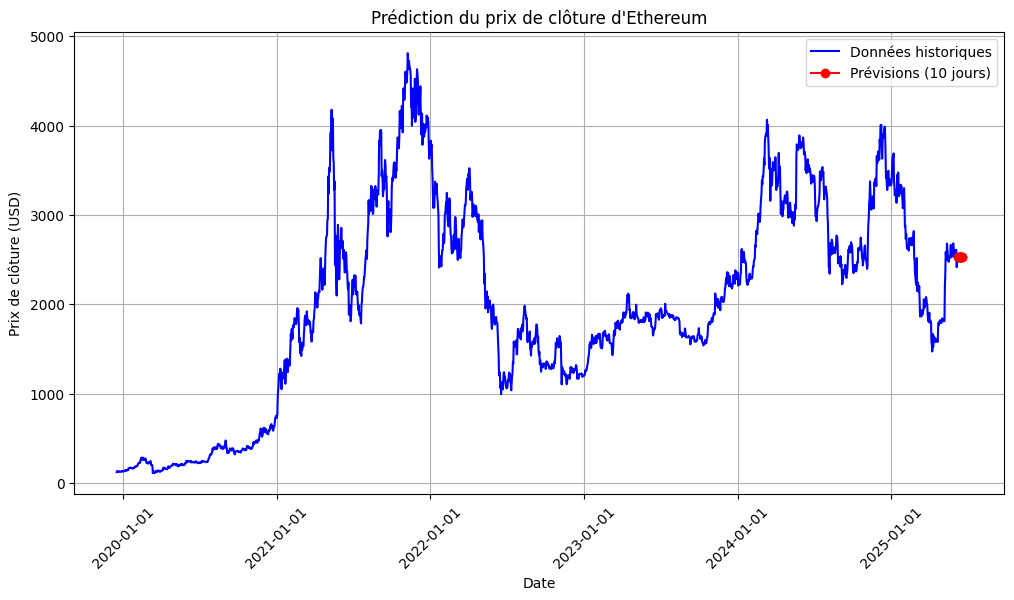

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Faire une prédiction pour les 10 prochaines étapes (en utilisant model_fit)
forecast = model_fit.forecast(steps=10)

# Générer une plage de dates pour les prévisions (en supposant que tes données sont journalières)
forecast_index = pd.date_range(start=ethereum_data['time'].iloc[-1], periods=11, freq='D')[1:]

# Tracer la série historique des prix de clôture d'Ethereum
plt.figure(figsize=(12, 6))
plt.plot(ethereum_data['time'], ethereum_data['close'], label='Données historiques', color='blue')

# Tracer les prévisions en les ajoutant à la fin des données historiques
plt.plot(forecast_index, forecast, label='Prévisions (10 jours)', color='red', marker='o')

# Ajouter des labels et une légende
plt.title('Prédiction du prix de clôture d\'Ethereum')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()

# Formater l'axe des X pour afficher les années (ou mois si tu préfères)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))

# Ajouter une grille et afficher le graphique
plt.grid(True)
plt.xticks(rotation=45)  # Rotation des dates pour une meilleure lisibilité
plt.show()


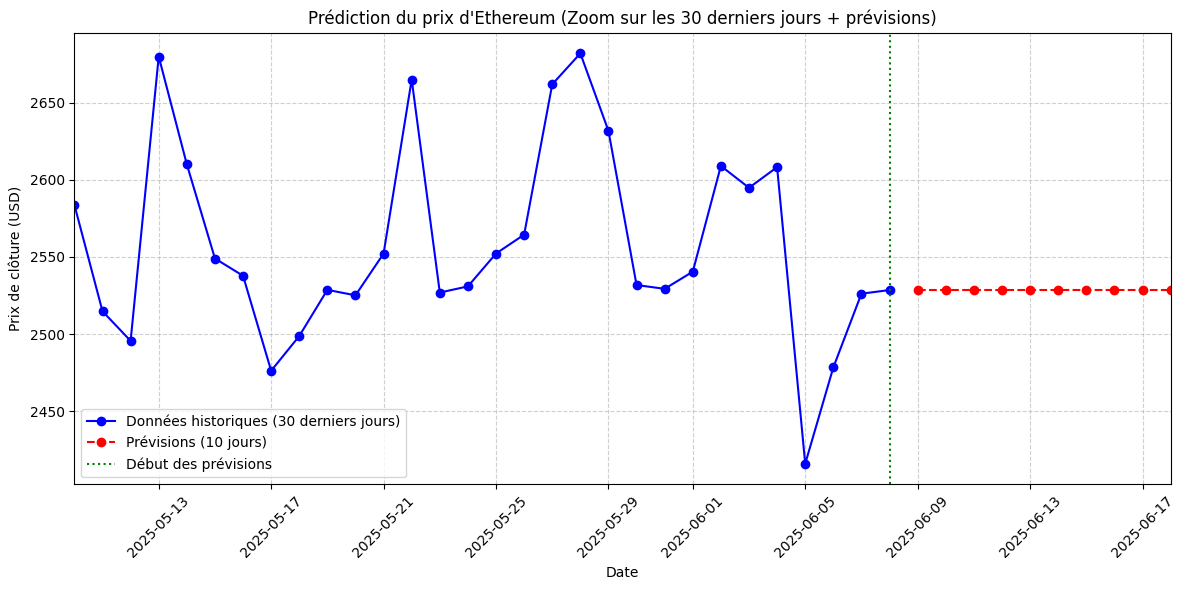

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# 1. Faire une prédiction pour les 10 prochaines étapes
forecast = model_fit.forecast(steps=10)

# 2. Générer les dates des prévisions (fréquence journalière)
forecast_index = pd.date_range(
    start=ethereum_data['time'].iloc[-1],  # Dernière date historique
    periods=11,  # 10 jours de prévision + 1 jour de départ
    freq='D'  # Fréquence journalière
)[1:]  # On exclut le premier jour (dupliqué)

# 3. Paramètres du zoom
last_n_days = 30  # Nombre de jours historiques à afficher avant la prévision

# 4. Sélection des dernières données historiques
historical_dates = ethereum_data['time'].iloc[-last_n_days:]
historical_prices = ethereum_data['close'].iloc[-last_n_days:]

# 5. Création du graphique
plt.figure(figsize=(12, 6))

# Tracer les données historiques (30 derniers jours)
plt.plot(
    historical_dates,
    historical_prices,
    label=f'Données historiques ({last_n_days} derniers jours)',
    color='blue',
    marker='o'
)

# Tracer les prévisions (10 jours)
plt.plot(
    forecast_index,
    forecast,
    label='Prévisions (10 jours)',
    color='red',
    linestyle='--',
    marker='o'
)

# Ligne verticale pour séparer historique et prévision
plt.axvline(
    x=ethereum_data['time'].iloc[-1],
    color='green',
    linestyle=':',
    label='Début des prévisions'
)

# 6. Mise en forme
plt.title('Prédiction du prix d\'Ethereum (Zoom sur les 30 derniers jours + prévisions)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()

# Format des dates et rotation
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Ajustement des limites pour le zoom
plt.xlim(
    left=historical_dates.iloc[0],  # Première date affichée
    right=forecast_index[-1]  # Dernière date de prévision
)

# Grille et affichage
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Calcul des résidus (erreurs) du modèle ajusté
residuals = model_fit.resid

# Erreur Absolue Moyenne (MAE)
mae = np.mean(np.abs(residuals))
print("Mean Absolute Error (MAE): ", mae)

# Erreur Quadratique Moyenne Racine (RMSE)
rmse = np.sqrt(np.mean(residuals**2))
print("Root Mean Squared Error (RMSE): ", rmse)

# Erreur Absolue en Pourcentage Moyenne (MAPE)
# On utilise les données réelles pour calculer le MAPE (il faut que tu aies les valeurs réelles de tes prévisions).
# Supposons que 'bitcoin_data['close']' contient les valeurs réelles de la série.
# Attention : Le calcul du MAPE ne doit pas inclure des zéros pour éviter la division par zéro.

mape = np.mean(np.abs(residuals) / bitcoin_data['close'][1:]) * 100  # Assure-toi d'utiliser les bonnes valeurs réelles
print("Mean Absolute Percentage Error (MAPE): ", mape)


Mean Absolute Error (MAE):  58.354852573713146
Root Mean Squared Error (RMSE):  94.31831665679533
Mean Absolute Percentage Error (MAPE):  0.1494679758201201


Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0269 - mae: 0.1122 - val_loss: 0.0024 - val_mae: 0.0379
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0015 - mae: 0.0274 - val_loss: 0.0034 - val_mae: 0.0467
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0012 - mae: 0.0236 - val_loss: 0.0020 - val_mae: 0.0344
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0011 - mae: 0.0235 - val_loss: 0.0017 - val_mae: 0.0316
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011 - mae: 0.0231 - val_loss: 0.0014 - val_mae: 0.0292
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 9.2250e-04 - mae: 0.0214 - val_loss: 0.0028 - val_mae: 0.0439
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 7.5404e-04 - mae: 0.0190 - val_loss: 0.0037 - val_mae: 0.0521
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.9420e-04 - mae: 0.0204 - val_loss: 0.0048 - val_mae: 0.0604
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14

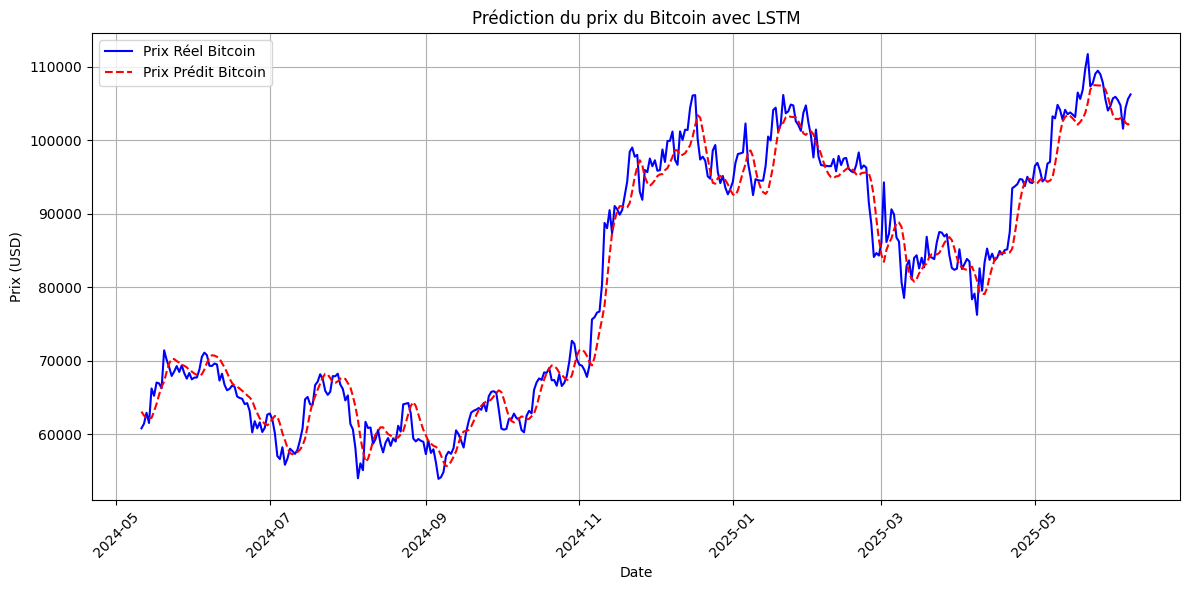

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import time
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score


# Fonction pour récupérer les données historiques de CryptoCompare
def collect_data_crypto_compare(crypto_symbol, start_timestamp, end_timestamp):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday'
    params = {
        'fsym': crypto_symbol,  # Symbole de la cryptomonnaie (BTC ou ETH)
        'tsym': 'USD',  # Devise de comparaison
        'limit': 2000,  # Limite des jours à récupérer
        'toTs': end_timestamp,  # Timestamp de fin
        'extraParams': 'crypto_prediction'  # Paramètre optionnel pour l'identification de l'application
    }
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()['Data']['Data']
        df = pd.DataFrame(data)

        # Convertir les timestamps en dates lisibles
        df['time'] = pd.to_datetime(df['time'], unit='s')

        return df
    else:
        print(f"Erreur lors de la récupération des données: {response.status_code}")
        return None


# Fonction pour prétraiter les données
def preprocess_data(df):
    # Calculer les rendements quotidiens
    df['return'] = df['close'].pct_change()

    # Supprimer les NaN
    df = df.dropna()

    # Normalisation des données avec MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    df_scaled = scaler.fit_transform(df[['close', 'return']])

    return df, df_scaled, scaler


# Fonction pour créer des séquences pour l'entraînement du LSTM
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length, 0])  # Utiliser uniquement la colonne 'close' pour X
        y.append(data[i + seq_length, 0])  # La cible est la colonne 'close' après seq_length
    return np.array(X), np.array(y)


# Fonction pour construire le modèle LSTM
def build_model(seq_length, input_shape):
    model = Sequential()

    # Première couche LSTM
    model.add(LSTM(units=64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))

    # Deuxième couche LSTM
    model.add(LSTM(units=64, return_sequences=False))
    model.add(Dropout(0.2))

    # Couche Dense
    model.add(Dense(units=32, activation='relu'))

    # Couche de sortie
    model.add(Dense(units=1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return model


# Fonction principale pour entraîner le modèle
def main():
    # Dates
    today = datetime.today()
    end_timestamp = int(time.mktime(today.timetuple()))
    start_timestamp = 1614556800  # Exemple pour le début de l'année 2021

    # Collecter les données de Bitcoin
    bitcoin_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)

    # Vérification des données
    if bitcoin_data is None:
        return

    # Prétraitement des données
    df, df_scaled, scaler = preprocess_data(bitcoin_data)

    # Création des séquences pour l'entraînement
    seq_length = 30
    X, y = create_sequences(df_scaled, seq_length)

    # Reshape pour LSTM (samples, time steps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Division train/test
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Construire le modèle LSTM
    model = build_model(seq_length, input_shape=(X_train.shape[1], 1))

    # EarlyStopping pour éviter le surapprentissage
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Entraîner le modèle
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping],
        verbose=1
    )

    # Prédictions
    y_pred = model.predict(X_test)

    # Inverser la normalisation pour obtenir les prix réels
    y_test_rescaled = scaler.inverse_transform(np.column_stack((y_test, np.zeros_like(y_test))))[:, 0]
    y_pred_rescaled = scaler.inverse_transform(np.column_stack((y_pred, np.zeros_like(y_pred))))[:, 0]

    # Évaluation
    mse = np.mean((y_test_rescaled - y_pred_rescaled) ** 2)
    rmse = np.sqrt(mse)
    r2=r2_score(y_test_rescaled, y_pred_rescaled)
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des résultats
    plt.figure(figsize=(12, 6))
    plt.plot(bitcoin_data['time'].iloc[-len(y_test_rescaled):], y_test_rescaled, label='Prix Réel Bitcoin', color='blue')
    plt.plot(bitcoin_data['time'].iloc[-len(y_pred_rescaled):], y_pred_rescaled, label='Prix Prédit Bitcoin', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix (USD)')
    plt.title('Prédiction du prix du Bitcoin avec LSTM')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Appel à la fonction principale
main()


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0352 - val_loss: 0.0058
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0043 - val_loss: 0.0068
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0034 - val_loss: 0.0053
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0030 - val_loss: 0.0064
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0032 - val_loss: 0.0019
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028 - val_loss: 0.0038
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0022 - val_loss: 0.0013
Epoch 12/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022 - val

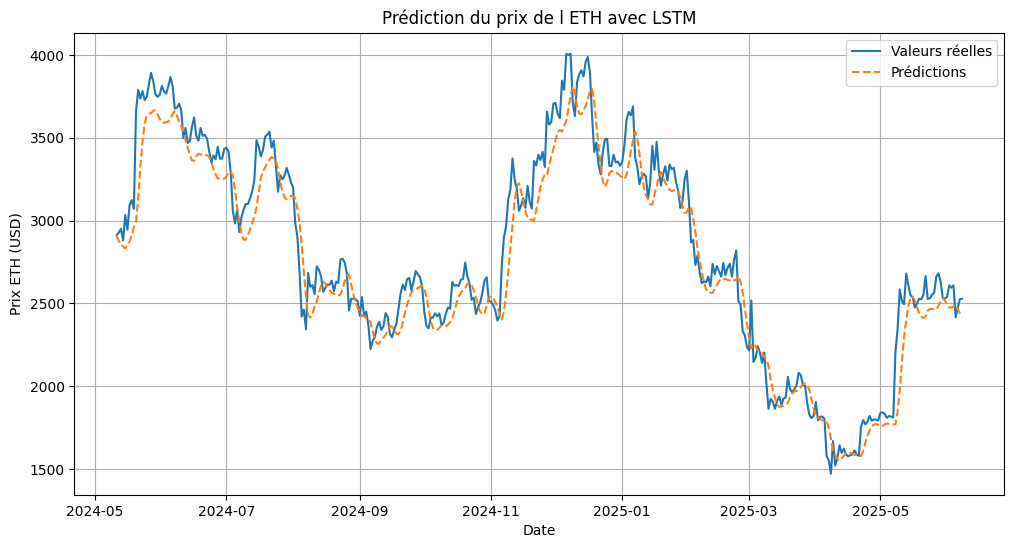

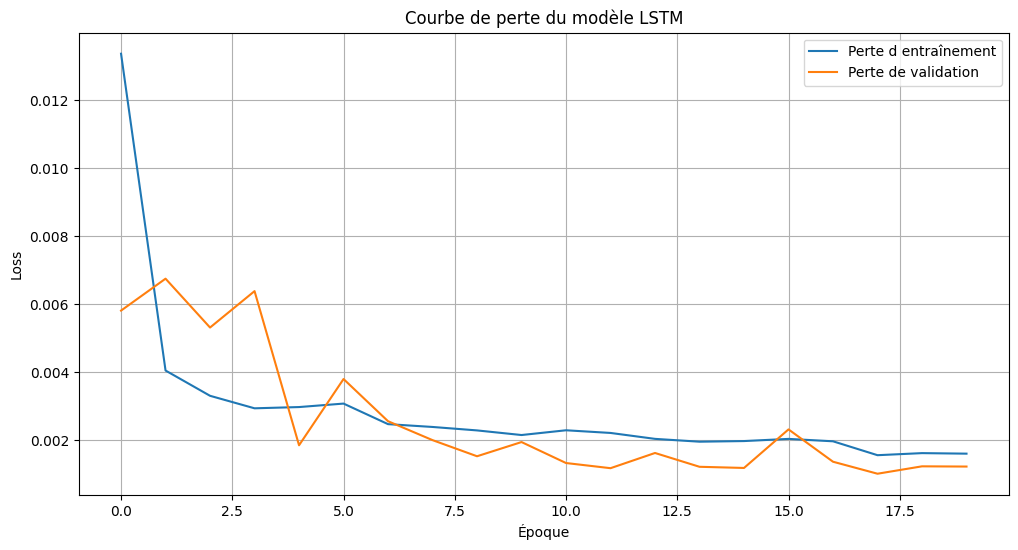

In [ ]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
from datetime import datetime
import time


# Définition des timestamps
today = datetime.today()
end_timestamp = int(time.mktime(today.timetuple()))
start_timestamp = 1614556800  # Début de l'année 2021

# Collecte des données
bitcoin_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
ethereum_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# 2. Prétraitement des données
def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()
    df.dropna(inplace=True)
    return df

data = preprocess_data(bitcoin_data, ethereum_data)

# 3. Préparation des données pour le RNN
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[['close_btc', 'close_eth']])

def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 1])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(data_scaled, seq_length)
train_size = int(len(X) * 0.8)
X_train, X_test, y_train, y_test = X[:train_size], X[train_size:], y[:train_size], y[train_size:]

# 4. Construction du modèle LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 2)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 5. Entraînement du modèle
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

# 6. Prédictions et évaluation
y_pred = model.predict(X_test)
y_pred_rescaled = scaler.inverse_transform(np.column_stack((np.zeros_like(y_pred), y_pred)))[:, 1]
y_test_rescaled = scaler.inverse_transform(np.column_stack((np.zeros_like(y_test), y_test)))[:, 1]

mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f"Mean Squared Error: {mse}")

# 7. Visualisation des prédictions
plt.figure(figsize=(12, 6))
plt.plot(data['time'][-len(y_test):], y_test_rescaled, label='Valeurs réelles')
plt.plot(data['time'][-len(y_test):], y_pred_rescaled, label='Prédictions', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Prix ETH (USD)')
plt.title('Prédiction du prix de l ETH avec LSTM')
plt.legend()
plt.grid(True)
plt.show()

# 8. Visualisation de la perte
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Perte d entraînement')
plt.plot(history.history['val_loss'], label='Perte de validation')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.title('Courbe de perte du modèle LSTM')
plt.legend()
plt.grid(True)
plt.show()


### Utilisation du prix de Eutereum seul pour prédire les prix de Bitcoin  

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0204 - mae: 0.1010 - val_loss: 0.0097 - val_mae: 0.0751
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0066 - mae: 0.0586 - val_loss: 0.0091 - val_mae: 0.0727
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0072 - mae: 0.0596 - val_loss: 0.0149 - val_mae: 0.0926
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0063 - mae: 0.0528 - val_loss: 0.0100 - val_mae: 0.0750
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0060 - mae: 0.0537 - val_loss: 0.0114 - val_mae: 0.0786
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0054 - mae: 0.0484 - val_loss: 0.0077 - val_mae: 0.0676
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0057 - mae: 0.0526 - val_loss: 0.0096 - val_mae: 0.0737
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049 - mae: 0.0486 - val_loss: 0.0085 - val_mae: 0.0694
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0

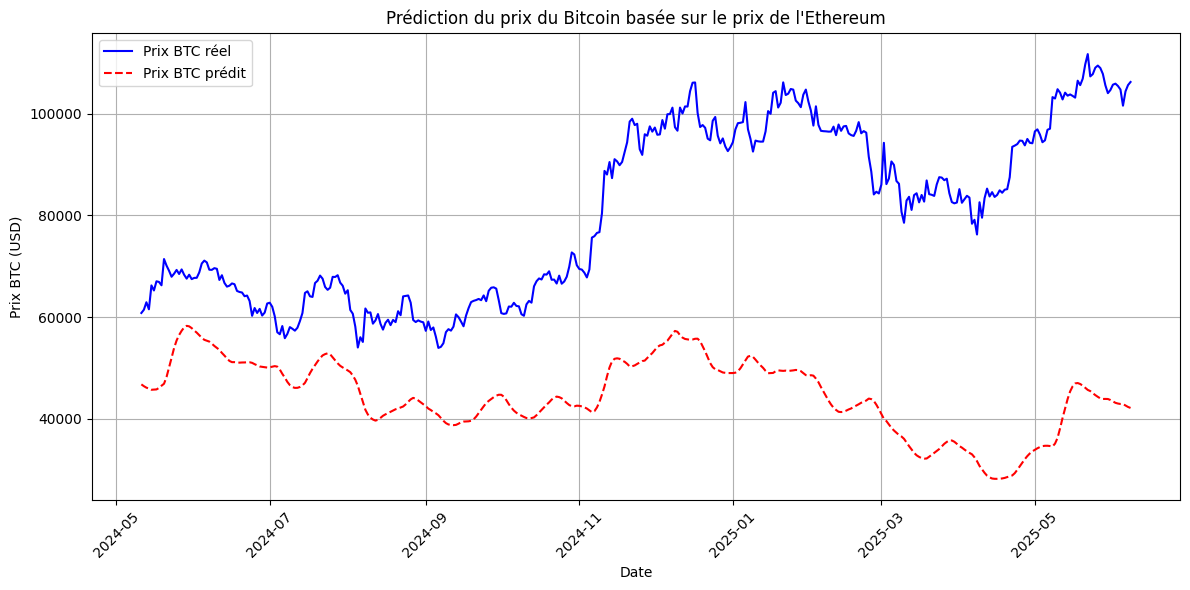

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# Récupérer les données historiques de Bitcoin et Ethereum
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Fonction pour prétraiter les données
def preprocess_data(btc_df, eth_df):
    # Fusionner les données BTC et ETH sur la colonne 'time'
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))

    # Conversion de la colonne time au format datetime si nécessaire
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Trier les données par ordre chronologique
    df = df.sort_values('time')

    # Calculer les retours journaliers pour BTC et ETH
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()

    # Supprimer les lignes avec des valeurs NaN
    df.dropna(inplace=True)

    return df

# Fonction pour créer des séquences pour l'entraînement LSTM
def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        # Utiliser les séquences de prix ETH comme features
        X.append(eth_prices[i:i+seq_length])
        # Utiliser le prix BTC comme cible
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# Fonction pour construire le modèle LSTM
def build_model(seq_length, features=1):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_length, features)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None  # Retourner None si les données sont invalides

    # Prétraitement des données
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Création des scalers pour BTC et ETH séparément pour une meilleure mise à l'échelle
    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Mise à l'échelle des prix
    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)

    # Reshape pour LSTM (samples, time steps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Division train/test (en respectant la chronologie)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Construction et entraînement du modèle
    model = build_model(seq_length)

    # Utilisation d'early stopping pour éviter le surapprentissage
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # Prédictions
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin basée sur le prix de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, eth_scaler, btc_scaler

# Appeler la fonction principale avec les données récupérées
if btc_data is not None and eth_data is not None:
    model, eth_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")



Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - loss: 0.0360 - mae: 0.1518 - val_loss: 0.1801 - val_mae: 0.4050
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0148 - mae: 0.0972 - val_loss: 0.1881 - val_mae: 0.4157
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0139 - mae: 0.0935 - val_loss: 0.1360 - val_mae: 0.3547
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0078 - mae: 0.0692 - val_loss: 0.1656 - val_mae: 0.3884
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0079 - mae: 0.0657 - val_loss: 0.1295 - val_mae: 0.3421
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0069 - mae: 0.0628 - val_loss: 0.1287 - val_mae: 0.3385
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - mae: 0.0519 - val_loss: 0.1101 - val_mae: 0.3102
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0054 - mae: 0.0559 - val_loss: 0.0992 - val_mae: 0.2914
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - l

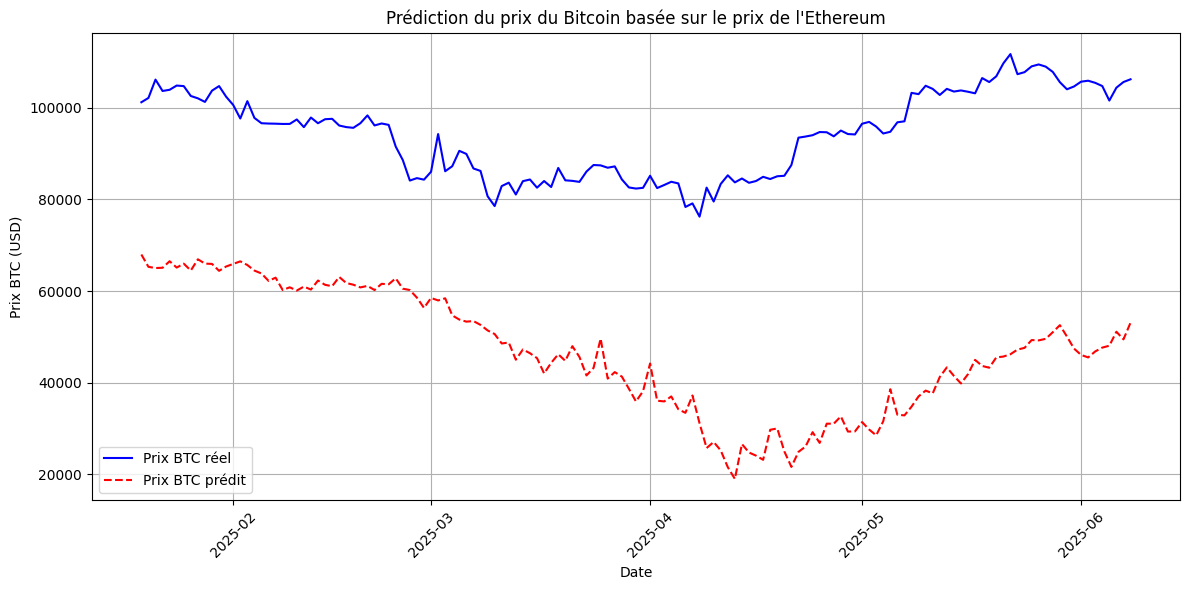

In [ ]:
# Fonction pour construire le modèle RNN Simple
def build_rnn_model(seq_length, features=1):
    model = Sequential([
        # Première couche RNN
        SimpleRNN(64, return_sequences=True, input_shape=(seq_length, features)),
        Dropout(0.2),
        # Deuxième couche RNN
        SimpleRNN(64, return_sequences=False),
        Dropout(0.2),
        # Couches entièrement connectées
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main_rnn(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None  # Retourner None si les données sont invalides

    # Prétraitement des données
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Création des scalers pour BTC et ETH séparément pour une meilleure mise à l'échelle
    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Mise à l'échelle des prix
    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)

    # Reshape pour RNN (samples, time steps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Division train/test (en respectant la chronologie)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Construction et entraînement du modèle RNN
    model = build_rnn_model(seq_length)

    # Utilisation d'early stopping pour éviter le surapprentissage
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # Prédictions
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin basée sur le prix de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, eth_scaler, btc_scaler

# Appeler la fonction principale avec les données récupérées pour RNN
if btc_data is not None and eth_data is not None:
    model_rnn, eth_scaler_rnn, btc_scaler_rnn = main_rnn(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0726 - mae: 0.2081 - val_loss: 0.0493 - val_mae: 0.2058
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0111 - mae: 0.0889 - val_loss: 0.1018 - val_mae: 0.3067
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0053 - mae: 0.0587 - val_loss: 0.0948 - val_mae: 0.2973
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0061 - mae: 0.0581 - val_loss: 0.0836 - val_mae: 0.2787
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0049 - mae: 0.0518 - val_loss: 0.0829 - val_mae: 0.2769
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0046 - mae: 0.0510 - val_loss: 0.0875 - val_mae: 0.2839
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - mae: 0.0550 - val_loss: 0.0942 - val_mae: 0.2946
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0041 - mae: 0.0470 - val_loss: 0.0881 - val_mae: 0.2831
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

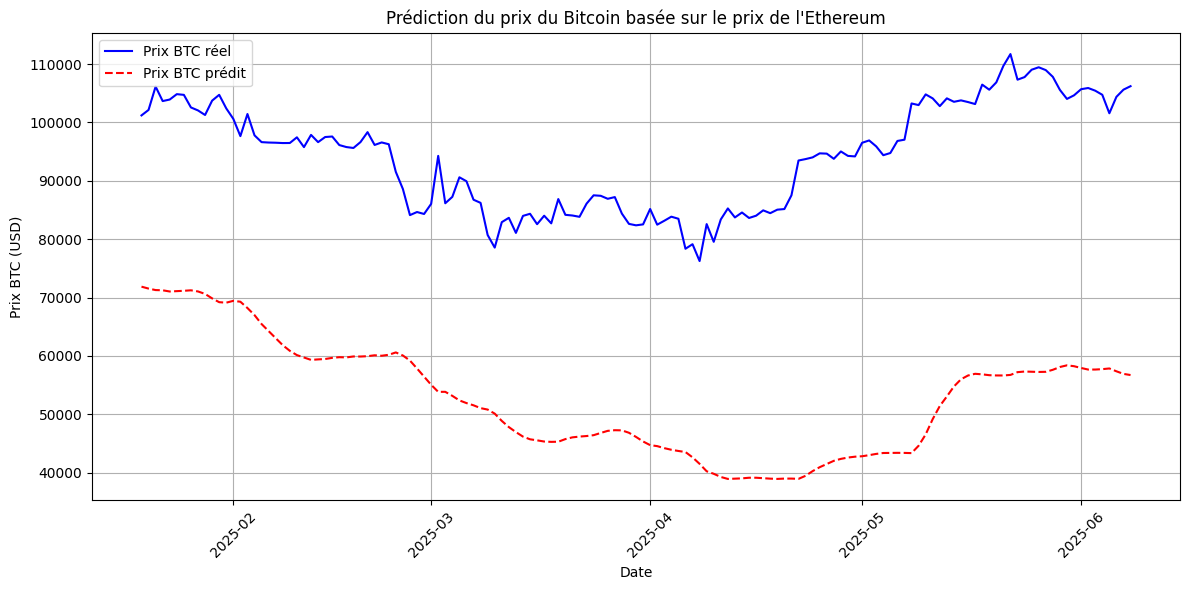

In [ ]:

# Fonction pour construire le modèle GRU
def build_gru_model(seq_length, features=1):
    model = Sequential([
        # Première couche GRU
        GRU(64, return_sequences=True, input_shape=(seq_length, features)),
        Dropout(0.2),
        # Deuxième couche GRU
        GRU(64, return_sequences=False),
        Dropout(0.2),
        # Couches entièrement connectées
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main_gru(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None  # Retourner None si les données sont invalides

    # Prétraitement des données
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Création des scalers pour BTC et ETH séparément pour une meilleure mise à l'échelle
    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Mise à l'échelle des prix
    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)

    # Reshape pour GRU (samples, time steps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Division train/test (en respectant la chronologie)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Construction et entraînement du modèle GRU
    model = build_gru_model(seq_length)

    # Utilisation d'early stopping pour éviter le surapprentissage
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # Prédictions
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin basée sur le prix de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, eth_scaler, btc_scaler

# Appeler la fonction principale avec les données récupérées pour GRU
if btc_data is not None and eth_data is not None:
    model_gru, eth_scaler_gru, btc_scaler_gru = main_gru(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")


🚀 Démarrage du système de prédiction Bitcoin simplifié avec optimisation
📡 Récupération des données...
📊 Prétraitement des données...
🔍 Optimisation des hyperparamètres...
🔍 Début de la recherche des meilleurs hyperparamètres...
Nombre total de combinaisons à tester: 5
Iteration 1/5: Score = 0.0188
Params: {'rnn_type': 'LSTM', 'rnn_layers': 2, 'rnn_units': [64, 32], 'use_bidirectional': False, 'dropout_rate': 0.2, 'dense_layers': [32], 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'patience': 8}
--------------------------------------------------
Iteration 2/5: Score = 0.0352
Params: {'rnn_type': 'LSTM', 'rnn_layers': 3, 'rnn_units': [128, 64, 32], 'use_bidirectional': True, 'dropout_rate': 0.3, 'dense_layers': [64, 32], 'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 50, 'patience': 10}
--------------------------------------------------
Iteration 3/5: Score = 0.0228
Params: {'rnn_type': 'GRU', 'rnn_layers': 2, 'rnn_units': [64, 64], 'use_bidirectional': False, 'dropout_r

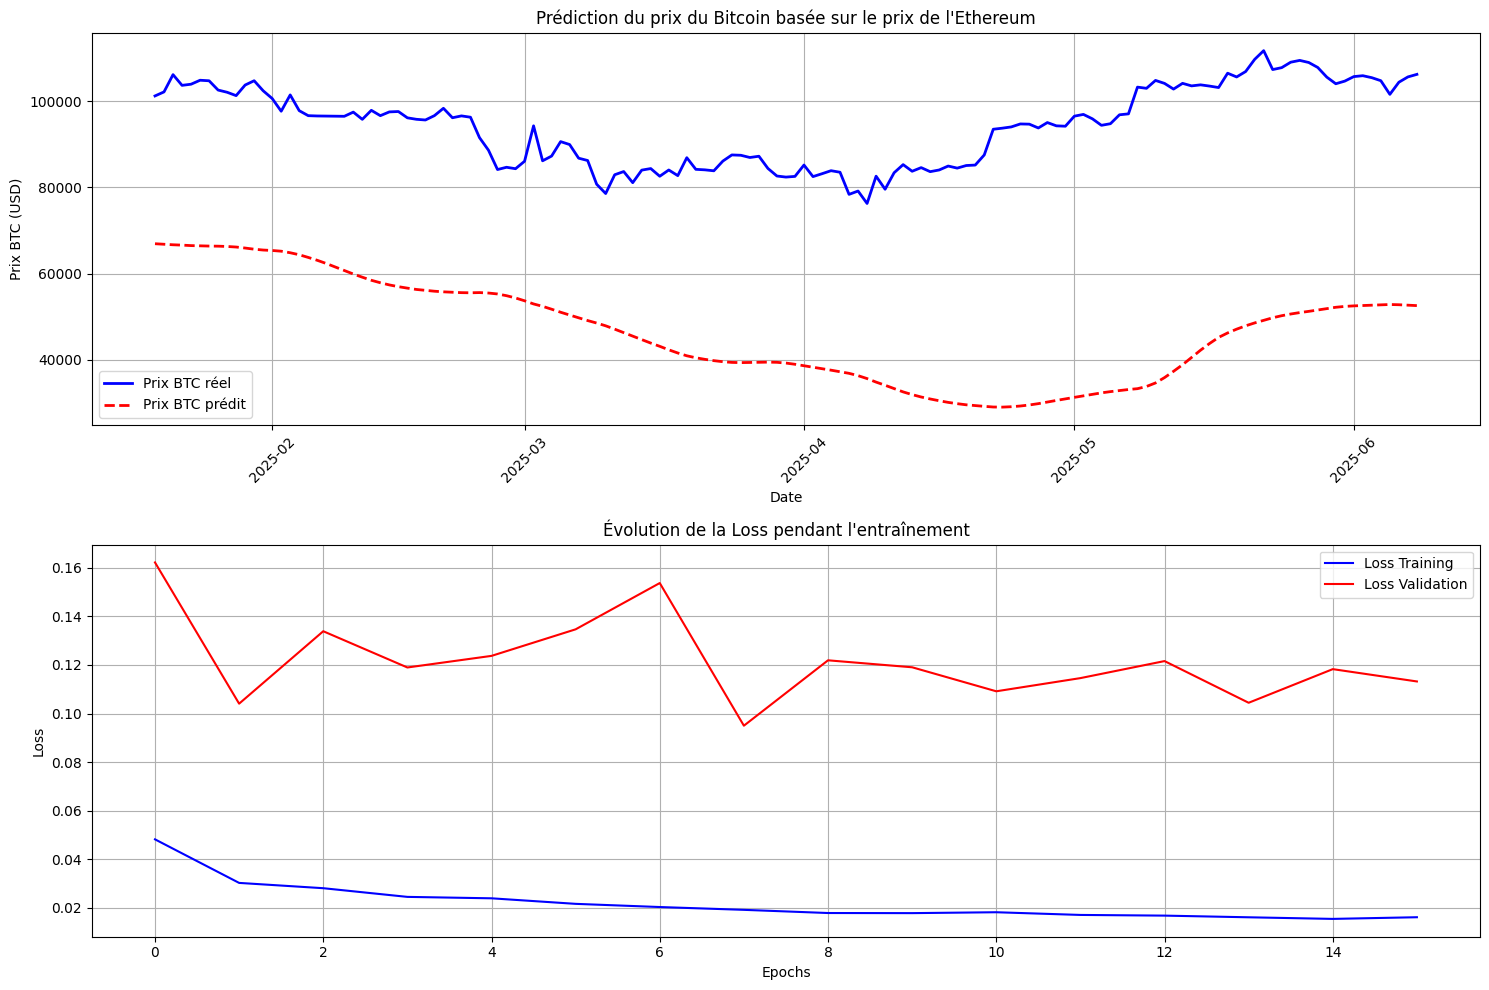

✅ Modèle sauvegardé sous le nom 'model_lstm_bitcoin_simple_optimized.h5'
✅ Scalers sauvegardés

🔮 Pour prédire les prix futurs, utilisez la fonction predict_future_bitcoin()


In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Dropout, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
from sklearn.model_selection import TimeSeriesSplit
import itertools
import json
import warnings
warnings.filterwarnings('ignore')

# =========================
# Récupération des données
# =========================

def collect_data_crypto_compare(symbol, start_timestamp, end_timestamp):
    url = 'https://min-api.cryptocompare.com/data/v2/histoday'
    days = (end_timestamp - start_timestamp) // (24 * 3600) + 1
    limit = min(2000, days)

    params = {
        'fsym': symbol,
        'tsym': 'USD',
        'limit': limit,
        'toTs': end_timestamp
    }

    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        if data['Response'] == 'Success':
            df = pd.DataFrame(data['Data']['Data'])
            df['time'] = pd.to_datetime(df['time'], unit='s')
            return df
        else:
            print(f"Erreur API: {data['Message']}")
            return None
    else:
        print(f"Erreur HTTP: {response.status_code}")
        return None

# =========================================
# Prétraitement des données
# =========================================

def preprocess_data(btc_df, eth_df):
    # Fusionner les données BTC et ETH sur la colonne 'time'
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))

    # Conversion de la colonne time au format datetime si nécessaire
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Trier les données par ordre chronologique
    df = df.sort_values('time')

    # Calculer les retours journaliers pour BTC et ETH
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()

    # Supprimer les lignes avec des valeurs NaN
    df.dropna(inplace=True)

    return df

# =====================
# Création des séquences
# =====================

def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        # Utiliser les séquences de prix ETH comme features
        X.append(eth_prices[i:i+seq_length])
        # Utiliser le prix BTC comme cible
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# ====================================
# OPTIMISEUR D'HYPERPARAMÈTRES
# ====================================

class LSTMHyperparameterOptimizer:
    def __init__(self, X, y, eth_scaler, btc_scaler):
        self.X = X
        self.y = y
        self.eth_scaler = eth_scaler
        self.btc_scaler = btc_scaler
        self.best_params = None
        self.best_score = float('inf')
        self.best_model = None
        self.results_history = []

    def build_lstm_model(self, seq_length, features=1, **params):
        """Construction du modèle LSTM avec les hyperparamètres donnés"""
        model = Sequential()

        # Déterminer le type de couche RNN
        rnn_type = params.get('rnn_type', 'LSTM')
        rnn_layers = params.get('rnn_layers', 2)
        rnn_units = params.get('rnn_units', [64, 64])
        use_bidirectional = params.get('use_bidirectional', False)
        dropout_rate = params.get('dropout_rate', 0.2)
        dense_layers = params.get('dense_layers', [32])

        # Assurer que rnn_units a la bonne longueur
        if len(rnn_units) < rnn_layers:
            rnn_units.extend([rnn_units[-1]] * (rnn_layers - len(rnn_units)))

        # Première couche RNN
        if rnn_type == 'LSTM':
            rnn_layer = LSTM(
                rnn_units[0],
                return_sequences=(rnn_layers > 1),
                input_shape=(seq_length, features),
                kernel_regularizer=l1_l2(l1=params.get('l1_reg', 1e-5), l2=params.get('l2_reg', 1e-4))
            )
        elif rnn_type == 'GRU':
            rnn_layer = GRU(
                rnn_units[0],
                return_sequences=(rnn_layers > 1),
                input_shape=(seq_length, features),
                kernel_regularizer=l1_l2(l1=params.get('l1_reg', 1e-5), l2=params.get('l2_reg', 1e-4))
            )
        else:  # SimpleRNN
            rnn_layer = SimpleRNN(
                rnn_units[0],
                return_sequences=(rnn_layers > 1),
                input_shape=(seq_length, features),
                kernel_regularizer=l1_l2(l1=params.get('l1_reg', 1e-5), l2=params.get('l2_reg', 1e-4))
            )

        # Appliquer Bidirectional si demandé
        if use_bidirectional:
            model.add(Bidirectional(rnn_layer))
        else:
            model.add(rnn_layer)

        model.add(Dropout(dropout_rate))

        # Couches RNN supplémentaires
        for i in range(1, rnn_layers):
            if rnn_type == 'LSTM':
                rnn_layer = LSTM(
                    rnn_units[i],
                    return_sequences=(i < rnn_layers - 1),
                    kernel_regularizer=l1_l2(l1=params.get('l1_reg', 1e-5), l2=params.get('l2_reg', 1e-4))
                )
            elif rnn_type == 'GRU':
                rnn_layer = GRU(
                    rnn_units[i],
                    return_sequences=(i < rnn_layers - 1),
                    kernel_regularizer=l1_l2(l1=params.get('l1_reg', 1e-5), l2=params.get('l2_reg', 1e-4))
                )
            else:  # SimpleRNN
                rnn_layer = SimpleRNN(
                    rnn_units[i],
                    return_sequences=(i < rnn_layers - 1),
                    kernel_regularizer=l1_l2(l1=params.get('l1_reg', 1e-5), l2=params.get('l2_reg', 1e-4))
                )

            if use_bidirectional and i == rnn_layers - 1:
                # Pas de bidirectional sur la dernière couche si return_sequences=False
                model.add(rnn_layer)
            elif use_bidirectional:
                model.add(Bidirectional(rnn_layer))
            else:
                model.add(rnn_layer)

            model.add(Dropout(dropout_rate))

        # Couches denses
        for units in dense_layers:
            model.add(Dense(
                units,
                activation='relu',
                kernel_regularizer=l1_l2(l1=params.get('l1_reg', 1e-5), l2=params.get('l2_reg', 1e-4))
            ))
            model.add(Dropout(dropout_rate))

        # Couche de sortie
        model.add(Dense(1))

        # Compilation
        model.compile(
            optimizer=Adam(learning_rate=params.get('learning_rate', 0.001)),
            loss='mse',
            metrics=['mae']
        )

        return model

    def time_series_cv_score(self, params, n_splits=3):
        """Validation croisée adaptée aux séries temporelles"""
        tscv = TimeSeriesSplit(n_splits=n_splits)
        scores = []

        for train_idx, val_idx in tscv.split(self.X):
            X_train_cv, X_val_cv = self.X[train_idx], self.X[val_idx]
            y_train_cv, y_val_cv = self.y[train_idx], self.y[val_idx]

            # Construction du modèle
            model = self.build_lstm_model(
                seq_length=self.X.shape[1],
                features=self.X.shape[2],
                **params
            )

            # Entraînement
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=params.get('patience', 5),
                restore_best_weights=True,
                verbose=0
            )

            model.fit(
                X_train_cv, y_train_cv,
                validation_data=(X_val_cv, y_val_cv),
                epochs=params.get('epochs', 30),
                batch_size=params.get('batch_size', 32),
                callbacks=[early_stopping],
                verbose=0
            )

            # Prédiction et évaluation
            y_pred = model.predict(X_val_cv, verbose=0)
            mse = mean_squared_error(y_val_cv, y_pred)
            scores.append(mse)

        return np.mean(scores)

    def grid_search(self, param_combinations, verbose=True):
        """Recherche par grille des meilleurs hyperparamètres"""
        print("🔍 Début de la recherche des meilleurs hyperparamètres...")
        print(f"Nombre total de combinaisons à tester: {len(param_combinations)}")

        best_score = float('inf')
        best_params = None

        for i, params in enumerate(param_combinations):
            try:
                # Évaluation avec validation croisée
                score = self.time_series_cv_score(params)

                # Stockage des résultats
                result = {
                    'params': params.copy(),
                    'score': score,
                    'iteration': i + 1
                }
                self.results_history.append(result)

                if verbose:
                    print(f"Iteration {i+1}/{len(param_combinations)}: Score = {score:.4f}")
                    print(f"Params: {params}")
                    print("-" * 50)

                # Mise à jour du meilleur modèle
                if score < best_score:
                    best_score = score
                    best_params = params.copy()

            except Exception as e:
                if verbose:
                    print(f"Erreur pour les paramètres {params}: {e}")
                continue

        self.best_params = best_params
        self.best_score = best_score

        print(f"\n✅ Meilleurs paramètres trouvés:")
        print(f"Score (MSE): {best_score:.4f}")
        print(f"Paramètres: {best_params}")

        return best_params, best_score

    def train_best_model(self, X_train, y_train):
        """Entraîne le modèle avec les meilleurs paramètres trouvés"""
        if self.best_params is None:
            raise ValueError("Aucun paramètre optimal trouvé. Lancez d'abord grid_search().")

        print("\n🚀 Entraînement du modèle optimal...")

        self.best_model = self.build_lstm_model(
            seq_length=X_train.shape[1],
            features=X_train.shape[2],
            **self.best_params
        )

        # Callbacks
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=self.best_params.get('patience', 10),
            restore_best_weights=True,
            verbose=1
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001,
            verbose=1
        )

        # Entraînement
        history = self.best_model.fit(
            X_train, y_train,
            epochs=self.best_params.get('epochs', 100),
            batch_size=self.best_params.get('batch_size', 32),
            validation_split=0.2,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        return self.best_model, history

    def save_results(self, filename='lstm_hyperparameter_results.json'):
        """Sauvegarde les résultats de l'optimisation"""
        results = {
            'best_params': self.best_params,
            'best_score': self.best_score,
            'all_results': self.results_history
        }

        with open(filename, 'w') as f:
            json.dump(results, f, indent=2)

        print(f"📊 Résultats sauvegardés dans {filename}")

# ====================
# Modèle LSTM Original (amélioré)
# ====================

def build_model(seq_length, features=1, **params):
    """Modèle original avec options d'amélioration"""
    rnn_layers = params.get('rnn_layers', 2)
    rnn_units = params.get('rnn_units', [64, 64])
    rnn_type = params.get('rnn_type', 'LSTM')
    use_bidirectional = params.get('use_bidirectional', False)
    dropout_rate = params.get('dropout_rate', 0.2)
    dense_layers = params.get('dense_layers', [32])

    model = Sequential()

    # Première couche RNN
    if rnn_type == 'LSTM':
        rnn_layer = LSTM(rnn_units[0], return_sequences=(rnn_layers > 1), input_shape=(seq_length, features))
    elif rnn_type == 'GRU':
        rnn_layer = GRU(rnn_units[0], return_sequences=(rnn_layers > 1), input_shape=(seq_length, features))
    else:
        rnn_layer = SimpleRNN(rnn_units[0], return_sequences=(rnn_layers > 1), input_shape=(seq_length, features))

    if use_bidirectional:
        model.add(Bidirectional(rnn_layer))
    else:
        model.add(rnn_layer)

    model.add(Dropout(dropout_rate))

    # Couches RNN supplémentaires
    for i in range(1, rnn_layers):
        if rnn_type == 'LSTM':
            rnn_layer = LSTM(rnn_units[i] if i < len(rnn_units) else rnn_units[-1],
                           return_sequences=(i < rnn_layers - 1))
        elif rnn_type == 'GRU':
            rnn_layer = GRU(rnn_units[i] if i < len(rnn_units) else rnn_units[-1],
                          return_sequences=(i < rnn_layers - 1))
        else:
            rnn_layer = SimpleRNN(rnn_units[i] if i < len(rnn_units) else rnn_units[-1],
                                return_sequences=(i < rnn_layers - 1))

        model.add(rnn_layer)
        model.add(Dropout(dropout_rate))

    # Couches denses
    for units in dense_layers:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# ========================
# Fonction principale avec optimisation
# ========================

def main_with_optimization(bitcoin_data, ethereum_data, optimize_hyperparams=True):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None

    print("📊 Prétraitement des données...")
    # Prétraitement des données
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Création des scalers pour BTC et ETH séparément pour une meilleure mise à l'échelle
    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Mise à l'échelle des prix
    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)

    # Reshape pour LSTM (samples, time steps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Division train/test (en respectant la chronologie)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    if optimize_hyperparams:
        print("🔍 Optimisation des hyperparamètres...")

        # Définition des combinaisons d'hyperparamètres à tester
        param_combinations = []

        # Architectures différentes à tester
        architectures = [
            {
                'rnn_type': 'LSTM',
                'rnn_layers': 2,
                'rnn_units': [64, 32],
                'use_bidirectional': False,
                'dropout_rate': 0.2,
                'dense_layers': [32],
                'learning_rate': 0.001,
                'batch_size': 32,
                'epochs': 50,
                'patience': 8
            },
            {
                'rnn_type': 'LSTM',
                'rnn_layers': 3,
                'rnn_units': [128, 64, 32],
                'use_bidirectional': True,
                'dropout_rate': 0.3,
                'dense_layers': [64, 32],
                'learning_rate': 0.0005,
                'batch_size': 32,
                'epochs': 50,
                'patience': 10
            },
            {
                'rnn_type': 'GRU',
                'rnn_layers': 2,
                'rnn_units': [64, 64],
                'use_bidirectional': False,
                'dropout_rate': 0.2,
                'dense_layers': [32],
                'learning_rate': 0.001,
                'batch_size': 32,
                'epochs': 50,
                'patience': 8
            },
            {
                'rnn_type': 'LSTM',
                'rnn_layers': 4,
                'rnn_units': [256, 128, 64, 32],
                'use_bidirectional': True,
                'dropout_rate': 0.4,
                'dense_layers': [128, 64],
                'learning_rate': 0.0005,
                'batch_size': 16,
                'epochs': 50,
                'patience': 12
            },
            {
                'rnn_type': 'LSTM',
                'rnn_layers': 1,
                'rnn_units': [128],
                'use_bidirectional': True,
                'dropout_rate': 0.1,
                'dense_layers': [64],
                'learning_rate': 0.002,
                'batch_size': 64,
                'epochs': 50,
                'patience': 6
            }
        ]

        # Optimisation des hyperparamètres
        optimizer = LSTMHyperparameterOptimizer(X_train, y_train, eth_scaler, btc_scaler)
        best_params, best_score = optimizer.grid_search(architectures, verbose=True)

        # Entraînement du meilleur modèle
        model, history = optimizer.train_best_model(X_train, y_train)

        # Sauvegarde des résultats
        optimizer.save_results()

    else:
        print("📈 Utilisation du modèle original...")
        # Construction et entraînement du modèle original (amélioré)
        model_params = {
            'rnn_layers': 3,
            'rnn_units': [128, 64, 32],
            'rnn_type': 'LSTM',
            'use_bidirectional': True,
            'dropout_rate': 0.3,
            'dense_layers': [64, 32]
        }

        model = build_model(seq_length, **model_params)

        # Utilisation d'early stopping pour éviter le surapprentissage
        early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

    # Prédictions
    print("\n📊 Évaluation sur le jeu de test...")
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(15, 10))

    # Graphique principal des prédictions
    plt.subplot(2, 1, 1)
    test_dates = data['time'].iloc[-len(y_test):].values
    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue', linewidth=2)
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--', linewidth=2)
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin basée sur le prix de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)

    # Graphique de l'historique d'entraînement
    if 'history' in locals():
        plt.subplot(2, 1, 2)
        plt.plot(history.history['loss'], label='Loss Training', color='blue')
        plt.plot(history.history['val_loss'], label='Loss Validation', color='red')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Évolution de la Loss pendant l\'entraînement')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, eth_scaler, btc_scaler

def main(bitcoin_data, ethereum_data):
    """Fonction main originale pour compatibilité"""
    return main_with_optimization(bitcoin_data, ethereum_data, optimize_hyperparams=False)

# ======================
# Prédiction future
# ======================

def predict_future_bitcoin(model, eth_scaler, btc_scaler, recent_eth_data, days_ahead=30):
    """Prédire le prix du Bitcoin pour les prochains jours"""

    # Utiliser les dernières données ETH pour prédire
    eth_scaled = eth_scaler.transform(recent_eth_data.reshape(-1, 1))

    predictions = []
    current_sequence = eth_scaled[-30:].reshape(1, 30, 1)  # Dernières 30 valeurs

    for _ in range(days_ahead):
        # Prédire le prochain prix BTC
        pred_scaled = model.predict(current_sequence, verbose=0)
        pred_btc = btc_scaler.inverse_transform(pred_scaled)[0][0]
        predictions.append(pred_btc)

        # Note: Pour une prédiction plus précise, il faudrait aussi prédire ETH
        # Ici on suppose que ETH reste constant (limitation du modèle actuel)

    return predictions

# ======================
# Lancement du script
# ======================

if __name__ == "__main__":
    print("🚀 Démarrage du système de prédiction Bitcoin simplifié avec optimisation")

    # Définir les timestamps
    end_timestamp = int(time.time())
    start_timestamp = end_timestamp - (2 * 365 * 24 * 3600)  # 2 ans de données

    print("📡 Récupération des données...")
    # Récupérer les données historiques de Bitcoin et Ethereum
    btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
    eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

    # Choix: optimiser les hyperparamètres ou utiliser le modèle amélioré
    OPTIMIZE_HYPERPARAMS = True  # Changez à False pour utiliser le modèle amélioré sans optimisation

    # Appeler la fonction principale avec les données récupérées
    if btc_data is not None and eth_data is not None:
        results = main_with_optimization(btc_data, eth_data, optimize_hyperparams=OPTIMIZE_HYPERPARAMS)

        if results:
            model, eth_scaler, btc_scaler = results

            # Sauvegarde du modèle
            model_filename = "model_lstm_bitcoin_simple_optimized.h5" if OPTIMIZE_HYPERPARAMS else "model_lstm_bitcoin_simple_enhanced.h5"
            model.save(model_filename)
            print(f"✅ Modèle sauvegardé sous le nom '{model_filename}'")

            # Sauvegarde des scalers
            import joblib
            joblib.dump(eth_scaler, 'eth_scaler.pkl')
            joblib.dump(btc_scaler, 'btc_scaler.pkl')
            print("✅ Scalers sauvegardés")

            # Exemple de prédiction future (nécessiterait des données ETH récentes)
            print("\n🔮 Pour prédire les prix futurs, utilisez la fonction predict_future_bitcoin()")

    else:
        print("❌ Les données n'ont pas pu être récupérées.")

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0218 - mae: 0.1035 - val_loss: 0.0063 - val_mae: 0.0644
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0065 - mae: 0.0583 - val_loss: 0.0099 - val_mae: 0.0753
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0063 - mae: 0.0535 - val_loss: 0.0087 - val_mae: 0.0711
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0060 - mae: 0.0546 - val_loss: 0.0073 - val_mae: 0.0660
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0056 - mae: 0.0501 - val_loss: 0.0129 - val_mae: 0.0820
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0059 - mae: 0.0508 - val_loss: 0.0107 - val_mae: 0.0756
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0061 - mae: 0.0543 - val_loss: 0.0144 - val_mae: 0.0870
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0050 - mae: 0.0485 - val_loss: 0.0049 - val_mae: 0.0546
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - lo

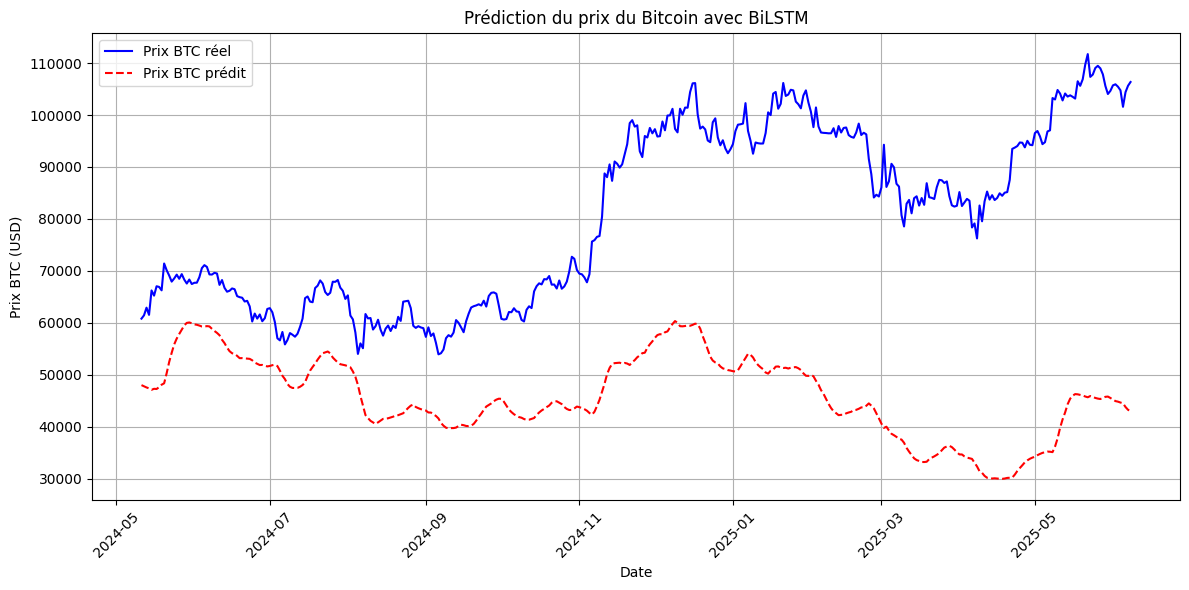

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Récupération des données depuis CryptoCompare ---
def collect_data_crypto_compare(crypto_symbol, start_timestamp, end_timestamp):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday'
    params = {
        'fsym': crypto_symbol,
        'tsym': 'USD',
        'limit': 2000,
        'toTs': end_timestamp
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()['Data']['Data']
        df = pd.DataFrame(data)
        df['time'] = pd.to_datetime(df['time'], unit='s')
        return df
    else:
        print(f"Erreur lors de la récupération des données pour {crypto_symbol}")
        return None

# --- Prétraitement ---
def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))
    df = df.sort_values('time')
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()
    df.dropna(inplace=True)
    return df

# --- Séquences ---
def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        X.append(eth_prices[i:i+seq_length])
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# --- Modèle BiLSTM ---
def build_model(seq_length, features=1):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(seq_length, features)),
        Dropout(0.2),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# --- Fonction principale ---
def main(bitcoin_data, ethereum_data):
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : données manquantes")
        return None

    data = preprocess_data(bitcoin_data, ethereum_data)
    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    model = build_model(seq_length)

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    y_pred = model.predict(X_test)
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    test_dates = data['time'].iloc[-len(y_test):].values
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin avec BiLSTM')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return model, eth_scaler, btc_scaler

# --- Appel des fonctions ---
start_timestamp = int(time.mktime(datetime(2021, 3, 1).timetuple()))
end_timestamp = int(time.time())

btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

if btc_data is not None and eth_data is not None:
    model, eth_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Échec de récupération des données.")


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0589 - mae: 0.1581 - val_loss: 0.0031 - val_mae: 0.0467
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0192 - mae: 0.0906 - val_loss: 0.0042 - val_mae: 0.0594
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0158 - mae: 0.0836 - val_loss: 0.0025 - val_mae: 0.0390
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0153 - mae: 0.0810 - val_loss: 0.0077 - val_mae: 0.0810
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0151 - mae: 0.0850 - val_loss: 0.0101 - val_mae: 0.0921
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0130 - mae: 0.0780 - val_loss: 0.0056 - val_mae: 0.0668
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0132 - mae: 0.0772 - val_loss: 0.0022 - val_mae: 0.0342
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0155 - mae: 0.0816 - val_loss: 0.0112 - val_mae: 0.0966
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - lo

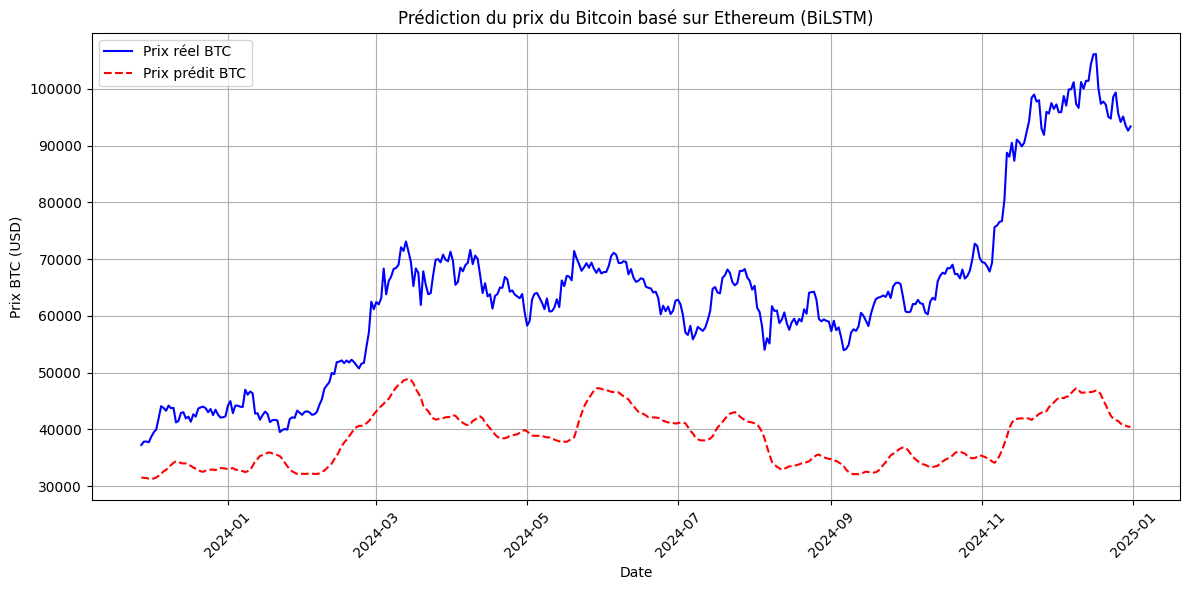

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Fonction de collecte des données (exemple générique)
def collect_data_crypto_compare(symbol, start_timestamp, end_timestamp):
    url = f"https://min-api.cryptocompare.com/data/v2/histoday?fsym={symbol}&tsym=USD&limit=2000&toTs={end_timestamp}"
    response = requests.get(url)
    data = response.json()
    if data['Response'] == 'Success':
        df = pd.DataFrame(data['Data']['Data'])
        df['time'] = pd.to_datetime(df['time'], unit='s')
        return df
    return None

# Prétraitement des données
def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))
    df = df.sort_values('time')
    df.dropna(inplace=True)
    return df

# Création des séquences
def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        X.append(eth_prices[i:i+seq_length])
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# Construction du modèle BiLSTM
def build_model(seq_length):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(seq_length, 1)),
        Dropout(0.2),
        Bidirectional(LSTM(64)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# Main
start_timestamp = int(datetime(2019, 1, 1).timestamp())
end_timestamp = int(datetime(2024, 12, 31).timestamp())
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

def main(btc_data, eth_data):
    if btc_data is None or eth_data is None:
        print("Erreur : données manquantes.")
        return

    data = preprocess_data(btc_data, eth_data)

    seq_length = 30

    # Séparer données en train/test AVANT le scaling
    train_size = int(len(data) * 0.8)
    train_data = data.iloc[:train_size]
    test_data = data.iloc[train_size - seq_length:]  # inclure une séquence complète avant test

    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    eth_train_scaled = eth_scaler.fit_transform(train_data[['close_eth']])
    btc_train_scaled = btc_scaler.fit_transform(train_data[['close_btc']])

    eth_test_scaled = eth_scaler.transform(test_data[['close_eth']])
    btc_test_scaled = btc_scaler.transform(test_data[['close_btc']])

    X_train, y_train = create_sequences(eth_train_scaled, btc_train_scaled, seq_length)
    X_test, y_test = create_sequences(eth_test_scaled, btc_test_scaled, seq_length)

    X_train = X_train.reshape((X_train.shape[0], seq_length, 1))
    X_test = X_test.reshape((X_test.shape[0], seq_length, 1))

    model = build_model(seq_length)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                        validation_split=0.2, callbacks=[early_stop], verbose=1)

    y_pred = model.predict(X_test)

    y_test_inv = btc_scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_inv = btc_scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_inv, y_pred_inv)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2: {r2:.4f}")

    # Affichage
    test_dates = test_data['time'].iloc[seq_length:].values
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_inv, label='Prix réel BTC', color='blue')
    plt.plot(test_dates, y_pred_inv, label='Prix prédit BTC', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin basé sur Ethereum (BiLSTM)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return model

if btc_data is not None and eth_data is not None:
    model = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")


### Utilisation du data ETH-BTC pour prédire les prix du bitcoin

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0178 - mae: 0.0921 - val_loss: 0.0021 - val_mae: 0.0332
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0020 - mae: 0.0307 - val_loss: 8.5449e-04 - val_mae: 0.0195
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013 - mae: 0.0245 - val_loss: 0.0014 - val_mae: 0.0264
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - mae: 0.0234 - val_loss: 8.6905e-04 - val_mae: 0.0195
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - mae: 0.0227 - val_loss: 6.5516e-04 - val_mae: 0.0196
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - mae: 0.0259 - val_loss: 0.0028 - val_mae: 0.0414
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - mae: 0.0230 - val_loss: 0.0022 - val_mae: 0.0367
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.3846e-04 - mae: 0.0208 - val_loss: 0.0013 - val_mae: 0.0261
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 

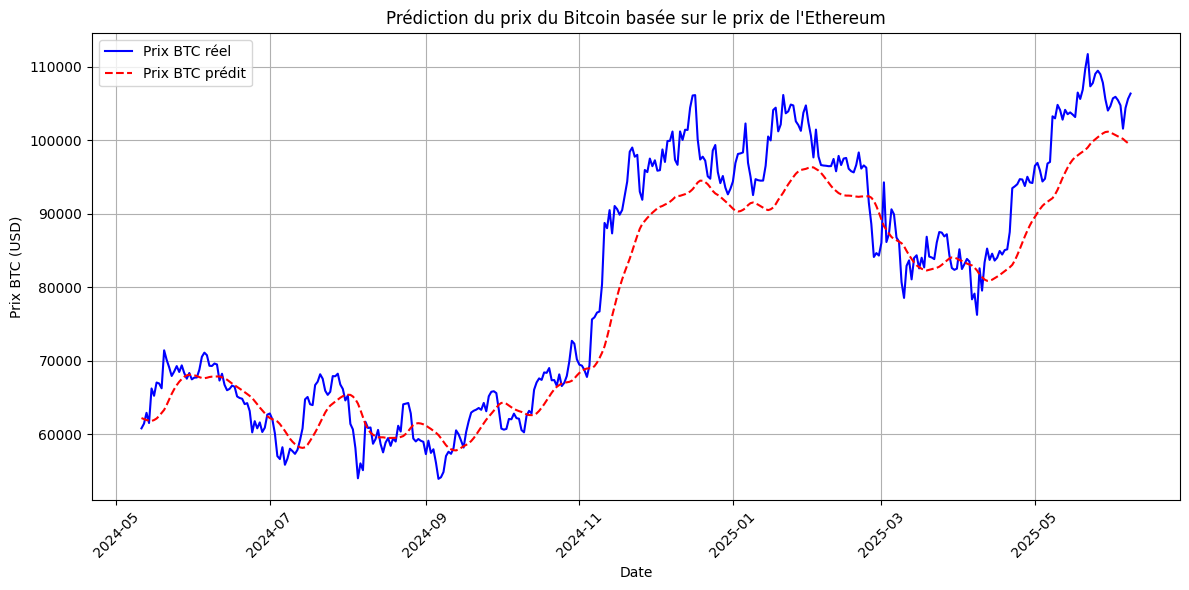

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Fonction pour récupérer les données historiques de CryptoCompare
def collect_data_crypto_compare(crypto_symbol, start_timestamp, end_timestamp):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday'
    params = {
        'fsym': crypto_symbol,  # Symbole de la cryptomonnaie (BTC ou ETH)
        'tsym': 'USD',  # Devise de comparaison
        'limit': 2000,  # Limite des jours à récupérer
        'toTs': end_timestamp,  # Timestamp de fin
        'extraParams': 'crypto_prediction'  # Paramètre optionnel pour l'identification de l'application
    }
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()['Data']['Data']
        df = pd.DataFrame(data)

        # Convertir les timestamps en dates lisibles
        df['time'] = pd.to_datetime(df['time'], unit='s')

        return df
    else:
        print(f"Erreur lors de la récupération des données: {response.status_code}")
        return None

# Fonction pour prétraiter les données
def preprocess_data(btc_df, eth_df):
    # Fusionner les données BTC et ETH sur la colonne 'time'
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))

    # Conversion de la colonne time au format datetime si nécessaire
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Trier les données par ordre chronologique
    df = df.sort_values('time')

    # Calculer les retours journaliers pour BTC et ETH
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()

    # Supprimer les lignes avec des valeurs NaN
    df.dropna(inplace=True)

    return df

# Fonction pour créer des séquences pour l'entraînement LSTM
def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        # Utiliser les séquences de prix ETH et BTC comme features
        X.append(np.column_stack((eth_prices[i:i+seq_length], btc_prices[i:i+seq_length])))
        # Utiliser le prix BTC comme cible
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# Fonction pour construire le modèle LSTM
def build_model(seq_length, features=2):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_length, features)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None  # Retourner None si les données sont invalides

    # Prétraitement des données
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Création des scalers pour BTC et ETH séparément pour une meilleure mise à l'échelle
    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Mise à l'échelle des prix
    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)

    # Reshape pour LSTM (samples, time steps, features)
    X = X.reshape((X.shape[0], X.shape[1], 2))  # Chaque séquence a 2 caractéristiques (ETH et BTC)

    # Division train/test (en respectant la chronologie)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Construction et entraînement du modèle
    model = build_model(seq_length)

    # Utilisation d'early stopping pour éviter le surapprentissage
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # Prédictions
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin basée sur le prix de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, eth_scaler, btc_scaler

# Récupérer les données historiques pour Bitcoin et Ethereum
today = datetime.today()
end_timestamp = int(time.mktime(today.timetuple()))
start_timestamp = 1614556800  # Exemple : début de l'année 2021

btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Appeler la fonction principale avec les données récupérées
if btc_data is not None and eth_data is not None:
    model, eth_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0287 - mae: 0.1172 - val_loss: 0.0030 - val_mae: 0.0414
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0024 - mae: 0.0329 - val_loss: 0.0014 - val_mae: 0.0301
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - mae: 0.0232 - val_loss: 6.8832e-04 - val_mae: 0.0201
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.2110e-04 - mae: 0.0194 - val_loss: 0.0013 - val_mae: 0.0297
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.7012e-04 - mae: 0.0205 - val_loss: 3.8564e-04 - val_mae: 0.0131
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.9459e-04 - mae: 0.0182 - val_loss: 6.3073e-04 - val_mae: 0.0192
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.0371e-04 - mae: 0.0182 - val_loss: 2.8398e-04 - val_mae: 0.0123
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.6866e-04 - mae: 0.0211 - val_loss: 9.5637e-04 - val_mae: 0.0253
Epoch 9/100
40/40 ━━━

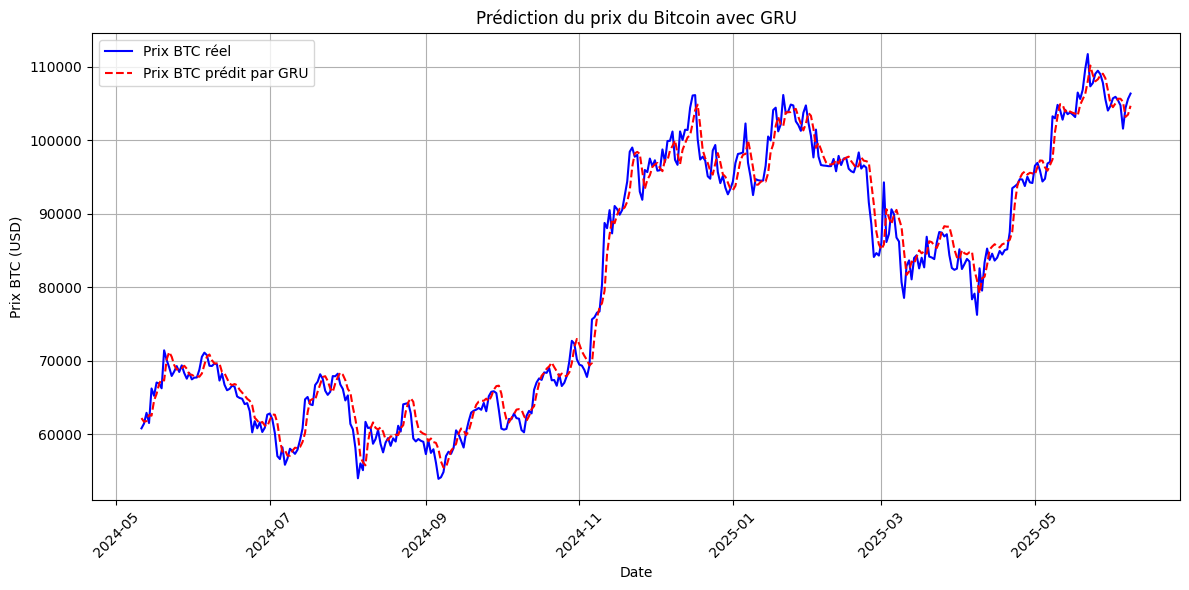

In [ ]:
# Fonction pour créer des séquences pour l'entraînement GRU
def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        # Utiliser les séquences de prix ETH et BTC comme features
        X.append(np.column_stack((eth_prices[i:i+seq_length], btc_prices[i:i+seq_length])))
        # Utiliser le prix BTC comme cible
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# Fonction pour construire le modèle GRU
def build_gru_model(seq_length, features=2):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(seq_length, features)),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None  # Retourner None si les données sont invalides

    # Prétraitement des données
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Création des scalers pour BTC et ETH séparément pour une meilleure mise à l'échelle
    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Mise à l'échelle des prix
    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)

    # Reshape pour GRU (samples, time steps, features)
    X = X.reshape((X.shape[0], X.shape[1], 2))  # Chaque séquence a 2 caractéristiques (ETH et BTC)

    # Division train/test (en respectant la chronologie)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Construction et entraînement du modèle GRU
    gru_model = build_gru_model(seq_length)

    # Utilisation d'early stopping pour éviter le surapprentissage
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    gru_history = gru_model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # Prédictions avec le modèle GRU
    gru_pred = gru_model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    gru_pred_btc = btc_scaler.inverse_transform(gru_pred)

    # Évaluation du modèle GRU
    gru_mse = mean_squared_error(y_test_btc, gru_pred_btc)
    gru_rmse = np.sqrt(gru_mse)
    gru_r2 = r2_score(y_test_btc, gru_pred_btc)

    print(f"GRU - MSE: {gru_mse:.2f}")
    print(f"GRU - RMSE: {gru_rmse:.2f}")
    print(f"GRU - R²: {gru_r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, gru_pred_btc, label='Prix BTC prédit par GRU', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin avec GRU')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return gru_model, eth_scaler, btc_scaler

# Récupérer les données historiques pour Bitcoin et Ethereum
today = datetime.today()
end_timestamp = int(time.mktime(today.timetuple()))
start_timestamp = 1614556800  # Exemple : début de l'année 2021

btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Appeler la fonction principale avec les données récupérées
if btc_data is not None and eth_data is not None:
    gru_model, eth_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0845 - mae: 0.2066 - val_loss: 0.0019 - val_mae: 0.0342
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0095 - mae: 0.0718 - val_loss: 0.0100 - val_mae: 0.0705
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0053 - mae: 0.0529 - val_loss: 0.0078 - val_mae: 0.0636
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0033 - mae: 0.0425 - val_loss: 0.0026 - val_mae: 0.0351
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0039 - mae: 0.0437 - val_loss: 0.0045 - val_mae: 0.0438
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - mae: 0.0404 - val_loss: 0.0039 - val_mae: 0.0421
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023 - mae: 0.0339 - val_loss: 0.0036 - val_mae: 0.0418
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0324 - val_loss: 0.0013 - val_mae: 0.0252
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

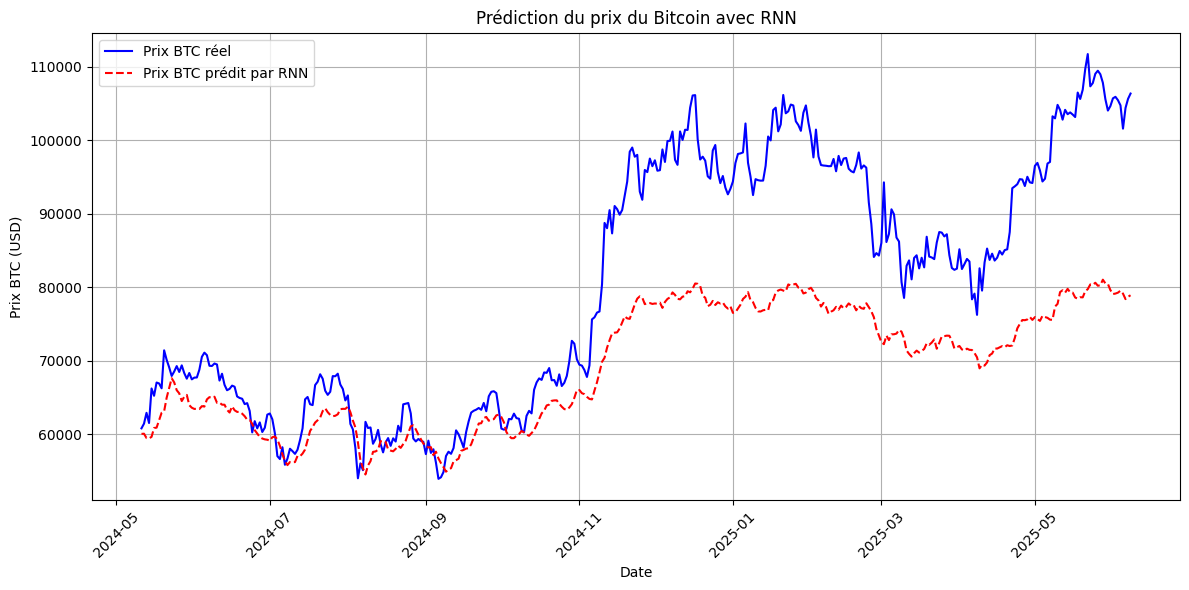

In [ ]:
# Fonction pour créer des séquences pour l'entraînement RNN
def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        # Utiliser les séquences de prix ETH et BTC comme features
        X.append(np.column_stack((eth_prices[i:i+seq_length], btc_prices[i:i+seq_length])))
        # Utiliser le prix BTC comme cible
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# Fonction pour construire le modèle RNN
def build_rnn_model(seq_length, features=2):
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=(seq_length, features)),
        Dropout(0.2),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None  # Retourner None si les données sont invalides

    # Prétraitement des données
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Création des scalers pour BTC et ETH séparément pour une meilleure mise à l'échelle
    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Mise à l'échelle des prix
    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)

    # Reshape pour RNN (samples, time steps, features)
    X = X.reshape((X.shape[0], X.shape[1], 2))  # Chaque séquence a 2 caractéristiques (ETH et BTC)

    # Division train/test (en respectant la chronologie)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Construction et entraînement du modèle RNN
    rnn_model = build_rnn_model(seq_length)

    # Utilisation d'early stopping pour éviter le surapprentissage
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    rnn_history = rnn_model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # Prédictions avec le modèle RNN
    rnn_pred = rnn_model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    rnn_pred_btc = btc_scaler.inverse_transform(rnn_pred)

    # Évaluation du modèle RNN
    rnn_mse = mean_squared_error(y_test_btc, rnn_pred_btc)
    rnn_rmse = np.sqrt(rnn_mse)
    rnn_r2 = r2_score(y_test_btc, rnn_pred_btc)

    print(f"RNN - MSE: {rnn_mse:.2f}")
    print(f"RNN - RMSE: {rnn_rmse:.2f}")
    print(f"RNN - R²: {rnn_r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, rnn_pred_btc, label='Prix BTC prédit par RNN', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin avec RNN')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return rnn_model, eth_scaler, btc_scaler

# Récupérer les données historiques pour Bitcoin et Ethereum
today = datetime.today()
end_timestamp = int(time.mktime(today.timetuple()))
start_timestamp = 1614556800  # Exemple : début de l'année 2021

btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Appeler la fonction principale avec les données récupérées
if btc_data is not None and eth_data is not None:
    rnn_model, eth_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0255 - mae: 0.1063 - val_loss: 0.0046 - val_mae: 0.0500
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023 - mae: 0.0338 - val_loss: 0.0010 - val_mae: 0.0247
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014 - mae: 0.0257 - val_loss: 0.0011 - val_mae: 0.0271
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0012 - mae: 0.0235 - val_loss: 0.0011 - val_mae: 0.0226
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0013 - mae: 0.0236 - val_loss: 8.0780e-04 - val_mae: 0.0188
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - mae: 0.0228 - val_loss: 7.1332e-04 - val_mae: 0.0177
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.5540e-04 - mae: 0.0201 - val_loss: 4.5701e-04 - val_mae: 0.0154
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.9713e-04 - mae: 0.0190 - val_loss: 4.4889e-04 - val_mae: 0.0151
Epoch 9/100
40/40 ━━━━━━━━━━━━━━

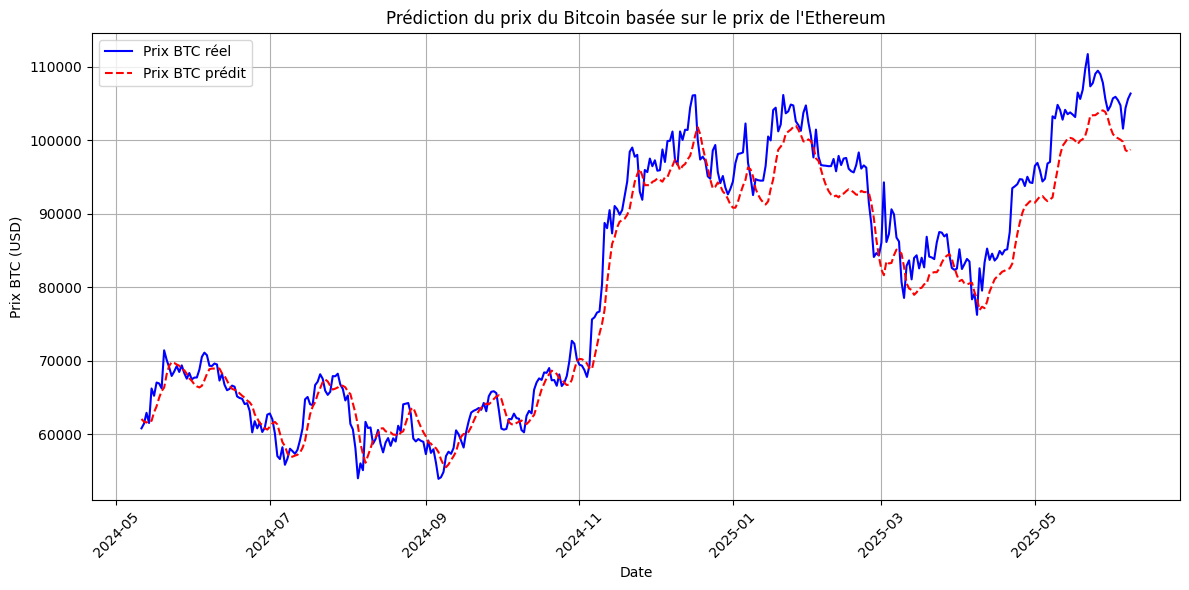

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Fonction pour récupérer les données historiques de CryptoCompare
def collect_data_crypto_compare(crypto_symbol, start_timestamp, end_timestamp):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday'
    params = {
        'fsym': crypto_symbol,
        'tsym': 'USD',
        'limit': 2000,
        'toTs': end_timestamp,
        'extraParams': 'crypto_prediction'
    }
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()['Data']['Data']
        df = pd.DataFrame(data)
        df['time'] = pd.to_datetime(df['time'], unit='s')
        return df
    else:
        print(f"Erreur lors de la récupération des données: {response.status_code}")
        return None

# Fonction de prétraitement
def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time')
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()
    df.dropna(inplace=True)
    return df

# Fonction pour créer des séquences
def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        X.append(np.column_stack((eth_prices[i:i+seq_length], btc_prices[i:i+seq_length])))
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# Modèle BiLSTM
def build_model(seq_length, features=2):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(seq_length, features)),
        Dropout(0.2),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None

    data = preprocess_data(bitcoin_data, ethereum_data)

    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])

    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)

    X = X.reshape((X.shape[0], X.shape[1], 2))

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    model = build_model(seq_length)

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    y_pred = model.predict(X_test)

    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    plt.figure(figsize=(12, 6))
    test_dates = data['time'].iloc[-len(y_test):].values
    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title("Prédiction du prix du Bitcoin basée sur le prix de l'Ethereum")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return model, eth_scaler, btc_scaler

# Exécution
today = datetime.today()
end_timestamp = int(time.mktime(today.timetuple()))
start_timestamp = 1614556800
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

if btc_data is not None and eth_data is not None:
    model, eth_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")

### Fusionnement du data btc-eth

Epoch 1/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1275 - mae: 0.1052 - val_loss: 0.1036 - val_mae: 0.1702 - learning_rate: 0.0010
Epoch 2/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0691 - mae: 0.0602 - val_loss: 0.0716 - val_mae: 0.1622 - learning_rate: 0.0010
Epoch 3/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0430 - mae: 0.0526 - val_loss: 0.0797 - val_mae: 0.2177 - learning_rate: 0.0010
Epoch 4/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0310 - mae: 0.0520 - val_loss: 0.0531 - val_mae: 0.1674 - learning_rate: 0.0010
Epoch 5/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0249 - mae: 0.0467 - val_loss: 0.0522 - val_mae: 0.1728 - learning_rate: 0.0010
Epoch 6/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0218 - mae: 0.0472 - val_loss: 0.0582 - val_mae: 0.1948 - learning_rate: 0.0010
Epoch 7/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0196 - mae: 0.0480 - val_loss: 0.0429 - val_mae: 0.1603 - learning_rate: 0.0010
Epoch 

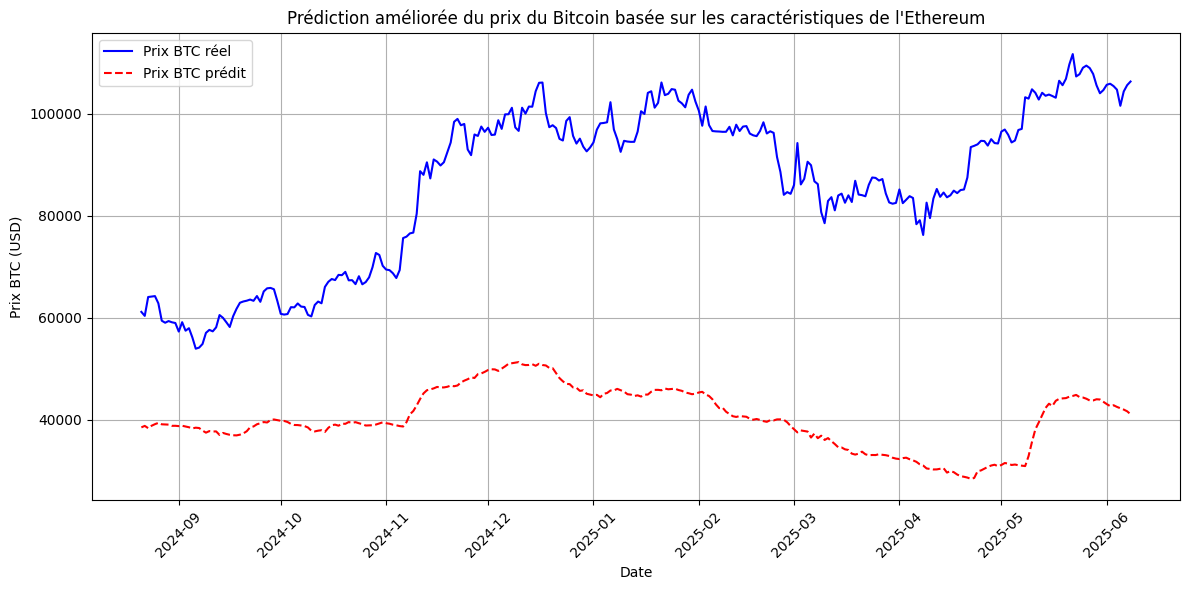

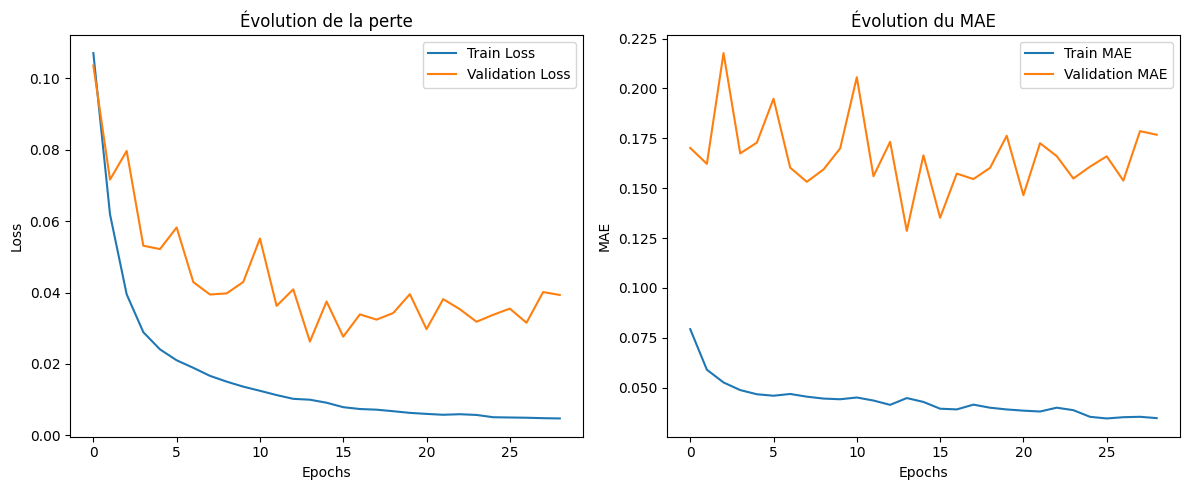

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2


# Récupérer les données historiques de Bitcoin et Ethereum
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Fonction pour prétraiter les données avec des features supplémentaires
def preprocess_data(btc_df, eth_df):
    # Fusionner les données BTC et ETH sur la colonne 'time'
    df = pd.merge(btc_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                 eth_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                 on='time',
                 suffixes=('_btc', '_eth'))

    # Conversion de la colonne time au format datetime si nécessaire
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Trier les données par ordre chronologique
    df = df.sort_values('time')

    # Calcul des features techniques pour Ethereum
    # Moyennes mobiles
    df['eth_ma7'] = df['close_eth'].rolling(window=7).mean()
    df['eth_ma14'] = df['close_eth'].rolling(window=14).mean()
    df['eth_ma30'] = df['close_eth'].rolling(window=30).mean()

    # Volatilité (écart-type sur une fenêtre)
    df['eth_volatility7'] = df['close_eth'].rolling(window=7).std()

    # Range journalier (high-low)
    df['eth_daily_range'] = df['high_eth'] - df['low_eth']

    # Ratio volume/price
    df['eth_volume_price_ratio'] = df['volumeto_eth'] / df['close_eth']

    # Rate of change (variation relative)
    df['eth_roc5'] = df['close_eth'].pct_change(periods=5)
    df['eth_roc10'] = df['close_eth'].pct_change(periods=10)

    # Calculer les retours journaliers pour BTC et ETH
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()

    # Momentum (prix actuel / prix n jours avant)
    df['eth_momentum5'] = df['close_eth'] / df['close_eth'].shift(5)
    df['eth_momentum10'] = df['close_eth'] / df['close_eth'].shift(10)

    # Supprimer les lignes avec des valeurs NaN
    df.dropna(inplace=True)

    return df

# Fonction pour créer des séquences pour l'entraînement avec features multiples
def create_sequences(df, seq_length=30):
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    # Cibles
    target = 'close_btc'

    X, y = [], []
    for i in range(len(df) - seq_length):
        # Extraire toutes les features d'Ethereum
        feature_sequence = df[features_list].iloc[i:i+seq_length].values
        X.append(feature_sequence)
        # Utiliser le prix BTC comme cible
        y.append(df[target].iloc[i+seq_length])

    return np.array(X), np.array(y).reshape(-1, 1)

# Fonction pour construire un modèle CNN-LSTM hybride
def build_hybrid_model(seq_length, features=12):
    model = Sequential([
        # Couche CNN pour extraire des patterns locaux
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(seq_length, features)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # Couche CNN secondaire
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # LSTM bidirectionnel pour capturer des dépendances à long terme
        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))),
        Dropout(0.3),

        # LSTM final
        LSTM(64, return_sequences=False, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dropout(0.3),

        # Couches denses finales
        Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None

    # Prétraitement des données avec features étendues
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Scaler pour toutes les features et la cible
    feature_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Liste des colonnes de features à utiliser
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    # Mise à l'échelle
    scaled_features = feature_scaler.fit_transform(data[features_list])
    data[features_list] = scaled_features

    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])
    data['close_btc'] = btc_scaled

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(data, seq_length)

    # Division train/test/validation (en respectant la chronologie)
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)

    X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
    y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

    # Construction du modèle hybride
    model = build_hybrid_model(seq_length, features=len(features_list))

    # Callbacks avancés
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )

    # Entraînement avec validation séparée
    history = model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Évaluation sur l'ensemble de test
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction améliorée du prix du Bitcoin basée sur les caractéristiques de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Visualisation de l'historique d'entraînement
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Évolution de la perte')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Évolution du MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, feature_scaler, btc_scaler

# Appeler la fonction principale avec les données récupérées
if btc_data is not None and eth_data is not None:
    model, feature_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")

Epoch 1/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1217 - mae: 0.1241 - val_loss: 0.0893 - val_mae: 0.1417 - learning_rate: 0.0010
Epoch 2/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0652 - mae: 0.0595 - val_loss: 0.0823 - val_mae: 0.1890 - learning_rate: 0.0010
Epoch 3/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0449 - mae: 0.0564 - val_loss: 0.0704 - val_mae: 0.1856 - learning_rate: 0.0010
Epoch 4/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0339 - mae: 0.0509 - val_loss: 0.0795 - val_mae: 0.2224 - learning_rate: 0.0010
Epoch 5/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0296 - mae: 0.0524 - val_loss: 0.0520 - val_mae: 0.1627 - learning_rate: 0.0010
Epoch 6/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0258 - mae: 0.0473 - val_loss: 0.0538 - val_mae: 0.1714 - learning_rate: 0.0010
Epoch 7/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0239 - mae: 0.0489 - val_loss: 0.0607 - val_mae: 0.1934 - learning_rate: 0.0010
Epoch 

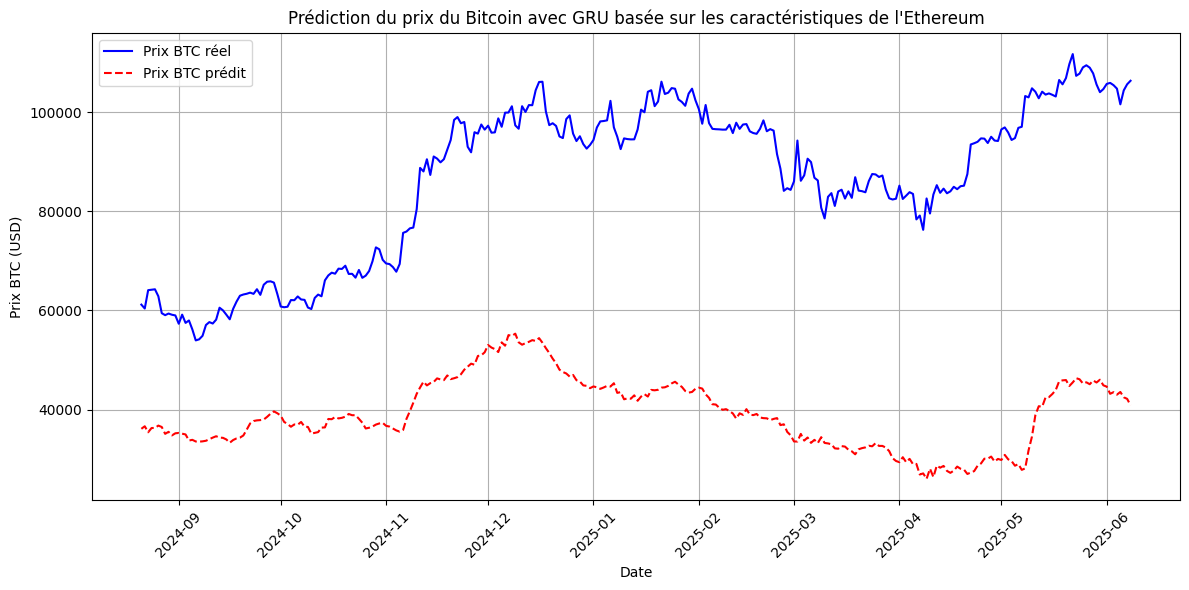

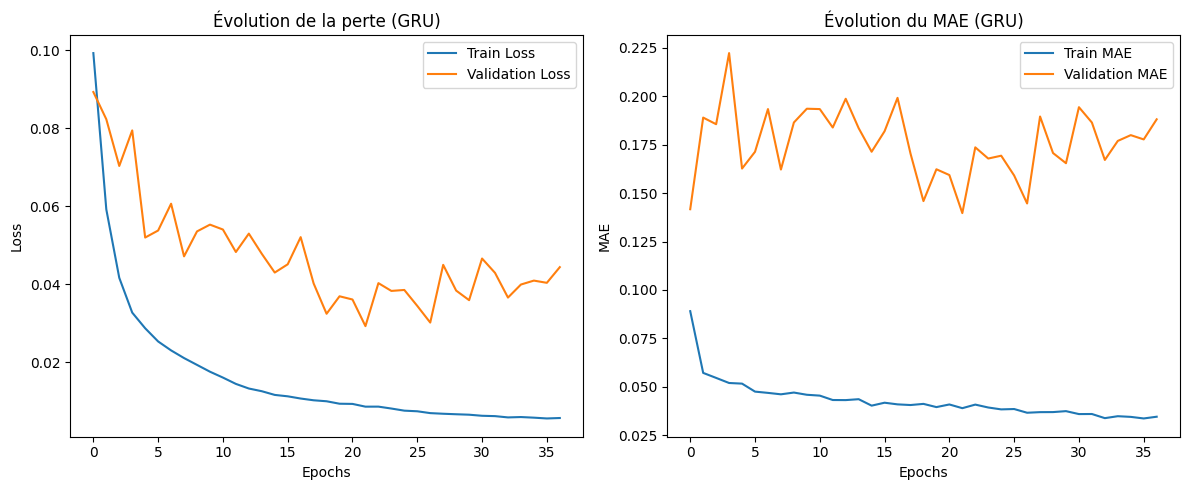

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2


# Récupérer les données historiques de Bitcoin et Ethereum
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Fonction pour prétraiter les données avec des features supplémentaires
def preprocess_data(btc_df, eth_df):
    # Fusionner les données BTC et ETH sur la colonne 'time'
    df = pd.merge(btc_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                 eth_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                 on='time',
                 suffixes=('_btc', '_eth'))

    # Conversion de la colonne time au format datetime si nécessaire
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Trier les données par ordre chronologique
    df = df.sort_values('time')

    # Calcul des features techniques pour Ethereum
    # Moyennes mobiles
    df['eth_ma7'] = df['close_eth'].rolling(window=7).mean()
    df['eth_ma14'] = df['close_eth'].rolling(window=14).mean()
    df['eth_ma30'] = df['close_eth'].rolling(window=30).mean()

    # Volatilité (écart-type sur une fenêtre)
    df['eth_volatility7'] = df['close_eth'].rolling(window=7).std()

    # Range journalier (high-low)
    df['eth_daily_range'] = df['high_eth'] - df['low_eth']

    # Ratio volume/price
    df['eth_volume_price_ratio'] = df['volumeto_eth'] / df['close_eth']

    # Rate of change (variation relative)
    df['eth_roc5'] = df['close_eth'].pct_change(periods=5)
    df['eth_roc10'] = df['close_eth'].pct_change(periods=10)

    # Calculer les retours journaliers pour BTC et ETH
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()

    # Momentum (prix actuel / prix n jours avant)
    df['eth_momentum5'] = df['close_eth'] / df['close_eth'].shift(5)
    df['eth_momentum10'] = df['close_eth'] / df['close_eth'].shift(10)

    # Supprimer les lignes avec des valeurs NaN
    df.dropna(inplace=True)

    return df

# Fonction pour créer des séquences pour l'entraînement avec features multiples
def create_sequences(df, seq_length=30):
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    # Cibles
    target = 'close_btc'

    X, y = [], []
    for i in range(len(df) - seq_length):
        # Extraire toutes les features d'Ethereum
        feature_sequence = df[features_list].iloc[i:i+seq_length].values
        X.append(feature_sequence)
        # Utiliser le prix BTC comme cible
        y.append(df[target].iloc[i+seq_length])

    return np.array(X), np.array(y).reshape(-1, 1)

# Fonction pour construire un modèle CNN-GRU hybride
def build_hybrid_model(seq_length, features=12):
    model = Sequential([
        # Couche CNN pour extraire des patterns locaux
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(seq_length, features)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # Couche CNN secondaire
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # GRU bidirectionnel pour capturer des dépendances à long terme
        Bidirectional(GRU(64, return_sequences=True, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))),
        Dropout(0.3),

        # GRU final
        GRU(64, return_sequences=False, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dropout(0.3),

        # Couches denses finales
        Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None

    # Prétraitement des données avec features étendues
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Scaler pour toutes les features et la cible
    feature_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Liste des colonnes de features à utiliser
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    # Mise à l'échelle
    scaled_features = feature_scaler.fit_transform(data[features_list])
    data[features_list] = scaled_features

    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])
    data['close_btc'] = btc_scaled

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(data, seq_length)

    # Division train/test/validation (en respectant la chronologie)
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)

    X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
    y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

    # Construction du modèle hybride
    model = build_hybrid_model(seq_length, features=len(features_list))

    # Callbacks avancés
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )

    # Entraînement avec validation séparée
    history = model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Évaluation sur l'ensemble de test
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin avec GRU basée sur les caractéristiques de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Visualisation de l'historique d'entraînement
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Évolution de la perte (GRU)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Évolution du MAE (GRU)')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, feature_scaler, btc_scaler

# Appeler la fonction principale avec les données récupérées
if btc_data is not None and eth_data is not None:
    model, feature_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - loss: 0.1667 - mae: 0.1798 - val_loss: 0.1358 - val_mae: 0.1811 - learning_rate: 0.0010
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1115 - mae: 0.0856 - val_loss: 0.1213 - val_mae: 0.1536 - learning_rate: 0.0010
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1037 - mae: 0.0771 - val_loss: 0.1284 - val_mae: 0.1851 - learning_rate: 0.0010
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0969 - mae: 0.0650 - val_loss: 0.1188 - val_mae: 0.1690 - learning_rate: 0.0010
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0926 - mae: 0.0632 - val_loss: 0.1146 - val_mae: 0.1677 - learning_rate: 0.0010
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0878 - mae: 0.0592 - val_loss: 0.1047 - val_mae: 0.1484 - learning_rate: 0.0010
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0843 - mae: 0.0597 - val_loss: 0.1112 - val_mae: 0.1771 - learning_rate: 0.0010
Epoch 8

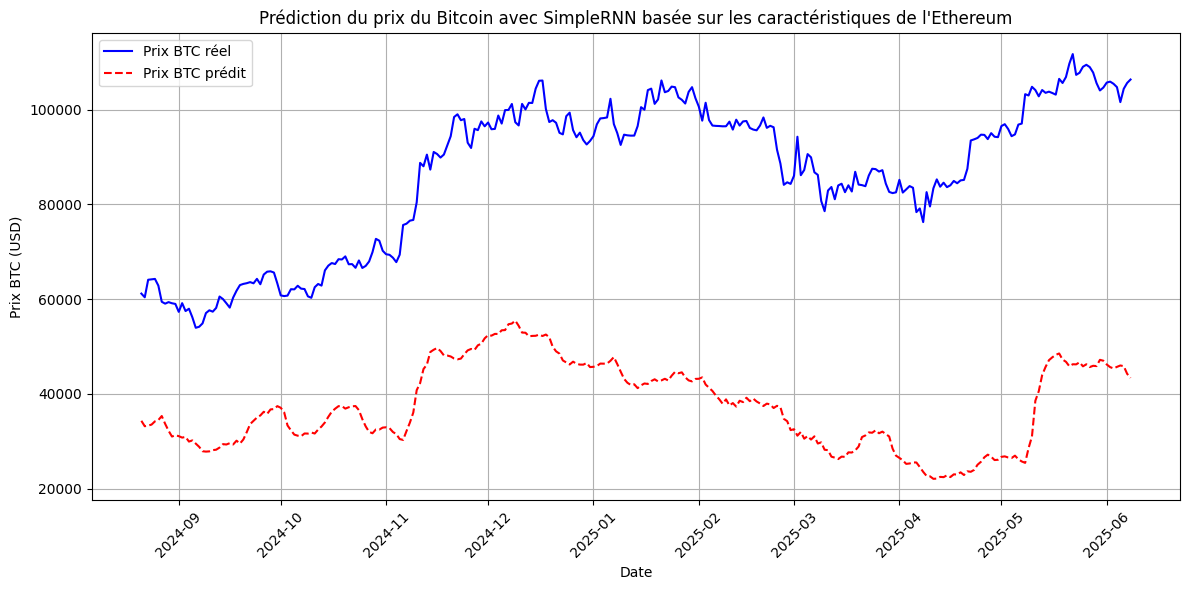

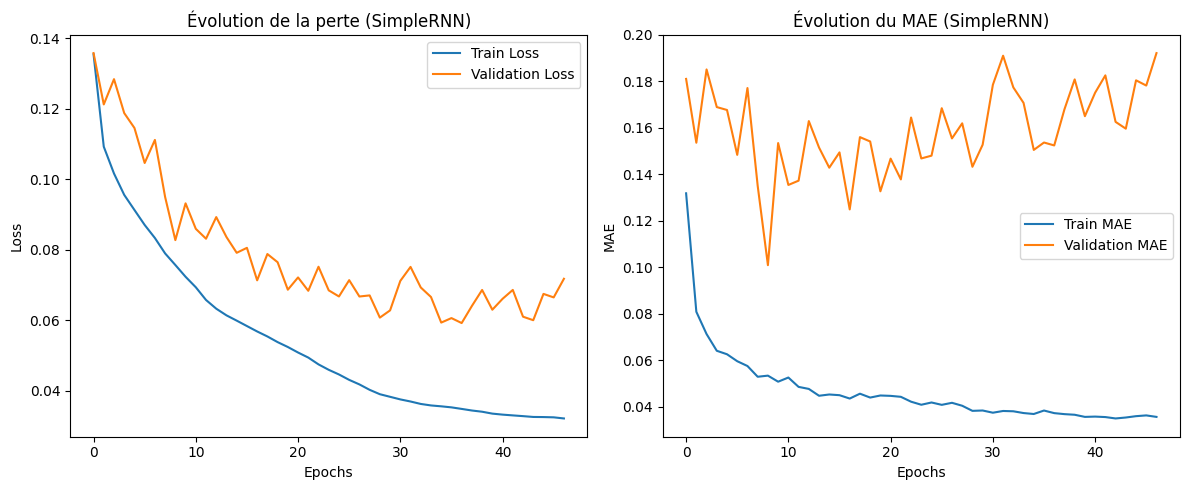

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2


# Récupérer les données historiques de Bitcoin et Ethereum
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Fonction pour prétraiter les données avec des features supplémentaires
def preprocess_data(btc_df, eth_df):
    # Fusionner les données BTC et ETH sur la colonne 'time'
    df = pd.merge(btc_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                 eth_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                 on='time',
                 suffixes=('_btc', '_eth'))

    # Conversion de la colonne time au format datetime si nécessaire
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Trier les données par ordre chronologique
    df = df.sort_values('time')

    # Calcul des features techniques pour Ethereum
    # Moyennes mobiles
    df['eth_ma7'] = df['close_eth'].rolling(window=7).mean()
    df['eth_ma14'] = df['close_eth'].rolling(window=14).mean()
    df['eth_ma30'] = df['close_eth'].rolling(window=30).mean()

    # Volatilité (écart-type sur une fenêtre)
    df['eth_volatility7'] = df['close_eth'].rolling(window=7).std()

    # Range journalier (high-low)
    df['eth_daily_range'] = df['high_eth'] - df['low_eth']

    # Ratio volume/price
    df['eth_volume_price_ratio'] = df['volumeto_eth'] / df['close_eth']

    # Rate of change (variation relative)
    df['eth_roc5'] = df['close_eth'].pct_change(periods=5)
    df['eth_roc10'] = df['close_eth'].pct_change(periods=10)

    # Calculer les retours journaliers pour BTC et ETH
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()

    # Momentum (prix actuel / prix n jours avant)
    df['eth_momentum5'] = df['close_eth'] / df['close_eth'].shift(5)
    df['eth_momentum10'] = df['close_eth'] / df['close_eth'].shift(10)

    # Supprimer les lignes avec des valeurs NaN
    df.dropna(inplace=True)

    return df

# Fonction pour créer des séquences pour l'entraînement avec features multiples
def create_sequences(df, seq_length=30):
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    # Cibles
    target = 'close_btc'

    X, y = [], []
    for i in range(len(df) - seq_length):
        # Extraire toutes les features d'Ethereum
        feature_sequence = df[features_list].iloc[i:i+seq_length].values
        X.append(feature_sequence)
        # Utiliser le prix BTC comme cible
        y.append(df[target].iloc[i+seq_length])

    return np.array(X), np.array(y).reshape(-1, 1)

# Fonction pour construire un modèle CNN-SimpleRNN hybride
def build_simple_rnn_model(seq_length, features=12):
    model = Sequential([
        # Couche CNN pour extraire des patterns locaux
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(seq_length, features)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # Couche CNN secondaire
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # SimpleRNN bidirectionnel
        Bidirectional(SimpleRNN(128, return_sequences=True, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))),
        Dropout(0.3),

        # SimpleRNN final avec plus de neurones pour compenser la simplicité
        SimpleRNN(128, return_sequences=False, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dropout(0.3),

        # Couches denses plus larges pour compenser la simplicité du SimpleRNN
        Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None

    # Prétraitement des données avec features étendues
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Scaler pour toutes les features et la cible
    feature_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Liste des colonnes de features à utiliser
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    # Mise à l'échelle
    scaled_features = feature_scaler.fit_transform(data[features_list])
    data[features_list] = scaled_features

    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])
    data['close_btc'] = btc_scaled

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(data, seq_length)

    # Division train/test/validation (en respectant la chronologie)
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)

    X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
    y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

    # Construction du modèle SimpleRNN
    model = build_simple_rnn_model(seq_length, features=len(features_list))

    # Callbacks adaptés - patience réduite pour SimpleRNN
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,  # SimpleRNN converge souvent plus rapidement mais avec moins de précision
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,  # Réduisons la patience pour adaptation plus rapide
        min_lr=0.00005,
        verbose=1
    )

    # Entraînement avec validation séparée
    history = model.fit(
        X_train, y_train,
        epochs=100,  # SimpleRNN converge généralement plus rapidement
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Évaluation sur l'ensemble de test
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin avec SimpleRNN basée sur les caractéristiques de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Visualisation de l'historique d'entraînement
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Évolution de la perte (SimpleRNN)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Évolution du MAE (SimpleRNN)')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, feature_scaler, btc_scaler

# Appeler la fonction principale avec les données récupérées
if btc_data is not None and eth_data is not None:
    model, feature_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")

Epoch 1/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1368 - mae: 0.1311 - val_loss: 0.1010 - val_mae: 0.1618 - learning_rate: 0.0010
Epoch 2/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0701 - mae: 0.0610 - val_loss: 0.0792 - val_mae: 0.1803 - learning_rate: 0.0010
Epoch 3/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0436 - mae: 0.0532 - val_loss: 0.0709 - val_mae: 0.1964 - learning_rate: 0.0010
Epoch 4/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0319 - mae: 0.0548 - val_loss: 0.0446 - val_mae: 0.1374 - learning_rate: 0.0010
Epoch 5/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0257 - mae: 0.0517 - val_loss: 0.0454 - val_mae: 0.1502 - learning_rate: 0.0010
Epoch 6/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0229 - mae: 0.0519 - val_loss: 0.0537 - val_mae: 0.1819 - learning_rate: 0.0010
Epoch 7/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0191 - mae: 0.0430 - val_loss: 0.0510 - val_mae: 0.1816 - learning_rate: 0.0010
Epoch 

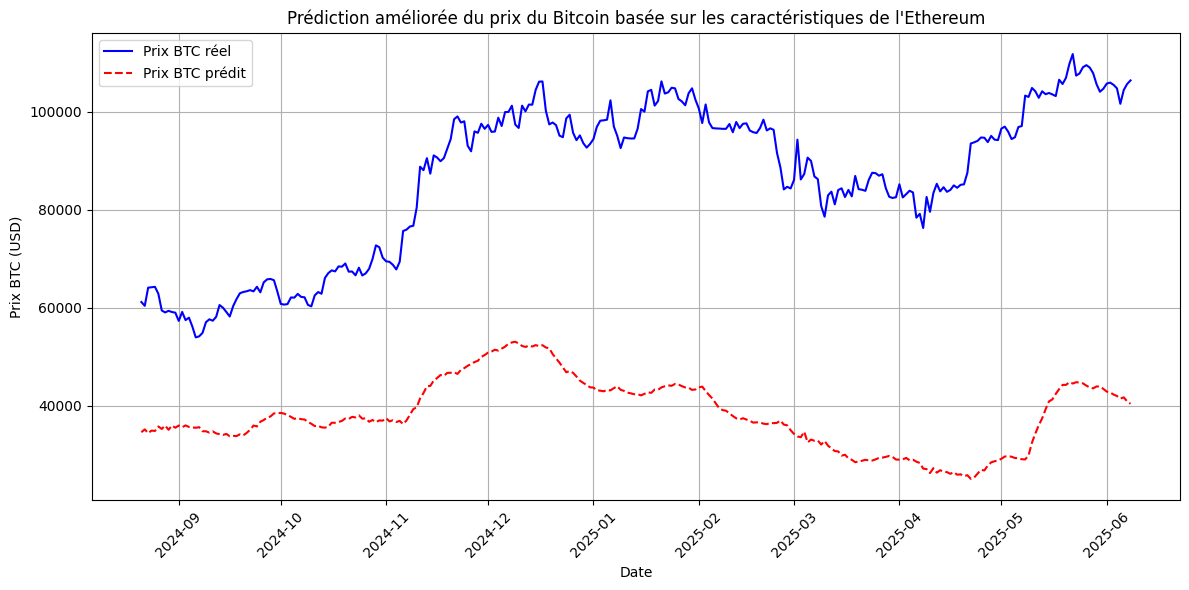

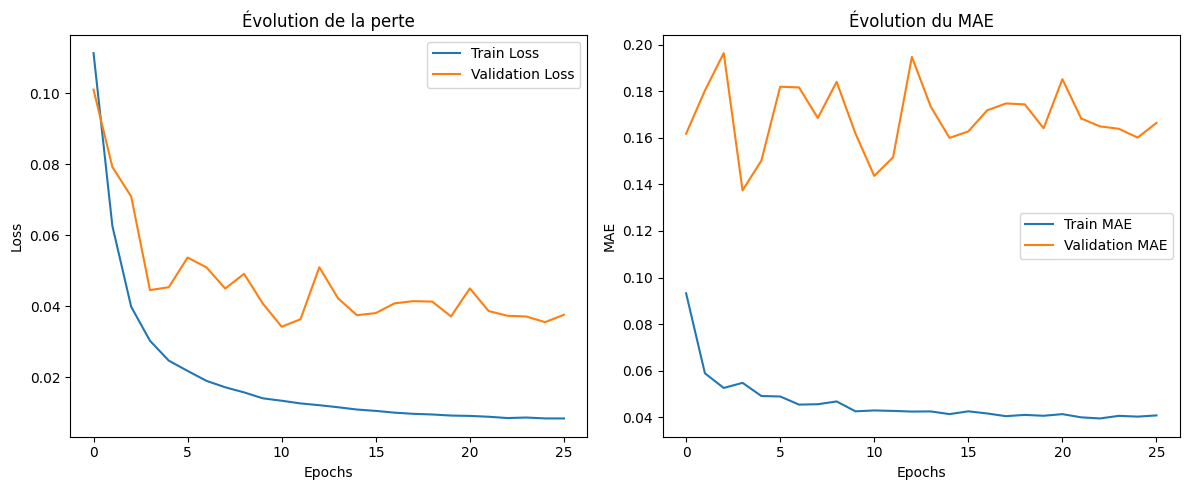

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2


# Récupérer les données historiques de Bitcoin et Ethereum
btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# Fonction pour prétraiter les données avec des features supplémentaires
def preprocess_data(btc_df, eth_df):
    # Fusionner les données BTC et ETH sur la colonne 'time'
    df = pd.merge(btc_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                 eth_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                 on='time',
                 suffixes=('_btc', '_eth'))

    # Conversion de la colonne time au format datetime si nécessaire
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Trier les données par ordre chronologique
    df = df.sort_values('time')

    # Calcul des features techniques pour Ethereum
    # Moyennes mobiles
    df['eth_ma7'] = df['close_eth'].rolling(window=7).mean()
    df['eth_ma14'] = df['close_eth'].rolling(window=14).mean()
    df['eth_ma30'] = df['close_eth'].rolling(window=30).mean()

    # Volatilité (écart-type sur une fenêtre)
    df['eth_volatility7'] = df['close_eth'].rolling(window=7).std()

    # Range journalier (high-low)
    df['eth_daily_range'] = df['high_eth'] - df['low_eth']

    # Ratio volume/price
    df['eth_volume_price_ratio'] = df['volumeto_eth'] / df['close_eth']

    # Rate of change (variation relative)
    df['eth_roc5'] = df['close_eth'].pct_change(periods=5)
    df['eth_roc10'] = df['close_eth'].pct_change(periods=10)

    # Calculer les retours journaliers pour BTC et ETH
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()

    # Momentum (prix actuel / prix n jours avant)
    df['eth_momentum5'] = df['close_eth'] / df['close_eth'].shift(5)
    df['eth_momentum10'] = df['close_eth'] / df['close_eth'].shift(10)

    # Supprimer les lignes avec des valeurs NaN
    df.dropna(inplace=True)

    return df

# Fonction pour créer des séquences pour l'entraînement avec features multiples
def create_sequences(df, seq_length=30):
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    # Cibles
    target = 'close_btc'

    X, y = [], []
    for i in range(len(df) - seq_length):
        # Extraire toutes les features d'Ethereum
        feature_sequence = df[features_list].iloc[i:i+seq_length].values
        X.append(feature_sequence)
        # Utiliser le prix BTC comme cible
        y.append(df[target].iloc[i+seq_length])

    return np.array(X), np.array(y).reshape(-1, 1)

# Fonction pour construire un modèle CNN-LSTM hybride
def build_hybrid_model(seq_length, features=12):
    model = Sequential([
        # Couche CNN pour extraire des patterns locaux
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(seq_length, features)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # Couche CNN secondaire
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # LSTM bidirectionnel pour capturer des dépendances à long terme
        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))),
        Dropout(0.3),

        # LSTM final
        LSTM(64, return_sequences=False, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dropout(0.3),

        # Couches denses finales
        Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def main(bitcoin_data, ethereum_data):
    # Vérifier si les données sont valides
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None

    # Prétraitement des données avec features étendues
    data = preprocess_data(bitcoin_data, ethereum_data)

    # Scaler pour toutes les features et la cible
    feature_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    # Liste des colonnes de features à utiliser
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    # Mise à l'échelle
    scaled_features = feature_scaler.fit_transform(data[features_list])
    data[features_list] = scaled_features

    btc_scaled = btc_scaler.fit_transform(data[['close_btc']])
    data['close_btc'] = btc_scaled

    # Création des séquences
    seq_length = 30
    X, y = create_sequences(data, seq_length)

    # Division train/test/validation (en respectant la chronologie)
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)

    X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
    y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

    # Construction du modèle hybride
    model = build_hybrid_model(seq_length, features=len(features_list))

    # Callbacks avancés
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )

    # Entraînement avec validation séparée
    history = model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Évaluation sur l'ensemble de test
    y_pred = model.predict(X_test)

    # Inversions pour obtenir les prix réels
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    # Évaluation du modèle
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation des prédictions
    plt.figure(figsize=(12, 6))

    # Récupérer les dates correspondantes aux données de test
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction améliorée du prix du Bitcoin basée sur les caractéristiques de l\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Visualisation de l'historique d'entraînement
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Évolution de la perte')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Évolution du MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Retourner le modèle et les scalers
    return model, feature_scaler, btc_scaler

# Appeler la fonction principale avec les données récupérées
if btc_data is not None and eth_data is not None:
    model, feature_scaler, btc_scaler = main(btc_data, eth_data)
else:
    print("Les données n'ont pas pu être récupérées.")

### Modèle avec biais

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 444ms/step - loss: 0.2229 - mae: 0.2627 - val_loss: 0.2814 - val_mae: 0.4203 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1300 - mae: 0.1282 - val_loss: 0.3138 - val_mae: 0.4582 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1232 - mae: 0.1144 - val_loss: 0.3168 - val_mae: 0.4626 - learning_rate: 0.0010
Epoch 4/100
 9/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1203 - mae: 0.1055 
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1184 - mae: 0.1015 - val_loss: 0.2906 - val_mae: 0.4351 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1133 - mae: 0.0914 - val_loss: 0.3045 - val_mae: 0.4516 - learning_rate: 5.0000e-04
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1100 - mae: 0.0832 - val_loss: 0.3015 - val_mae: 0.4491 - learning_rate: 5.00

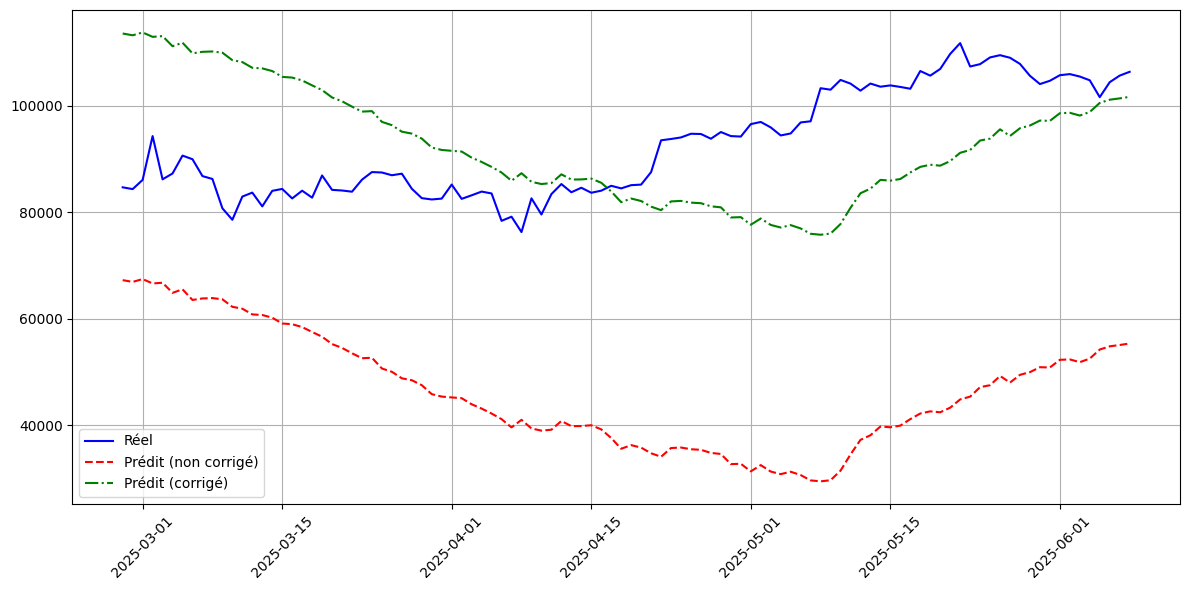

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2

# =========================
# Récupération des données
# =========================

def collect_data_crypto_compare(symbol, start_timestamp, end_timestamp):
    url = 'https://min-api.cryptocompare.com/data/v2/histoday'
    days = (end_timestamp - start_timestamp) // (24 * 3600) + 1
    limit = min(2000, days)

    params = {
        'fsym': symbol,
        'tsym': 'USD',
        'limit': limit,
        'toTs': end_timestamp
    }

    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        if data['Response'] == 'Success':
            df = pd.DataFrame(data['Data']['Data'])
            df['time'] = pd.to_datetime(df['time'], unit='s')
            return df
        else:
            print(f"Erreur API: {data['Message']}")
            return None
    else:
        print(f"Erreur HTTP: {response.status_code}")
        return None

# =========================================
# Prétraitement des données + features ETH
# =========================================

def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                  eth_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                  on='time',
                  suffixes=('_btc', '_eth'))
    df = df.sort_values('time')

    df['eth_ma7'] = df['close_eth'].rolling(window=7).mean()
    df['eth_ma14'] = df['close_eth'].rolling(window=14).mean()
    df['eth_ma30'] = df['close_eth'].rolling(window=30).mean()
    df['eth_volatility7'] = df['close_eth'].rolling(window=7).std()
    df['eth_daily_range'] = df['high_eth'] - df['low_eth']
    df['eth_volume_price_ratio'] = df['volumeto_eth'] / df['close_eth']
    df['eth_roc5'] = df['close_eth'].pct_change(periods=5)
    df['eth_roc10'] = df['close_eth'].pct_change(periods=10)
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()
    df['eth_momentum5'] = df['close_eth'] / df['close_eth'].shift(5)
    df['eth_momentum10'] = df['close_eth'] / df['close_eth'].shift(10)

    df.dropna(inplace=True)
    return df

# =====================
# Séquences X/y
# =====================

def create_sequences(df, seq_length=30):
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]
    target = 'close_btc'
    X, y = [], []
    for i in range(len(df) - seq_length):
        feature_sequence = df[features_list].iloc[i:i+seq_length].values
        X.append(feature_sequence)
        y.append(df[target].iloc[i+seq_length])
    return np.array(X), np.array(y).reshape(-1, 1)

# ====================
# Modèle SimpleRNN CNN
# ====================

def build_simple_rnn_model(seq_length, features=12):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(seq_length, features)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Bidirectional(SimpleRNN(128, return_sequences=True, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))),
        Dropout(0.3),
        SimpleRNN(128, return_sequences=False, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# ========================
# Entraînement + Analyse
# ========================

def main(bitcoin_data, ethereum_data):
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur de récupération des données.")
        return None

    data = preprocess_data(bitcoin_data, ethereum_data)

    feature_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    data[features_list] = feature_scaler.fit_transform(data[features_list])
    data['close_btc'] = btc_scaler.fit_transform(data[['close_btc']])

    seq_length = 30
    X, y = create_sequences(data, seq_length)

    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)
    X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
    y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

    model = build_simple_rnn_model(seq_length, features=len(features_list))

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00005, verbose=1)

    history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                        validation_data=(X_val, y_val),
                        callbacks=[early_stopping, reduce_lr], verbose=1)

    y_pred = model.predict(X_test)
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

    bias = np.mean(y_test_btc - y_pred_btc)
    y_pred_btc_corrected = y_pred_btc + bias

    mse_corrected = mean_squared_error(y_test_btc, y_pred_btc_corrected)
    rmse_corrected = np.sqrt(mse_corrected)
    r2_corrected = r2_score(y_test_btc, y_pred_btc_corrected)

    print(f"Après correction : MSE = {mse_corrected:.2f}, RMSE = {rmse_corrected:.2f}, R² = {r2_corrected:.4f}")

    # Visualisation
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_btc, label='Réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prédit (non corrigé)', color='red', linestyle='--')
    plt.plot(test_dates, y_pred_btc_corrected, label='Prédit (corrigé)', color='green', linestyle='-.')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return model, feature_scaler, btc_scaler, bias, X, data

# =======================
# Prédiction future
# =======================

def predict_future_price(model, feature_scaler, btc_scaler, bias, last_sequence, days_ahead=30):
    predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(days_ahead):
        pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], current_sequence.shape[1]))
        pred_btc = btc_scaler.inverse_transform(pred)[0][0]
        pred_btc_corrected = pred_btc + bias
        predictions.append(pred_btc_corrected)

    return predictions

# ======================
# Lancement du script
# ======================

if __name__ == "__main__":
    end_timestamp = int(time.time())
    start_timestamp = end_timestamp - (2 * 365 * 24 * 3600)

    btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
    eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

    results = main(btc_data, eth_data)

    if results:
        model, feature_scaler, btc_scaler, bias, X, data = results
        last_sequence = X[-1]
        future_predictions = predict_future_price(model, feature_scaler, btc_scaler, bias, last_sequence, days_ahead=30)

        print("\nPrévisions des 30 prochains jours :")
        for i, price in enumerate(future_predictions, 1):
            print(f"Jour {i}: {price:.2f} USD")


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 28, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_12 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_117 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,241 (102.50 KB)

 Trainable params: 26,241 (102.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.2498 - val_loss: 5.0354
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.1733 - val_loss: 2.0240
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.5037 - val_loss: 0.4164
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2450 - val_loss: 0.0902
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0496 - val_loss: 0.0536
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0298 - val_loss: 0.0322
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0280 - val_loss: 0.0433
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0251 - val_loss: 0.0369
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0255 - val_loss: 0.0550
Epoch 10/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0263 - val_loss: 0.0459
Epoch 11/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0247 - val_loss: 0.0419
Epoch 12/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0237 - val_

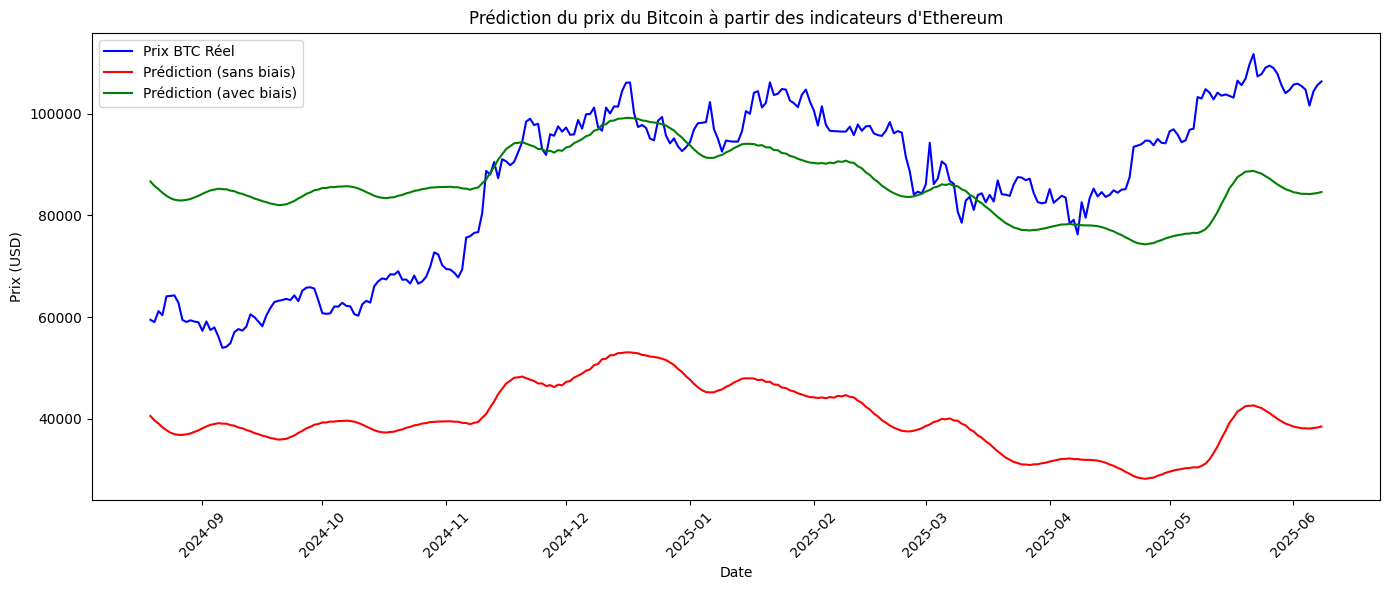

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

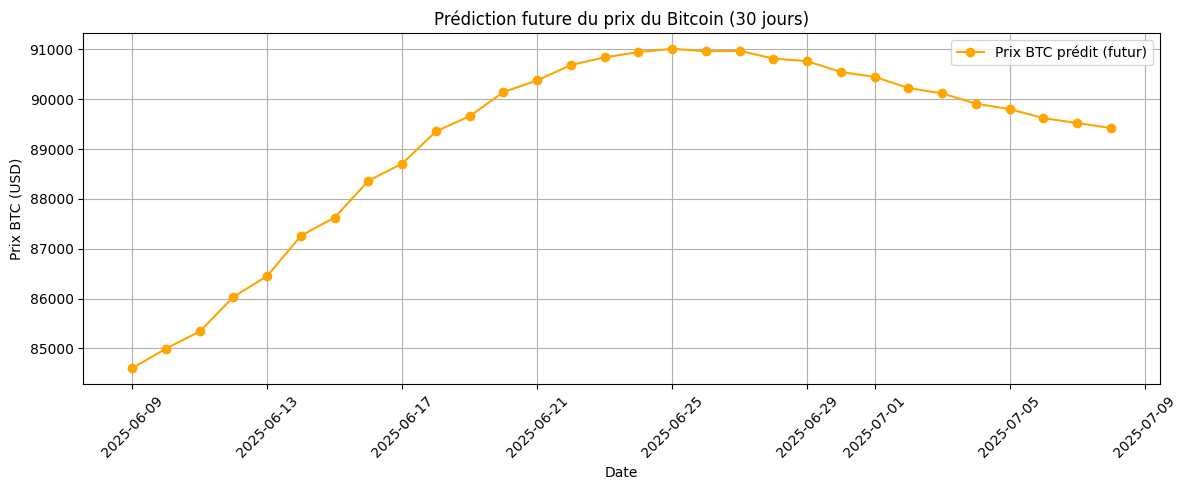

✅ Modèle sauvegardé sous le nom 'model_gru_bitcoin_eth.h5'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, GRU, Conv1D, MaxPooling1D, Flatten, Dropout
from keras.regularizers import l1_l2
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
from datetime import datetime

# =======================
# 1. Fonction pour charger les données CryptoCompare
# =======================
def load_crypto_data(symbol, comparison_symbol='USD', limit=2000):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday?fsym={symbol}&tsym={comparison_symbol}&limit={limit}'
    response = requests.get(url)
    data = response.json()['Data']['Data']
    df = pd.DataFrame(data)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    return df

# =======================
# 2. Ajout des indicateurs techniques
# =======================
def add_technical_indicators(df):
    df = df.copy()
    df['MA7'] = df['close'].rolling(window=7).mean()
    df['MA21'] = df['close'].rolling(window=21).mean()
    df['EMA'] = df['close'].ewm(span=20, adjust=False).mean()
    df['Momentum'] = df['close'] - df['close'].shift(1)
    df['Volatility'] = df['close'].rolling(window=7).std()
    return df.dropna()

# =======================
# 3. Création des séquences pour le modèle
# =======================
def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# =======================
# 4. Fonction pour prédire les prix futurs
# =======================
def predict_future_price(model, feature_scaler, target_scaler, bias, last_sequence, days_ahead=30):
    future_prices = []
    current_sequence = last_sequence.copy()

    for _ in range(days_ahead):
        input_seq = current_sequence.reshape(1, *current_sequence.shape)
        prediction_scaled = model.predict(input_seq)[0][0] + bias
        prediction = target_scaler.inverse_transform([[prediction_scaled]])[0][0]
        future_prices.append(prediction)

        # Simulation simplifiée : on copie les features précédents en décalant la dernière valeur prédite
        next_features = current_sequence[-1].copy()
        next_features[0] = prediction_scaled  # Met à jour 'close' prédite
        current_sequence = np.append(current_sequence[1:], [next_features], axis=0)

    return future_prices

# =======================
# 5. Chargement et préparation des données
# =======================
btc_data = load_crypto_data('BTC')
eth_data = load_crypto_data('ETH')

eth_data = add_technical_indicators(eth_data)
btc_data = btc_data.loc[eth_data.index]  # synchronise les index

features = eth_data[['close', 'MA7', 'MA21', 'EMA', 'Momentum', 'Volatility']]
target = btc_data['close']

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(features)
scaled_target = target_scaler.fit_transform(target.values.reshape(-1, 1))

window_size = 30
X, y = create_sequences(scaled_features, scaled_target, window_size)

# =======================
# 6. Séparation Train/Validation/Test
# =======================
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

# =======================
# 7. Construction du modèle GRU
# =======================
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(GRU(units=64, return_sequences=False, kernel_regularizer=l1_l2(0.01)))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

# =======================
# 8. Entraînement
# =======================
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val))

# =======================
# 9. Évaluation
# =======================
y_pred_scaled = model.predict(X_test)
bias = np.mean(y_test - y_pred_scaled)  # correction de biais
y_pred_scaled_bias = y_pred_scaled + bias

y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = target_scaler.inverse_transform(y_pred_scaled)
y_pred_bias_inv = target_scaler.inverse_transform(y_pred_scaled_bias)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

mae_bias = mean_absolute_error(y_test_inv, y_pred_bias_inv)
rmse_bias = np.sqrt(mean_squared_error(y_test_inv, y_pred_bias_inv))

print(f"MAE (sans biais): {mae:.2f}, RMSE: {rmse:.2f}")
print(f"MAE (avec biais): {mae_bias:.2f}, RMSE: {rmse_bias:.2f}")

# =======================
# 10. Visualisation des résultats
# =======================
dates_test = btc_data.index[-len(y_test):]

plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test_inv, label='Prix BTC Réel', color='blue')
plt.plot(dates_test, y_pred_inv, label='Prédiction (sans biais)', color='red')
plt.plot(dates_test, y_pred_bias_inv, label='Prédiction (avec biais)', color='green')
plt.title("Prédiction du prix du Bitcoin à partir des indicateurs d'Ethereum")
plt.xlabel("Date")
plt.ylabel("Prix (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# =======================
# 11. Prédiction future
# =======================
last_sequence = X[-1]  # dernière séquence connue
future_prices = predict_future_price(model, feature_scaler, target_scaler, bias, last_sequence, days_ahead=30)

future_dates = pd.date_range(start=btc_data.index[-1] + pd.Timedelta(days=1), periods=30)

plt.figure(figsize=(12, 5))
plt.plot(future_dates, future_prices, marker='o', linestyle='-', color='orange', label='Prix BTC prédit (futur)')
plt.title("Prédiction future du prix du Bitcoin (30 jours)")
plt.xlabel("Date")
plt.ylabel("Prix BTC (USD)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =======================
# Sauvegarde du modèle
# =======================
model.save("model_gru_bitcoin_eth.h5")
print("✅ Modèle sauvegardé sous le nom 'model_gru_bitcoin_eth.h5'")


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 28, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_118 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,537 (37.25 KB)

 Trainable params: 9,537 (37.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 4.2136 - val_loss: 3.1230
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.8014 - val_loss: 1.9608
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6933 - val_loss: 1.0548
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8690 - val_loss: 0.4561
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3473 - val_loss: 0.1637
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1279 - val_loss: 0.0957
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0654 - val_loss: 0.0572
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0413 - val_loss: 0.0599
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0304 - val_loss: 0.0436
Epoch 10/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0231 - val_loss: 0.0366
Epoch 11/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0183 - val_loss: 0.0266
Epoch 12/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0163 - val_l

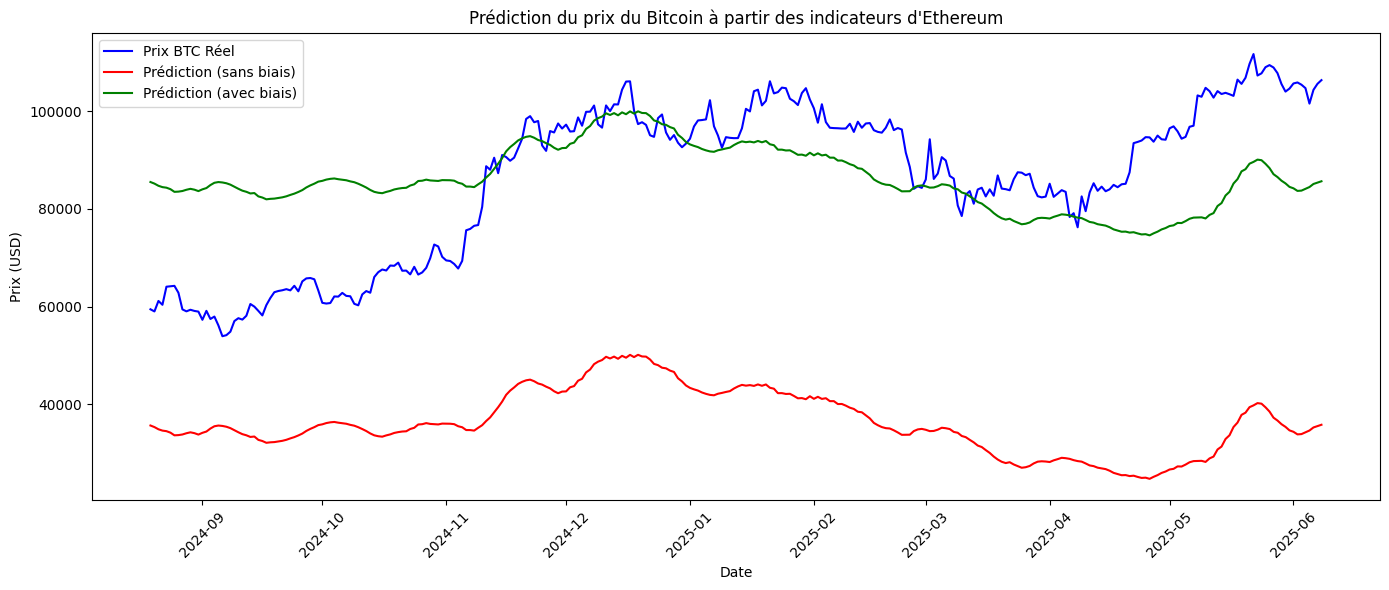

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━

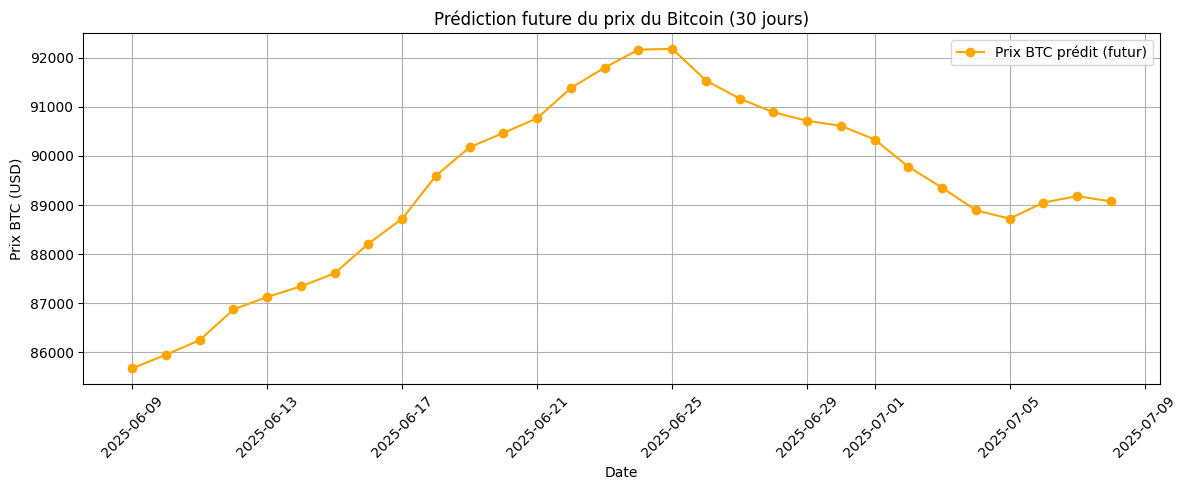

✅ Modèle RNN simple sauvegardé sous le nom 'model_rnn_simple_bitcoin_eth.h5'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Conv1D, MaxPooling1D, Flatten, Dropout
from keras.regularizers import l1_l2
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
from datetime import datetime

# =======================
# 1. Fonction pour charger les données CryptoCompare
# =======================
def load_crypto_data(symbol, comparison_symbol='USD', limit=2000):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday?fsym={symbol}&tsym={comparison_symbol}&limit={limit}'
    response = requests.get(url)
    data = response.json()['Data']['Data']
    df = pd.DataFrame(data)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    return df

# =======================
# 2. Ajout des indicateurs techniques
# =======================
def add_technical_indicators(df):
    df = df.copy()
    df['MA7'] = df['close'].rolling(window=7).mean()
    df['MA21'] = df['close'].rolling(window=21).mean()
    df['EMA'] = df['close'].ewm(span=20, adjust=False).mean()
    df['Momentum'] = df['close'] - df['close'].shift(1)
    df['Volatility'] = df['close'].rolling(window=7).std()
    return df.dropna()

# =======================
# 3. Création des séquences pour le modèle
# =======================
def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# =======================
# 4. Fonction pour prédire les prix futurs
# =======================
def predict_future_price(model, feature_scaler, target_scaler, bias, last_sequence, days_ahead=30):
    future_prices = []
    current_sequence = last_sequence.copy()

    for _ in range(days_ahead):
        input_seq = current_sequence.reshape(1, *current_sequence.shape)
        prediction_scaled = model.predict(input_seq)[0][0] + bias
        prediction = target_scaler.inverse_transform([[prediction_scaled]])[0][0]
        future_prices.append(prediction)

        # Simulation simplifiée : on copie les features précédents en décalant la dernière valeur prédite
        next_features = current_sequence[-1].copy()
        next_features[0] = prediction_scaled  # Met à jour 'close' prédite
        current_sequence = np.append(current_sequence[1:], [next_features], axis=0)

    return future_prices

# =======================
# 5. Chargement et préparation des données
# =======================
btc_data = load_crypto_data('BTC')
eth_data = load_crypto_data('ETH')

eth_data = add_technical_indicators(eth_data)
btc_data = btc_data.loc[eth_data.index]  # synchronise les index

features = eth_data[['close', 'MA7', 'MA21', 'EMA', 'Momentum', 'Volatility']]
target = btc_data['close']

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(features)
scaled_target = target_scaler.fit_transform(target.values.reshape(-1, 1))

window_size = 30
X, y = create_sequences(scaled_features, scaled_target, window_size)

# =======================
# 6. Séparation Train/Validation/Test
# =======================
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

# =======================
# 7. Construction du modèle CNN + SimpleRNN
# =======================
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(SimpleRNN(units=64, return_sequences=False, kernel_regularizer=l1_l2(0.01)))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

# =======================
# 8. Entraînement
# =======================
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val))

# =======================
# 9. Évaluation
# =======================
y_pred_scaled = model.predict(X_test)
bias = np.mean(y_test - y_pred_scaled)  # correction de biais
y_pred_scaled_bias = y_pred_scaled + bias

y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = target_scaler.inverse_transform(y_pred_scaled)
y_pred_bias_inv = target_scaler.inverse_transform(y_pred_scaled_bias)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

mae_bias = mean_absolute_error(y_test_inv, y_pred_bias_inv)
rmse_bias = np.sqrt(mean_squared_error(y_test_inv, y_pred_bias_inv))

print(f"MAE (sans biais): {mae:.2f}, RMSE: {rmse:.2f}")
print(f"MAE (avec biais): {mae_bias:.2f}, RMSE: {rmse_bias:.2f}")

# =======================
# 10. Visualisation des résultats
# =======================
dates_test = btc_data.index[-len(y_test):]

plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test_inv, label='Prix BTC Réel', color='blue')
plt.plot(dates_test, y_pred_inv, label='Prédiction (sans biais)', color='red')
plt.plot(dates_test, y_pred_bias_inv, label='Prédiction (avec biais)', color='green')
plt.title("Prédiction du prix du Bitcoin à partir des indicateurs d'Ethereum")
plt.xlabel("Date")
plt.ylabel("Prix (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# =======================
# 11. Prédiction future
# =======================
last_sequence = X[-1]  # dernière séquence connue
future_prices = predict_future_price(model, feature_scaler, target_scaler, bias, last_sequence, days_ahead=30)

future_dates = pd.date_range(start=btc_data.index[-1] + pd.Timedelta(days=1), periods=30)

plt.figure(figsize=(12, 5))
plt.plot(future_dates, future_prices, marker='o', linestyle='-', color='orange', label='Prix BTC prédit (futur)')
plt.title("Prédiction future du prix du Bitcoin (30 jours)")
plt.xlabel("Date")
plt.ylabel("Prix BTC (USD)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
model.save("model_rnn_simple_bitcoin_eth.h5")
print("✅ Modèle RNN simple sauvegardé sous le nom 'model_rnn_simple_bitcoin_eth.h5'")


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.2496 - mae: 0.1706 - val_loss: 0.3824 - val_mae: 0.4558 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1734 - mae: 0.0762 - val_loss: 0.2976 - val_mae: 0.3993 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1368 - mae: 0.0684 - val_loss: 0.2858 - val_mae: 0.4200 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1085 - mae: 0.0618 - val_loss: 0.2439 - val_mae: 0.3939 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0861 - mae: 0.0560 - val_loss: 0.1731 - val_mae: 0.3151 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0721 - mae: 0.0595 - val_loss: 0.1621 - val_mae: 0.3155 - learning_rate: 0.0010
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0602 - mae: 0.0531 - val_loss: 0.1821 - val_mae: 0.3556 - learning_rate: 0.0010
Epoch 

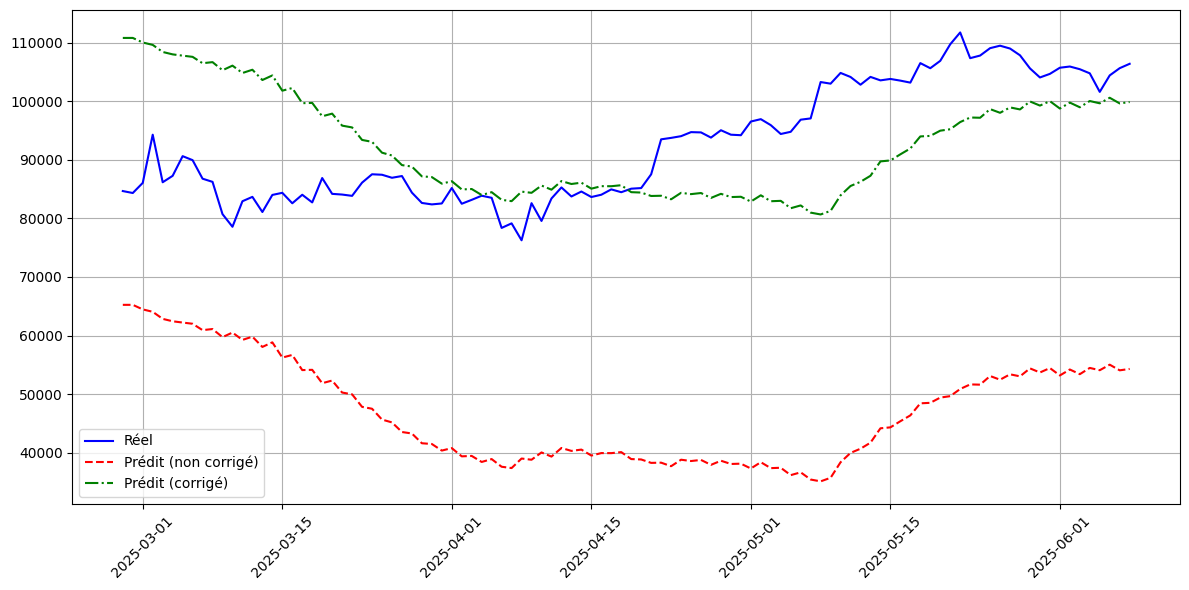

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━


Prévisions des 30 prochains jours :
Jour 1: 99848.15 USD
Jour 2: 99848.15 USD
Jour 3: 99848.15 USD
Jour 4: 99848.15 USD
Jour 5: 99848.15 USD
Jour 6: 99848.15 USD
Jour 7: 99848.15 USD
Jour 8: 99848.15 USD
Jour 9: 99848.15 USD
Jour 10: 99848.15 USD
Jour 11: 99848.15 USD
Jour 12: 99848.15 USD
Jour 13: 99848.15 USD
Jour 14: 99848.15 USD
Jour 15: 99848.15 USD
Jour 16: 99848.15 USD
Jour 17: 99848.15 USD
Jour 18: 99848.15 USD
Jour 19: 99848.15 USD
Jour 20: 99848.15 USD
Jour 21: 99848.15 USD
Jour 22: 99848.15 USD
Jour 23: 99848.15 USD
Jour 24: 99848.15 USD
Jour 25: 99848.15 USD
Jour 26: 99848.15 USD
Jour 27: 99848.15 USD
Jour 28: 99848.15 USD
Jour 29: 99848.15 USD
Jour 30: 99848.15 USD
✅ Modèle LSTM sauvegardé sous le nom 'model_lstm_bitcoin_eth.h5'


In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2

# =========================
# Récupération des données
# =========================

def collect_data_crypto_compare(symbol, start_timestamp, end_timestamp):
    url = 'https://min-api.cryptocompare.com/data/v2/histoday'
    days = (end_timestamp - start_timestamp) // (24 * 3600) + 1
    limit = min(2000, days)

    params = {
        'fsym': symbol,
        'tsym': 'USD',
        'limit': limit,
        'toTs': end_timestamp
    }

    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        if data['Response'] == 'Success':
            df = pd.DataFrame(data['Data']['Data'])
            df['time'] = pd.to_datetime(df['time'], unit='s')
            return df
        else:
            print(f"Erreur API: {data['Message']}")
            return None
    else:
        print(f"Erreur HTTP: {response.status_code}")
        return None

# =========================================
# Prétraitement des données + features ETH
# =========================================

def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                  eth_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                  on='time',
                  suffixes=('_btc', '_eth'))
    df = df.sort_values('time')

    df['eth_ma7'] = df['close_eth'].rolling(window=7).mean()
    df['eth_ma14'] = df['close_eth'].rolling(window=14).mean()
    df['eth_ma30'] = df['close_eth'].rolling(window=30).mean()
    df['eth_volatility7'] = df['close_eth'].rolling(window=7).std()
    df['eth_daily_range'] = df['high_eth'] - df['low_eth']
    df['eth_volume_price_ratio'] = df['volumeto_eth'] / df['close_eth']
    df['eth_roc5'] = df['close_eth'].pct_change(periods=5)
    df['eth_roc10'] = df['close_eth'].pct_change(periods=10)
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()
    df['eth_momentum5'] = df['close_eth'] / df['close_eth'].shift(5)
    df['eth_momentum10'] = df['close_eth'] / df['close_eth'].shift(10)

    df.dropna(inplace=True)
    return df

# =====================
# Séquences X/y
# =====================

def create_sequences(df, seq_length=30):
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]
    target = 'close_btc'
    X, y = [], []
    for i in range(len(df) - seq_length):
        feature_sequence = df[features_list].iloc[i:i+seq_length].values
        X.append(feature_sequence)
        y.append(df[target].iloc[i+seq_length])
    return np.array(X), np.array(y).reshape(-1, 1)

# ====================
# Modèle CNN-BiLSTM
# ====================

def build_simple_rnn_model(seq_length, features=12):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(seq_length, features)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))),
        Dropout(0.3),
        LSTM(128, return_sequences=False, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# ========================
# Entraînement + Analyse
# ========================

def main(bitcoin_data, ethereum_data):
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur de récupération des données.")
        return None

    data = preprocess_data(bitcoin_data, ethereum_data)

    feature_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    data[features_list] = feature_scaler.fit_transform(data[features_list])
    data['close_btc'] = btc_scaler.fit_transform(data[['close_btc']])

    seq_length = 30
    X, y = create_sequences(data, seq_length)

    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)
    X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
    y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

    model = build_simple_rnn_model(seq_length, features=len(features_list))

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00005, verbose=1)

    history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                        validation_data=(X_val, y_val),
                        callbacks=[early_stopping, reduce_lr], verbose=1)

    y_pred = model.predict(X_test)
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

    bias = np.mean(y_test_btc - y_pred_btc)
    y_pred_btc_corrected = y_pred_btc + bias

    mse_corrected = mean_squared_error(y_test_btc, y_pred_btc_corrected)
    rmse_corrected = np.sqrt(mse_corrected)
    r2_corrected = r2_score(y_test_btc, y_pred_btc_corrected)

    print(f"Après correction : MSE = {mse_corrected:.2f}, RMSE = {rmse_corrected:.2f}, R² = {r2_corrected:.4f}")

    test_dates = data['time'].iloc[-len(y_test):].values

    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_btc, label='Réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prédit (non corrigé)', color='red', linestyle='--')
    plt.plot(test_dates, y_pred_btc_corrected, label='Prédit (corrigé)', color='green', linestyle='-.')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return model, feature_scaler, btc_scaler, bias, X, data

# =======================
# Prédiction future
# =======================

def predict_future_price(model, feature_scaler, btc_scaler, bias, last_sequence, days_ahead=30):
    predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(days_ahead):
        pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], current_sequence.shape[1]))
        pred_btc = btc_scaler.inverse_transform(pred)[0][0]
        pred_btc_corrected = pred_btc + bias
        predictions.append(pred_btc_corrected)

    return predictions

# ======================
# Lancement du script
# ======================

if __name__ == "__main__":
    end_timestamp = int(time.time())
    start_timestamp = end_timestamp - (2 * 365 * 24 * 3600)

    btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
    eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

    results = main(btc_data, eth_data)

    if results:
        model, feature_scaler, btc_scaler, bias, X, data = results
        last_sequence = X[-1]
        future_predictions = predict_future_price(model, feature_scaler, btc_scaler, bias, last_sequence, days_ahead=30)

        print("\nPrévisions des 30 prochains jours :")
        for i, price in enumerate(future_predictions, 1):
            print(f"Jour {i}: {price:.2f} USD")

model.save("model_lstm_bitcoin_eth.h5")
print("✅ Modèle LSTM sauvegardé sous le nom 'model_lstm_bitcoin_eth.h5'")


🚀 Démarrage du système de prédiction Bitcoin avec optimisation automatique
📡 Récupération des données...
📊 Préparation des données...
🔍 Début de la recherche des meilleurs hyperparamètres...
Nombre total de combinaisons à tester: 16
Iteration 1: Score = 0.0148, Params = {'use_cnn': True, 'cnn_filters': 64, 'lstm_units_1': 64, 'lstm_layers': 1, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 30, 'patience': 10}
Iteration 2: Score = 0.0192, Params = {'use_cnn': True, 'cnn_filters': 64, 'lstm_units_1': 64, 'lstm_layers': 1, 'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 30, 'patience': 10}
Iteration 3: Score = 0.0147, Params = {'use_cnn': True, 'cnn_filters': 64, 'lstm_units_1': 64, 'lstm_layers': 2, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 30, 'patience': 10}
Iteration 4: Score = 0.0182, Params = {'use_cnn': True, 'cnn_filters': 64, 'lstm_units_1': 64, 'lstm_layers': 2, 'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 30, 'patience': 10}
Iteration 5: Score = 0.01

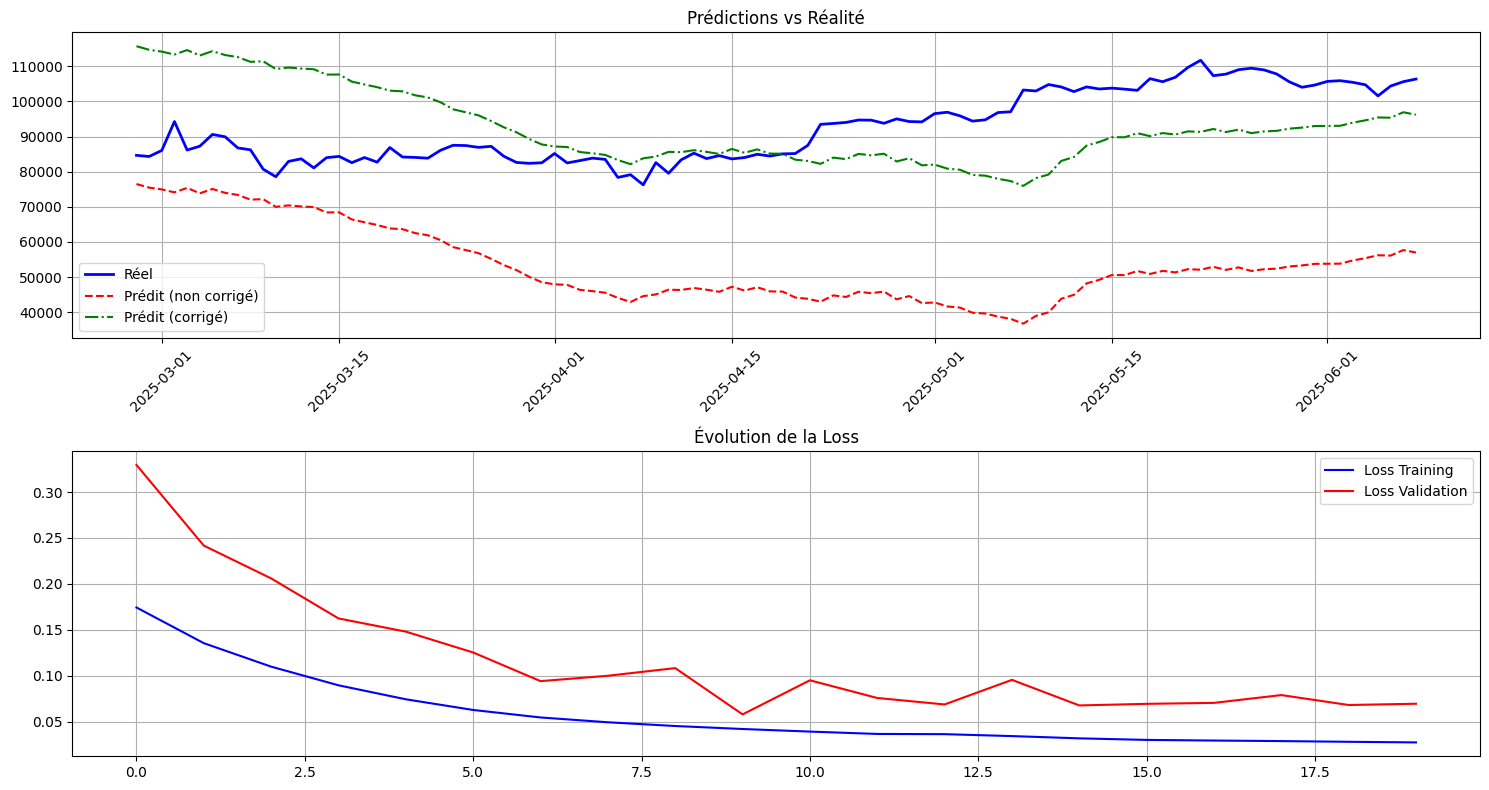


🔮 Génération des prédictions futures...



Prévisions des 30 prochains jours :
Jour 1: 96218.68 USD
Jour 2: 96218.68 USD
Jour 3: 96218.68 USD
Jour 4: 96218.68 USD
Jour 5: 96218.68 USD
Jour 6: 96218.68 USD
Jour 7: 96218.68 USD
Jour 8: 96218.68 USD
Jour 9: 96218.68 USD
Jour 10: 96218.68 USD
Jour 11: 96218.68 USD
Jour 12: 96218.68 USD
Jour 13: 96218.68 USD
Jour 14: 96218.68 USD
Jour 15: 96218.68 USD
Jour 16: 96218.68 USD
Jour 17: 96218.68 USD
Jour 18: 96218.68 USD
Jour 19: 96218.68 USD
Jour 20: 96218.68 USD
Jour 21: 96218.68 USD
Jour 22: 96218.68 USD
Jour 23: 96218.68 USD
Jour 24: 96218.68 USD
Jour 25: 96218.68 USD
Jour 26: 96218.68 USD
Jour 27: 96218.68 USD
Jour 28: 96218.68 USD
Jour 29: 96218.68 USD
Jour 30: 96218.68 USD
✅ Modèle sauvegardé sous le nom 'model_lstm_bitcoin_eth_optimized.h5'
✅ Scalers sauvegardés


In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
import itertools
import json
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

# =========================
# Récupération des données
# =========================

def collect_data_crypto_compare(symbol, start_timestamp, end_timestamp):
    url = 'https://min-api.cryptocompare.com/data/v2/histoday'
    days = (end_timestamp - start_timestamp) // (24 * 3600) + 1
    limit = min(2000, days)

    params = {
        'fsym': symbol,
        'tsym': 'USD',
        'limit': limit,
        'toTs': end_timestamp
    }

    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        if data['Response'] == 'Success':
            df = pd.DataFrame(data['Data']['Data'])
            df['time'] = pd.to_datetime(df['time'], unit='s')
            return df
        else:
            print(f"Erreur API: {data['Message']}")
            return None
    else:
        print(f"Erreur HTTP: {response.status_code}")
        return None

# =========================================
# Prétraitement des données + features ETH
# =========================================

def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                  eth_df[['time', 'close', 'high', 'low', 'volumefrom', 'volumeto']],
                  on='time',
                  suffixes=('_btc', '_eth'))
    df = df.sort_values('time')

    df['eth_ma7'] = df['close_eth'].rolling(window=7).mean()
    df['eth_ma14'] = df['close_eth'].rolling(window=14).mean()
    df['eth_ma30'] = df['close_eth'].rolling(window=30).mean()
    df['eth_volatility7'] = df['close_eth'].rolling(window=7).std()
    df['eth_daily_range'] = df['high_eth'] - df['low_eth']
    df['eth_volume_price_ratio'] = df['volumeto_eth'] / df['close_eth']
    df['eth_roc5'] = df['close_eth'].pct_change(periods=5)
    df['eth_roc10'] = df['close_eth'].pct_change(periods=10)
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()
    df['eth_momentum5'] = df['close_eth'] / df['close_eth'].shift(5)
    df['eth_momentum10'] = df['close_eth'] / df['close_eth'].shift(10)

    df.dropna(inplace=True)
    return df

# =====================
# Séquences X/y
# =====================

def create_sequences(df, seq_length=30):
    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]
    target = 'close_btc'
    X, y = [], []
    for i in range(len(df) - seq_length):
        feature_sequence = df[features_list].iloc[i:i+seq_length].values
        X.append(feature_sequence)
        y.append(df[target].iloc[i+seq_length])
    return np.array(X), np.array(y).reshape(-1, 1)

# ====================================
# OPTIMISATION DES HYPERPARAMÈTRES
# ====================================

class ModelHyperparameterOptimizer:
    def __init__(self, X, y, feature_scaler, btc_scaler):
        self.X = X
        self.y = y
        self.feature_scaler = feature_scaler
        self.btc_scaler = btc_scaler
        self.best_params = None
        self.best_score = float('inf')
        self.best_model = None
        self.results_history = []

    def build_model(self, seq_length, features, **params):
        """Construction du modèle avec les hyperparamètres donnés"""
        model = Sequential()

        # Couches CNN
        if params.get('use_cnn', True):
            model.add(Conv1D(
                filters=params.get('cnn_filters', 64),
                kernel_size=params.get('cnn_kernel_size', 3),
                activation='relu',
                padding='same',
                input_shape=(seq_length, features)
            ))
            model.add(MaxPooling1D(pool_size=params.get('pool_size', 2)))
            model.add(Dropout(params.get('cnn_dropout', 0.2)))

            if params.get('cnn_layers', 1) > 1:
                model.add(Conv1D(
                    filters=params.get('cnn_filters_2', 128),
                    kernel_size=params.get('cnn_kernel_size', 3),
                    activation='relu',
                    padding='same'
                ))
                model.add(MaxPooling1D(pool_size=params.get('pool_size', 2)))
                model.add(Dropout(params.get('cnn_dropout', 0.2)))

        # Couches LSTM
        if params.get('use_bidirectional', True):
            model.add(Bidirectional(LSTM(
                params.get('lstm_units_1', 128),
                return_sequences=params.get('lstm_layers', 1) > 1,
                kernel_regularizer=l1_l2(
                    l1=params.get('l1_reg', 1e-5),
                    l2=params.get('l2_reg', 1e-4)
                )
            )))
        else:
            model.add(LSTM(
                params.get('lstm_units_1', 128),
                return_sequences=params.get('lstm_layers', 1) > 1,
                kernel_regularizer=l1_l2(
                    l1=params.get('l1_reg', 1e-5),
                    l2=params.get('l2_reg', 1e-4)
                )
            ))

        model.add(Dropout(params.get('lstm_dropout', 0.3)))

        # Deuxième couche LSTM si nécessaire
        if params.get('lstm_layers', 1) > 1:
            model.add(LSTM(
                params.get('lstm_units_2', 128),
                return_sequences=False,
                kernel_regularizer=l1_l2(
                    l1=params.get('l1_reg', 1e-5),
                    l2=params.get('l2_reg', 1e-4)
                )
            ))
            model.add(Dropout(params.get('lstm_dropout', 0.3)))

        # Couches denses
        model.add(Dense(
            params.get('dense_units_1', 64),
            activation='relu',
            kernel_regularizer=l1_l2(
                l1=params.get('l1_reg', 1e-5),
                l2=params.get('l2_reg', 1e-4)
            )
        ))

        if params.get('dense_layers', 1) > 1:
            model.add(Dense(params.get('dense_units_2', 32), activation='relu'))

        model.add(Dense(1))

        # Compilation
        model.compile(
            optimizer=Adam(learning_rate=params.get('learning_rate', 0.001)),
            loss='mse',
            metrics=['mae']
        )

        return model

    def time_series_cv_score(self, params, n_splits=3):
        """Validation croisée adaptée aux séries temporelles"""
        tscv = TimeSeriesSplit(n_splits=n_splits)
        scores = []

        for train_idx, val_idx in tscv.split(self.X):
            X_train_cv, X_val_cv = self.X[train_idx], self.X[val_idx]
            y_train_cv, y_val_cv = self.y[train_idx], self.y[val_idx]

            # Construction du modèle
            model = self.build_model(
                seq_length=self.X.shape[1],
                features=self.X.shape[2],
                **params
            )

            # Entraînement
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=params.get('patience', 10),
                restore_best_weights=True,
                verbose=0
            )

            model.fit(
                X_train_cv, y_train_cv,
                validation_data=(X_val_cv, y_val_cv),
                epochs=params.get('epochs', 50),
                batch_size=params.get('batch_size', 32),
                callbacks=[early_stopping],
                verbose=0
            )

            # Prédiction et évaluation
            y_pred = model.predict(X_val_cv, verbose=0)
            mse = mean_squared_error(y_val_cv, y_pred)
            scores.append(mse)

        return np.mean(scores)

    def grid_search(self, param_grid, verbose=True):
        """Recherche par grille des meilleurs hyperparamètres"""
        print("🔍 Début de la recherche des meilleurs hyperparamètres...")
        print(f"Nombre total de combinaisons à tester: {len(list(itertools.product(*param_grid.values())))}")

        best_score = float('inf')
        best_params = None

        # Génération de toutes les combinaisons
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())

        for i, combination in enumerate(itertools.product(*param_values)):
            params = dict(zip(param_names, combination))

            try:
                # Évaluation avec validation croisée
                score = self.time_series_cv_score(params)

                # Stockage des résultats
                result = {
                    'params': params.copy(),
                    'score': score,
                    'iteration': i + 1
                }
                self.results_history.append(result)

                if verbose:
                    print(f"Iteration {i+1}: Score = {score:.4f}, Params = {params}")

                # Mise à jour du meilleur modèle
                if score < best_score:
                    best_score = score
                    best_params = params.copy()

            except Exception as e:
                if verbose:
                    print(f"Erreur pour les paramètres {params}: {e}")
                continue

        self.best_params = best_params
        self.best_score = best_score

        print(f"\n✅ Meilleurs paramètres trouvés:")
        print(f"Score (MSE): {best_score:.4f}")
        print(f"Paramètres: {best_params}")

        return best_params, best_score

    def train_best_model(self, X_train, y_train, X_val, y_val):
        """Entraîne le modèle avec les meilleurs paramètres trouvés"""
        if self.best_params is None:
            raise ValueError("Aucun paramètre optimal trouvé. Lancez d'abord grid_search().")

        print("\n🚀 Entraînement du modèle optimal...")

        self.best_model = self.build_model(
            seq_length=X_train.shape[1],
            features=X_train.shape[2],
            **self.best_params
        )

        # Callbacks
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=self.best_params.get('patience', 15),
            restore_best_weights=True,
            verbose=1
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001,
            verbose=1
        )

        # Entraînement
        history = self.best_model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=self.best_params.get('epochs', 100),
            batch_size=self.best_params.get('batch_size', 32),
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        return self.best_model, history

    def save_results(self, filename='hyperparameter_results.json'):
        """Sauvegarde les résultats de l'optimisation"""
        results = {
            'best_params': self.best_params,
            'best_score': self.best_score,
            'all_results': self.results_history
        }

        with open(filename, 'w') as f:
            json.dump(results, f, indent=2)

        print(f"📊 Résultats sauvegardés dans {filename}")

# ====================
# Modèle CNN-BiLSTM Original
# ====================

def build_simple_rnn_model(seq_length, features=12):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(seq_length, features)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))),
        Dropout(0.3),
        LSTM(128, return_sequences=False, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# ========================
# Entraînement + Analyse
# ========================

def main_with_optimization(bitcoin_data, ethereum_data, optimize_hyperparams=True):
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur de récupération des données.")
        return None

    print("📊 Préparation des données...")
    data = preprocess_data(bitcoin_data, ethereum_data)

    feature_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    features_list = [
        'close_eth', 'eth_ma7', 'eth_ma14', 'eth_ma30',
        'eth_volatility7', 'eth_daily_range', 'eth_volume_price_ratio',
        'eth_roc5', 'eth_roc10', 'eth_momentum5', 'eth_momentum10', 'eth_return'
    ]

    data[features_list] = feature_scaler.fit_transform(data[features_list])
    data['close_btc'] = btc_scaler.fit_transform(data[['close_btc']])

    seq_length = 30
    X, y = create_sequences(data, seq_length)

    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)
    X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
    y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

    if optimize_hyperparams:
        # Définition de l'espace de recherche
        param_grid = {
            'seq_length': [30],  # Fixé pour cette version
            'use_cnn': [True, False],
            'cnn_filters': [32, 64, 128],
            'cnn_kernel_size': [3, 5],
            'cnn_layers': [1, 2],
            'pool_size': [2],
            'cnn_dropout': [0.2, 0.3],
            'use_bidirectional': [True, False],
            'lstm_units_1': [64, 128, 256],
            'lstm_units_2': [64, 128],
            'lstm_layers': [1, 2],
            'lstm_dropout': [0.2, 0.3, 0.4],
            'dense_units_1': [32, 64, 128],
            'dense_units_2': [16, 32],
            'dense_layers': [1, 2],
            'learning_rate': [0.001, 0.0005, 0.002],
            'batch_size': [16, 32, 64],
            'epochs': [50],  # Réduit pour l'optimisation
            'patience': [10, 15],
            'l1_reg': [1e-5, 1e-4],
            'l2_reg': [1e-4, 1e-3]
        }

        # Version réduite pour test rapide
        param_grid_small = {
            'use_cnn': [True],
            'cnn_filters': [64, 128],
            'lstm_units_1': [64, 128],
            'lstm_layers': [1, 2],
            'learning_rate': [0.001, 0.0005],
            'batch_size': [32],
            'epochs': [30],
            'patience': [10]
        }

        # Optimisation des hyperparamètres
        optimizer = ModelHyperparameterOptimizer(X_train, y_train, feature_scaler, btc_scaler)

        # Utilisez param_grid_small pour un test rapide ou param_grid pour une recherche complète
        best_params, best_score = optimizer.grid_search(param_grid_small, verbose=True)

        # Entraînement du meilleur modèle
        model, history = optimizer.train_best_model(X_train, y_train, X_val, y_val)

        # Sauvegarde des résultats
        optimizer.save_results()

    else:
        # Utilisation du modèle original
        print("📈 Utilisation du modèle original sans optimisation...")
        model = build_simple_rnn_model(seq_length, features=len(features_list))

        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00005, verbose=1)

        history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                            validation_data=(X_val, y_val),
                            callbacks=[early_stopping, reduce_lr], verbose=1)

    # Évaluation sur le jeu de test
    print("\n📊 Évaluation sur le jeu de test...")
    y_pred = model.predict(X_test)
    y_test_btc = btc_scaler.inverse_transform(y_test)
    y_pred_btc = btc_scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

    # Correction du biais
    bias = np.mean(y_test_btc - y_pred_btc)
    y_pred_btc_corrected = y_pred_btc + bias

    mse_corrected = mean_squared_error(y_test_btc, y_pred_btc_corrected)
    rmse_corrected = np.sqrt(mse_corrected)
    r2_corrected = r2_score(y_test_btc, y_pred_btc_corrected)

    print(f"Après correction : MSE = {mse_corrected:.2f}, RMSE = {rmse_corrected:.2f}, R² = {r2_corrected:.4f}")

    # Visualisation
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.figure(figsize=(15, 8))
    plt.subplot(2, 1, 1)
    plt.plot(test_dates, y_test_btc, label='Réel', color='blue', linewidth=2)
    plt.plot(test_dates, y_pred_btc, label='Prédit (non corrigé)', color='red', linestyle='--')
    plt.plot(test_dates, y_pred_btc_corrected, label='Prédit (corrigé)', color='green', linestyle='-.')
    plt.legend()
    plt.title('Prédictions vs Réalité')
    plt.grid(True)
    plt.xticks(rotation=45)

    # Graphique de l'historique d'entraînement si disponible
    if 'history' in locals():
        plt.subplot(2, 1, 2)
        plt.plot(history.history['loss'], label='Loss Training', color='blue')
        plt.plot(history.history['val_loss'], label='Loss Validation', color='red')
        plt.legend()
        plt.title('Évolution de la Loss')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model, feature_scaler, btc_scaler, bias, X, data

# =======================
# Prédiction future
# =======================

def predict_future_price(model, feature_scaler, btc_scaler, bias, last_sequence, days_ahead=30):
    predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(days_ahead):
        pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], current_sequence.shape[1]), verbose=0)
        pred_btc = btc_scaler.inverse_transform(pred)[0][0]
        pred_btc_corrected = pred_btc + bias
        predictions.append(pred_btc_corrected)

    return predictions

def main(bitcoin_data, ethereum_data):
    """Fonction main originale pour compatibilité"""
    return main_with_optimization(bitcoin_data, ethereum_data, optimize_hyperparams=False)

# ======================
# Lancement du script
# ======================

if __name__ == "__main__":
    print("🚀 Démarrage du système de prédiction Bitcoin avec optimisation automatique")

    end_timestamp = int(time.time())
    start_timestamp = end_timestamp - (2 * 365 * 24 * 3600)

    print("📡 Récupération des données...")
    btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
    eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

    # Choix: optimiser les hyperparamètres ou utiliser le modèle original
    OPTIMIZE_HYPERPARAMS = True  # Changez à False pour utiliser le modèle original

    results = main_with_optimization(btc_data, eth_data, optimize_hyperparams=OPTIMIZE_HYPERPARAMS)

    if results:
        model, feature_scaler, btc_scaler, bias, X, data = results
        last_sequence = X[-1]

        print("\n🔮 Génération des prédictions futures...")
        future_predictions = predict_future_price(model, feature_scaler, btc_scaler, bias, last_sequence, days_ahead=30)

        print("\nPrévisions des 30 prochains jours :")
        for i, price in enumerate(future_predictions, 1):
            print(f"Jour {i}: {price:.2f} USD")

        # Sauvegarde du modèle
        model_filename = "model_lstm_bitcoin_eth_optimized.h5" if OPTIMIZE_HYPERPARAMS else "model_lstm_bitcoin_eth.h5"
        model.save(model_filename)
        print(f"✅ Modèle sauvegardé sous le nom '{model_filename}'")

        # Sauvegarde des scalers
        import joblib
        joblib.dump(feature_scaler, 'feature_scaler.pkl')
        joblib.dump(btc_scaler, 'btc_scaler.pkl')
        print("✅ Scalers sauvegardés")

Téléchargement des données BTC et ETH...
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0927 - mae: 0.2280 - val_loss: 0.0021 - val_mae: 0.0418
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0059 - mae: 0.0617 - val_loss: 0.0012 - val_mae: 0.0310
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0048 - mae: 0.0562 - val_loss: 0.0077 - val_mae: 0.0857
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0061 - mae: 0.0622 - val_loss: 0.0064 - val_mae: 0.0775
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0044 - mae: 0.0522 - val_loss: 0.0052 - val_mae: 0.0684
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0047 - mae: 0.0538 - val_loss: 0.0019 - val_mae: 0.0380
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0042 - mae: 0.0505 - val_loss: 0.0011 - val_mae: 0.0274
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0043 - mae: 0.0505 - val_loss: 0.0056 - val_mae: 0.0691
Epoch 9/100
72/

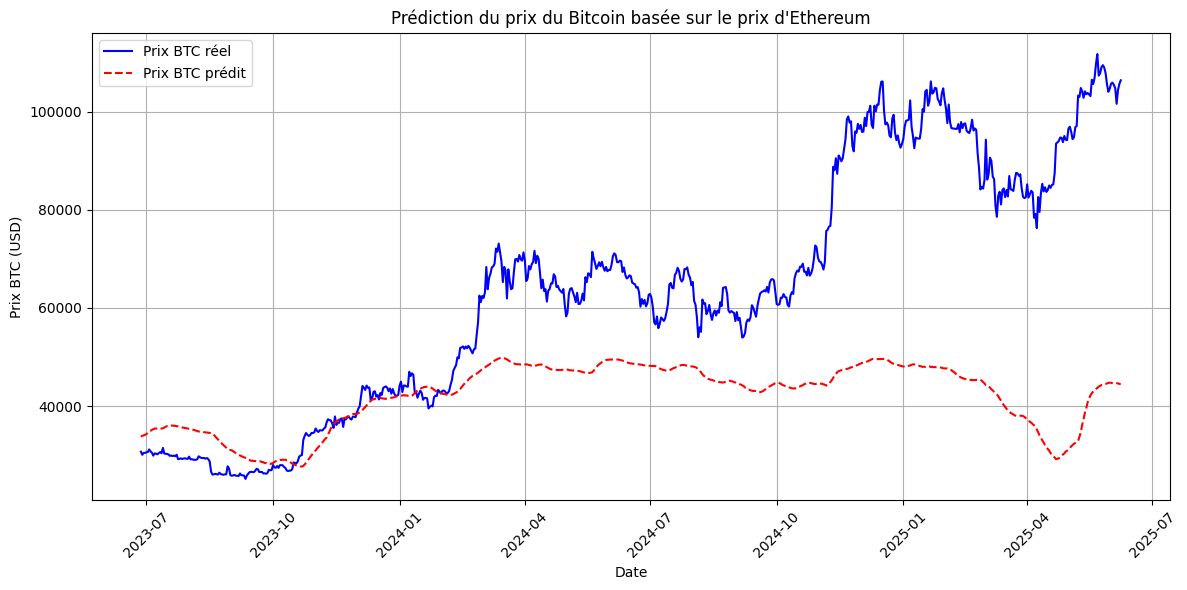

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, SimpleRNN, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ===================== Données depuis CryptoCompare ======================
def collect_data_crypto_compare(symbol, start_timestamp, end_timestamp):
    url = f"https://min-api.cryptocompare.com/data/v2/histoday"
    limit = 2000  # max par requête
    all_data = []

    while start_timestamp < end_timestamp:
        params = {
            'fsym': symbol,
            'tsym': 'USD',
            'limit': limit,
            'toTs': end_timestamp
        }

        response = requests.get(url, params=params)
        data = response.json()
        if data['Response'] != 'Success':
            print(f"Erreur de récupération pour {symbol}")
            return None

        histo = data['Data']['Data']
        all_data = histo + all_data  # prepend

        end_timestamp = histo[0]['time'] - 1  # passer à l'intervalle précédent

        if histo[0]['time'] <= start_timestamp:
            break

        time.sleep(1)

    df = pd.DataFrame(all_data)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    return df

# ===================== Prétraitement ======================
def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))
    df = df.sort_values('time')
    df['btc_return'] = df['close_btc'].pct_change()
    df['eth_return'] = df['close_eth'].pct_change()
    df.dropna(inplace=True)
    return df

def create_sequences(eth_prices, btc_prices, seq_length=30):
    X, y = [], []
    for i in range(len(eth_prices) - seq_length):
        X.append(eth_prices[i:i+seq_length])
        y.append(btc_prices[i+seq_length])
    return np.array(X), np.array(y)

# ===================== Architecture Améliorée ======================
def build_complex_model(seq_length, features=1):
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(seq_length, features)),
        MaxPooling1D(pool_size=2),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# ===================== Pipeline Principal ======================
def main(bitcoin_data, ethereum_data):
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : données manquantes.")
        return None

    data = preprocess_data(bitcoin_data, ethereum_data)

    # Ajout du log transform pour BTC
    data['log_btc'] = np.log(data['close_btc'])

    eth_scaler = MinMaxScaler()
    btc_scaler = MinMaxScaler()

    eth_scaled = eth_scaler.fit_transform(data[['close_eth']])
    btc_scaled = btc_scaler.fit_transform(data[['log_btc']])

    seq_length = 30
    X, y = create_sequences(eth_scaled, btc_scaled, seq_length)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    model = build_complex_model(seq_length)

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    y_pred = model.predict(X_test)

    # Inverser la normalisation et transformation log
    y_test_btc = np.exp(btc_scaler.inverse_transform(y_test))
    y_pred_btc = np.exp(btc_scaler.inverse_transform(y_pred))

    # Évaluation
    mse = mean_squared_error(y_test_btc, y_pred_btc)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_btc, y_pred_btc)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Visualisation
    plt.figure(figsize=(12, 6))
    test_dates = data['time'].iloc[-len(y_test):].values

    plt.plot(test_dates, y_test_btc, label='Prix BTC réel', color='blue')
    plt.plot(test_dates, y_pred_btc, label='Prix BTC prédit', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction du prix du Bitcoin basée sur le prix d\'Ethereum')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return model, eth_scaler, btc_scaler

# ===================== Exécution ======================
if __name__ == "__main__":
    start_timestamp = int(datetime(2017, 1, 1).timestamp())
    end_timestamp = int(datetime.now().timestamp())

    print("Téléchargement des données BTC et ETH...")
    btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
    eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

    model, eth_scaler, btc_scaler = main(btc_data, eth_data)


### Automatisation des paramètres

Téléchargement des données BTC et ETH...
Feature engineering avancé...


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Utilisation de 66 features
Shape des données: X=(3474, 90, 66), y=(3474,)
Construction du modèle ultra-complexe...
Paramètres du modèle: 6,638,913
Entraînement du modèle...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.0828 - mae: 0.8414 - mse: 1.2687
Epoch 1: val_loss improved from inf to 0.88712, saving model to best_crypto_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - loss: 1.0816 - mae: 0.8399 - mse: 1.2650 - val_loss: 0.8871 - val_mae: 0.6570 - val_mse: 0.6150
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.7139 - mae: 0.3671 - mse: 0.2238
Epoch 2: val_loss improved from 0.88712 to 0.65256, saving model to best_crypto_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - loss: 0.7138 - mae: 0.3669 - mse: 0.2236 - val_loss: 0.6526 - val_mae: 0.1988 - val_mse: 0.1076
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.6563 - mae: 0.2687 - mse: 0.1200
Epoch 3: val_loss improved from 0.65256 to 0.60161, saving model to best_crypto_model.h5


...

152/152 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - loss: 0.5881 - mae: 0.1686 - mse: 0.0493 - val_loss: 0.5565 - val_mae: 0.0754 - val_mse: 0.0068
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.5703 - mae: 0.1540 - mse: 0.0417
Epoch 7: val_loss improved from 0.55652 to 0.54086, saving model to best_crypto_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - loss: 0.5703 - mae: 0.1540 - mse: 0.0417 - val_loss: 0.5409 - val_mae: 0.0585 - val_mse: 0.0049
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.5494 - mae: 0.1332 - mse: 0.0296
Epoch 8: val_loss improved from 0.54086 to 0.52574, saving model to best_crypto_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - loss: 0.5494 - mae: 0.1332 - mse: 0.0296 - val_loss: 0.5257 - val_mae: 0.0619 - val_mse: 0.0058
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.5324 - mae: 0.1288 - mse: 0.0272
Epoch 9: val_loss improved from 0.52574 to 0.50935, saving model to best_crypto_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - loss: 0.5324 - mae: 0.1287 - mse: 0.0272 - val_loss: 0.5094 - val_mae: 0.0685 - val_mse: 0.0063
Epoch 10/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.5125 - mae: 0.1133 - mse: 0.0214
Epoch 10: val_loss improved from 0.50935 to 0.49365, saving model to best_crypto_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - loss: 0.5125 - mae: 0.1133 - mse: 0.0214 - val_loss: 0.4936 - val_mae: 0.0906 - val_mse: 0.0103
Restoring model weights from the end of the best epoch: 10.
Génération des prédictions...
76/76 ━━━━━━━━━━━━━━━━━━━━ 51s 582ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 484ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 405ms/step

=== Métriques ENTRAÎNEMENT ===
MSE: 103,638,272.05
RMSE: 10,180.29
MAE: 5,889.99
R²: 0.643507
MAPE: 36.27%

=== Métriques VALIDATION ===
MSE: 870,142,678.40
RMSE: 29,498.18
MAE: 23,000.06
R²: -17.639788
MAPE: 82.74%

=== Métriques TEST ===
MSE: 1,101,246,779.40
RMSE: 33,185.04
MAE: 25,019.20
R²: -2.206720
MAPE: 38.07%


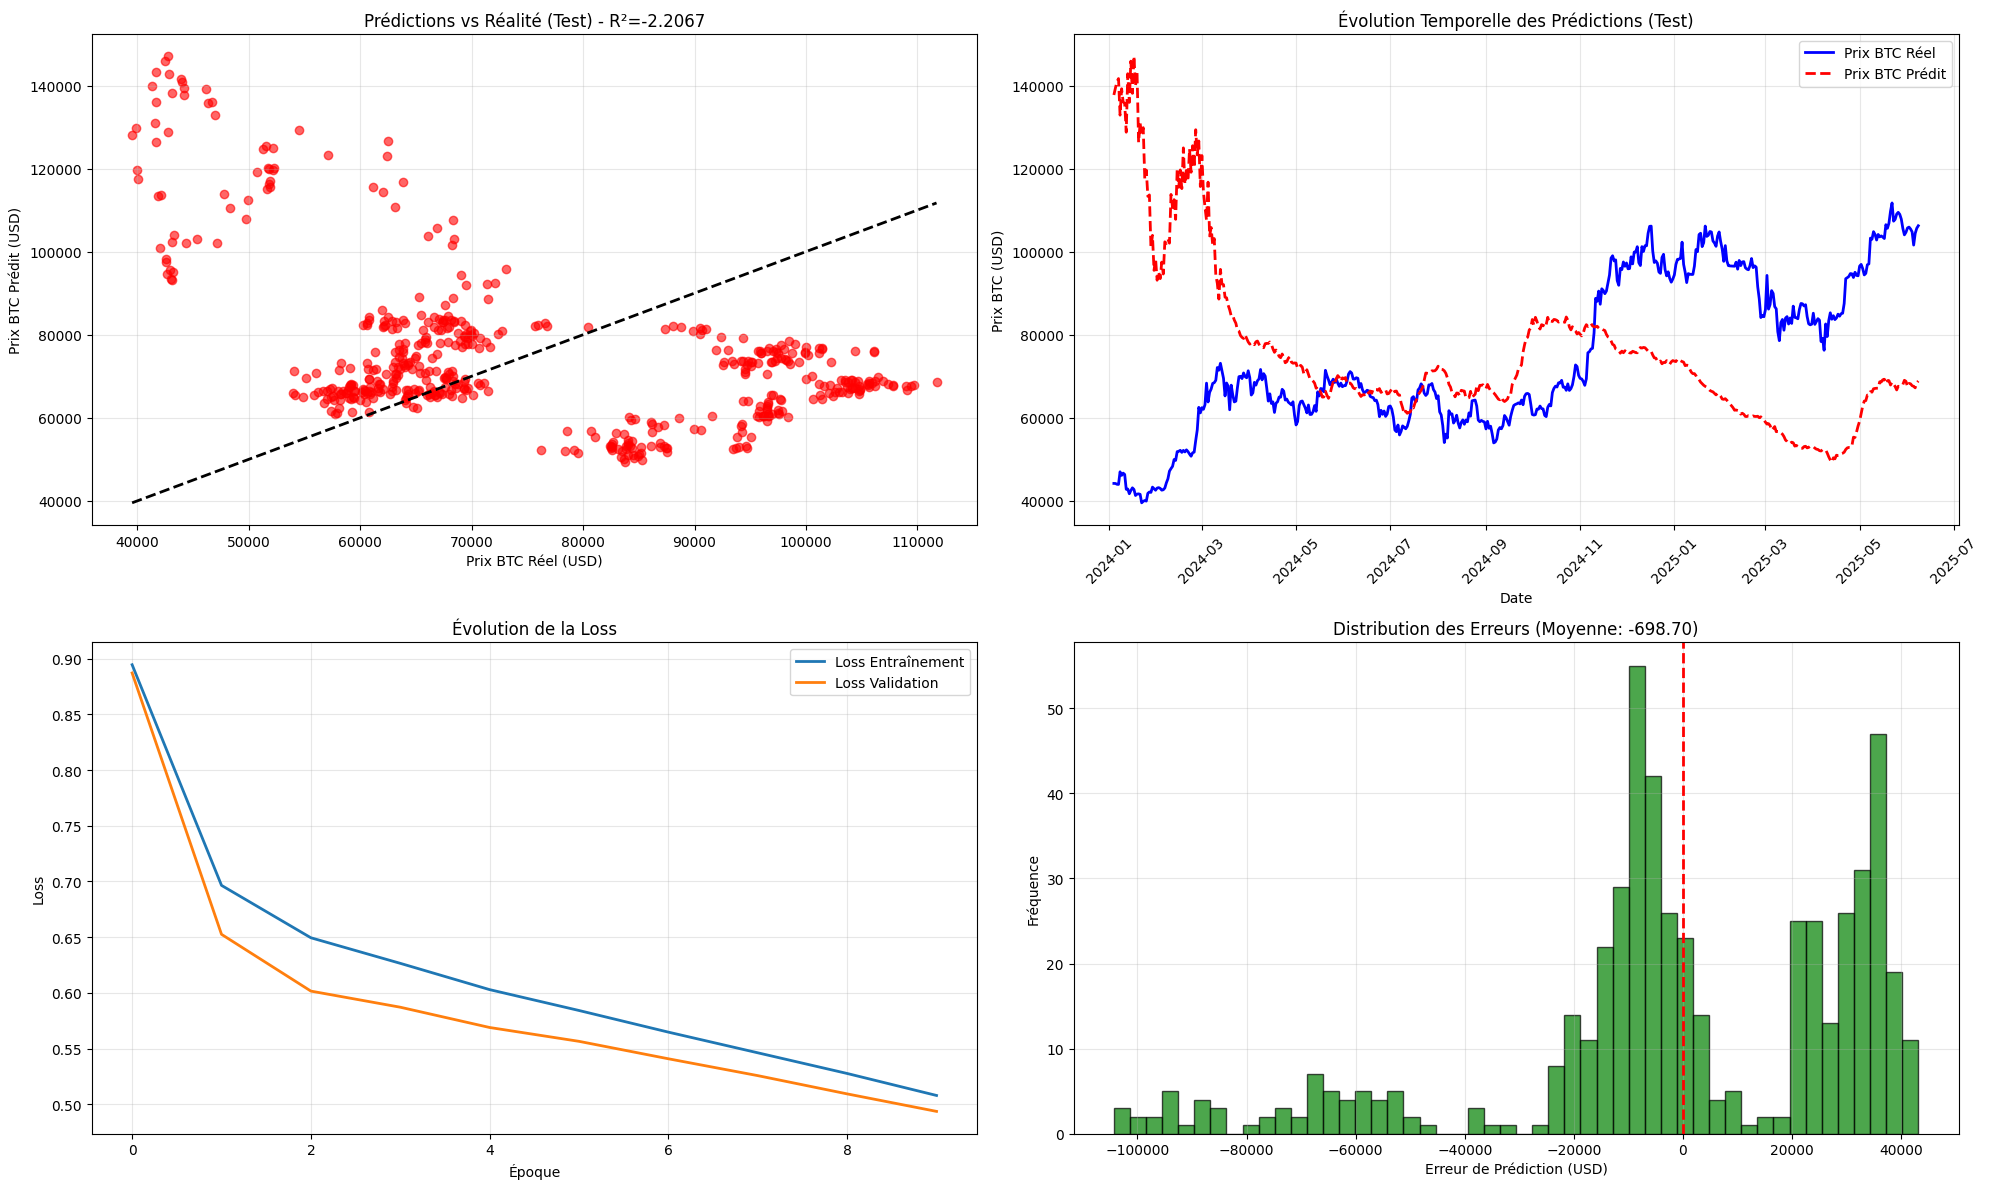

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, AveragePooling1D, GlobalMaxPooling1D,
                                   Bidirectional, LSTM, GRU, SimpleRNN, Dropout, Dense,
                                   BatchNormalization, LayerNormalization,
                                   MultiHeadAttention, Add, Concatenate, Input,
                                   SeparableConv1D, TimeDistributed, RepeatVector, Permute, Reshape,
                                   SpatialDropout1D, AlphaDropout, GaussianDropout)
from tensorflow.keras.optimizers import Adam, RMSprop, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.activations import swish
import tensorflow.keras.backend as K
import tensorflow as tf

# ===================== Données depuis CryptoCompare ======================
def collect_data_crypto_compare(symbol, start_timestamp, end_timestamp):
    url = f"https://min-api.cryptocompare.com/data/v2/histoday"
    limit = 2000  # max par requête
    all_data = []

    while start_timestamp < end_timestamp:
        params = {
            'fsym': symbol,
            'tsym': 'USD',
            'limit': limit,
            'toTs': end_timestamp
        }

        response = requests.get(url, params=params)
        data = response.json()
        if data['Response'] != 'Success':
            print(f"Erreur de récupération pour {symbol}")
            return None

        histo = data['Data']['Data']
        all_data = histo + all_data  # prepend

        end_timestamp = histo[0]['time'] - 1  # passer à l'intervalle précédent

        if histo[0]['time'] <= start_timestamp:
            break

        time.sleep(1)

    df = pd.DataFrame(all_data)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    return df

# ===================== Prétraitement Avancé ======================
def advanced_feature_engineering(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close', 'high', 'low', 'open', 'volumeto']],
                  eth_df[['time', 'close', 'high', 'low', 'open', 'volumeto']],
                  on='time', suffixes=('_btc', '_eth'))
    df = df.sort_values('time')

    # Features techniques avancées pour BTC et ETH
    for suffix in ['_btc', '_eth']:
        close_col = f'close{suffix}'
        high_col = f'high{suffix}'
        low_col = f'low{suffix}'
        open_col = f'open{suffix}'
        vol_col = f'volumeto{suffix}'

        # Returns multiples
        df[f'return{suffix}'] = df[close_col].pct_change()
        df[f'log_return{suffix}'] = np.log(df[close_col]).diff()
        df[f'return_2d{suffix}'] = df[close_col].pct_change(2)
        df[f'return_7d{suffix}'] = df[close_col].pct_change(7)

        # Volatilité
        df[f'volatility{suffix}'] = df[f'return{suffix}'].rolling(30).std()
        df[f'hl_ratio{suffix}'] = (df[high_col] - df[low_col]) / df[close_col]

        # Moyennes mobiles
        for window in [5, 10, 20, 50, 100]:
            df[f'ma_{window}{suffix}'] = df[close_col].rolling(window).mean()
            df[f'price_ma_ratio_{window}{suffix}'] = df[close_col] / df[f'ma_{window}{suffix}']

        # RSI
        delta = df[close_col].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df[f'rsi{suffix}'] = 100 - (100 / (1 + rs))

        # MACD
        ema_12 = df[close_col].ewm(span=12).mean()
        ema_26 = df[close_col].ewm(span=26).mean()
        df[f'macd{suffix}'] = ema_12 - ema_26
        df[f'macd_signal{suffix}'] = df[f'macd{suffix}'].ewm(span=9).mean()

        # Bollinger Bands
        bb_ma = df[close_col].rolling(20).mean()
        bb_std = df[close_col].rolling(20).std()
        df[f'bb_upper{suffix}'] = bb_ma + (bb_std * 2)
        df[f'bb_lower{suffix}'] = bb_ma - (bb_std * 2)
        df[f'bb_position{suffix}'] = (df[close_col] - df[f'bb_lower{suffix}']) / (df[f'bb_upper{suffix}'] - df[f'bb_lower{suffix}'])

        # Volume indicators
        df[f'vol_ma{suffix}'] = df[vol_col].rolling(30).mean()
        df[f'vol_ratio{suffix}'] = df[vol_col] / df[f'vol_ma{suffix}']

    # Cross-asset features
    df['btc_eth_ratio'] = df['close_btc'] / df['close_eth']
    df['btc_eth_corr'] = df['return_btc'].rolling(30).corr(df['return_eth'])
    df['vol_ratio_cross'] = df['volatility_btc'] / df['volatility_eth']

    # Cyclical time features
    df['day_of_year'] = df['time'].dt.dayofyear
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
    df['month'] = df['time'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df.dropna(inplace=True)
    return df

def create_multi_feature_sequences(data, target_col, feature_cols, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[feature_cols].iloc[i:i+seq_length].values)
        y.append(data[target_col].iloc[i+seq_length])
    return np.array(X), np.array(y)

# ===================== Couche d'Attention Personnalisée ======================
class MultiScaleAttention(tf.keras.layers.Layer):
    def __init__(self, units, num_heads=8):
        super(MultiScaleAttention, self).__init__()
        self.units = units
        self.num_heads = num_heads
        self.attention_1 = MultiHeadAttention(num_heads=num_heads, key_dim=units//num_heads)
        self.attention_2 = MultiHeadAttention(num_heads=num_heads//2, key_dim=units//(num_heads//2))
        self.dense = Dense(units)
        self.norm = LayerNormalization()

    def call(self, inputs):
        attn_1 = self.attention_1(inputs, inputs)
        attn_2 = self.attention_2(inputs, inputs)
        combined = Concatenate()([attn_1, attn_2])
        output = self.dense(combined)
        return self.norm(output + inputs)

# ===================== Architecture Ultra-Complexe ======================
def build_ultra_complex_model(seq_length, n_features):
    inputs = Input(shape=(seq_length, n_features))

    # Branche CNN Multi-échelle
    conv_branch_1 = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    conv_branch_1 = BatchNormalization()(conv_branch_1)
    conv_branch_1 = SpatialDropout1D(0.1)(conv_branch_1)

    conv_branch_2 = Conv1D(64, 5, activation='relu', padding='same')(inputs)
    conv_branch_2 = BatchNormalization()(conv_branch_2)
    conv_branch_2 = SpatialDropout1D(0.1)(conv_branch_2)

    conv_branch_3 = Conv1D(64, 7, activation='relu', padding='same')(inputs)
    conv_branch_3 = BatchNormalization()(conv_branch_3)
    conv_branch_3 = SpatialDropout1D(0.1)(conv_branch_3)

    # Fusion des branches CNN
    conv_merged = Concatenate()([conv_branch_1, conv_branch_2, conv_branch_3])
    conv_merged = Conv1D(128, 1, activation='relu')(conv_merged)
    conv_merged = BatchNormalization()(conv_merged)
    conv_merged = MaxPooling1D(2)(conv_merged)
    conv_merged = Dropout(0.2)(conv_merged)

    # Bloc CNN profond
    x = Conv1D(256, 3, activation='relu', padding='same', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(conv_merged)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(256, 3, activation='relu', padding='same', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(x)
    x = BatchNormalization()(x)
    x = Add()([x, Conv1D(256, 1)(conv_merged)])  # Connexion résiduelle
    x = MaxPooling1D(2)(x)
    x = Dropout(0.15)(x)

    # Branche LSTM Bidirectionnelle Multi-couches
    lstm_branch = Bidirectional(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x)
    lstm_branch = LayerNormalization()(lstm_branch)
    lstm_branch = Bidirectional(LSTM(192, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(lstm_branch)
    lstm_branch = LayerNormalization()(lstm_branch)
    lstm_branch = Bidirectional(LSTM(128, return_sequences=True, dropout=0.15, recurrent_dropout=0.15))(lstm_branch)

    # Branche GRU
    gru_branch = Bidirectional(GRU(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x)
    gru_branch = LayerNormalization()(gru_branch)
    gru_branch = Bidirectional(GRU(192, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(gru_branch)
    gru_branch = LayerNormalization()(gru_branch)

    # Fusion RNN
    rnn_merged = Concatenate()([lstm_branch, gru_branch])
    rnn_merged = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(rnn_merged)
    rnn_merged = LayerNormalization()(rnn_merged)
    rnn_merged = Dropout(0.2)(rnn_merged)

    # Attention Multi-échelle
    attention_out = MultiScaleAttention(256, num_heads=16)(rnn_merged)
    attention_out = Dropout(0.2)(attention_out)

    # Attention temporelle globale
    global_attention = MultiHeadAttention(num_heads=8, key_dim=32)(attention_out, attention_out)
    global_attention = LayerNormalization()(global_attention)
    global_attention = Add()([attention_out, global_attention])

    # Pooling multiple
    max_pool = GlobalMaxPooling1D()(global_attention)
    avg_pool = tf.keras.layers.GlobalAveragePooling1D()(global_attention)
    last_step = global_attention[:, -1, :]

    # Fusion finale
    merged_features = Concatenate()([max_pool, avg_pool, last_step])

    # Réseau dense profond avec connexions résiduelles
    dense_1 = Dense(512, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(merged_features)
    dense_1 = BatchNormalization()(dense_1)
    dense_1 = Dropout(0.3)(dense_1)

    dense_2 = Dense(384, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(dense_1)
    dense_2 = BatchNormalization()(dense_2)
    dense_2 = Dropout(0.25)(dense_2)

    dense_3 = Dense(256, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(dense_2)
    dense_3 = BatchNormalization()(dense_3)
    dense_3 = Add()([dense_3, Dense(256)(dense_1)])  # Connexion résiduelle
    dense_3 = Dropout(0.2)(dense_3)

    dense_4 = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(dense_3)
    dense_4 = BatchNormalization()(dense_4)
    dense_4 = Dropout(0.15)(dense_4)

    dense_5 = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(dense_4)
    dense_5 = BatchNormalization()(dense_5)
    dense_5 = Dropout(0.1)(dense_5)

    # Sortie finale
    output = Dense(1, kernel_regularizer=l2(1e-5))(dense_5)

    model = Model(inputs=inputs, outputs=output)

    # Optimiseur avancé avec schedule
    initial_learning_rate = 0.001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate,
        decay_steps=1000,
        decay_rate=0.96,
        staircase=True)

    optimizer = Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='huber',
        metrics=['mae', 'mse']
    )

    return model

# ===================== Pipeline Principal Ultra-Avancé ======================
def main_ultra_complex(bitcoin_data, ethereum_data):
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : données manquantes.")
        return None

    print("Feature engineering avancé...")
    data = advanced_feature_engineering(bitcoin_data, ethereum_data)

    # Sélection des features
    feature_cols = [col for col in data.columns if col not in ['time', 'close_btc']]
    target_col = 'close_btc'

    print(f"Utilisation de {len(feature_cols)} features")

    # Normalisation avancée
    feature_scaler = StandardScaler()
    target_scaler = MinMaxScaler()

    # Log transform pour le target
    data['log_target'] = np.log(data[target_col])

    features_scaled = feature_scaler.fit_transform(data[feature_cols])
    target_scaled = target_scaler.fit_transform(data[['log_target']])

    # Création des DataFrames normalisés
    features_df = pd.DataFrame(features_scaled, columns=feature_cols, index=data.index)
    target_series = pd.Series(target_scaled.flatten(), index=data.index, name='log_target')

    # Combiner features et target
    combined_data = pd.concat([features_df, target_series], axis=1)

    seq_length = 90  # Séquences plus longues
    X, y = create_multi_feature_sequences(
        combined_data,
        'log_target',
        feature_cols,
        seq_length
    )

    print(f"Shape des données: X={X.shape}, y={y.shape}")

    # Division train/validation/test
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)

    X_train = X[:train_size]
    X_val = X[train_size:train_size+val_size]
    X_test = X[train_size+val_size:]

    y_train = y[:train_size]
    y_val = y[train_size:train_size+val_size]
    y_test = y[train_size+val_size:]

    print("Construction du modèle ultra-complexe...")
    model = build_ultra_complex_model(seq_length, len(feature_cols))

    print(f"Paramètres du modèle: {model.count_params():,}")

    # Callbacks avancés
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        ModelCheckpoint('best_crypto_model.h5', save_best_only=True, monitor='val_loss', verbose=1)
    ]

    print("Entraînement du modèle...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=16,
        callbacks=callbacks,
        verbose=1
    )

    # Prédictions
    print("Génération des prédictions...")
    y_pred_train = model.predict(X_train, batch_size=32)
    y_pred_val = model.predict(X_val, batch_size=32)
    y_pred_test = model.predict(X_test, batch_size=32)

    # Inverse transform
    y_train_orig = np.exp(target_scaler.inverse_transform(y_train.reshape(-1, 1))).flatten()
    y_val_orig = np.exp(target_scaler.inverse_transform(y_val.reshape(-1, 1))).flatten()
    y_test_orig = np.exp(target_scaler.inverse_transform(y_test.reshape(-1, 1))).flatten()

    y_pred_train_orig = np.exp(target_scaler.inverse_transform(y_pred_train)).flatten()
    y_pred_val_orig = np.exp(target_scaler.inverse_transform(y_pred_val)).flatten()
    y_pred_test_orig = np.exp(target_scaler.inverse_transform(y_pred_test)).flatten()

    # Métriques détaillées
    def calculate_metrics(y_true, y_pred, set_name):
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        print(f"\n=== Métriques {set_name} ===")
        print(f"MSE: {mse:,.2f}")
        print(f"RMSE: {rmse:,.2f}")
        print(f"MAE: {mae:,.2f}")
        print(f"R²: {r2:.6f}")
        print(f"MAPE: {mape:.2f}%")

        return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

    train_metrics = calculate_metrics(y_train_orig, y_pred_train_orig, "ENTRAÎNEMENT")
    val_metrics = calculate_metrics(y_val_orig, y_pred_val_orig, "VALIDATION")
    test_metrics = calculate_metrics(y_test_orig, y_pred_test_orig, "TEST")

    # Visualisations avancées
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    # Prédictions vs Réalité (Test)
    axes[0,0].scatter(y_test_orig, y_pred_test_orig, alpha=0.6, color='red')
    axes[0,0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'k--', lw=2)
    axes[0,0].set_xlabel('Prix BTC Réel (USD)')
    axes[0,0].set_ylabel('Prix BTC Prédit (USD)')
    axes[0,0].set_title(f'Prédictions vs Réalité (Test) - R²={test_metrics["r2"]:.4f}')
    axes[0,0].grid(True, alpha=0.3)

    # Évolution temporelle (dernier segment)
    test_dates = data['time'].iloc[-len(y_test):].values
    axes[0,1].plot(test_dates, y_test_orig, label='Prix BTC Réel', linewidth=2, color='blue')
    axes[0,1].plot(test_dates, y_pred_test_orig, label='Prix BTC Prédit', linewidth=2, color='red', linestyle='--')
    axes[0,1].set_xlabel('Date')
    axes[0,1].set_ylabel('Prix BTC (USD)')
    axes[0,1].set_title('Évolution Temporelle des Prédictions (Test)')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].tick_params(axis='x', rotation=45)

    # Historique d'entraînement
    axes[1,0].plot(history.history['loss'], label='Loss Entraînement', linewidth=2)
    axes[1,0].plot(history.history['val_loss'], label='Loss Validation', linewidth=2)
    axes[1,0].set_xlabel('Époque')
    axes[1,0].set_ylabel('Loss')
    axes[1,0].set_title('Évolution de la Loss')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # Distribution des erreurs
    errors = y_test_orig - y_pred_test_orig
    axes[1,1].hist(errors, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1,1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1,1].set_xlabel('Erreur de Prédiction (USD)')
    axes[1,1].set_ylabel('Fréquence')
    axes[1,1].set_title(f'Distribution des Erreurs (Moyenne: {np.mean(errors):.2f})')
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return model, feature_scaler, target_scaler, feature_cols

# ===================== Exécution ======================
if __name__ == "__main__":
    start_timestamp = int(datetime(2017, 1, 1).timestamp())
    end_timestamp = int(datetime.now().timestamp())

    print("Téléchargement des données BTC et ETH...")
    btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
    eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

    model, feature_scaler, target_scaler, feature_cols = main_ultra_complex(btc_data, eth_data)


Récupération des données Bitcoin...
Récupération des données Ethereum...
Données récupérées: BTC=2001 jours, ETH=2001 jours
Prétraitement des données avec indicateurs techniques...
Utilisation de 48 features
Shape des données: X=(1862, 90, 48), y=(1862,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Entraînement du modèle 1/3...
Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 126.3370 - mae: 2.2688 - mse: 6.9665
Epoch 1: val_loss improved from inf to 110.56255, saving model to best_model.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - loss: 126.1442 - mae: 2.2622 - mse: 6.9311 - val_loss: 110.5626 - val_mae: 0.0813 - val_mse: 0.0110 - learning_rate: 5.0000e-04
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 107.4717 - mae: 1.6104 - mse: 3.8067
Epoch 2: val_loss improved from 110.56255 to 93.08434, saving model to best_model.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - loss: 107.2887 - mae: 1.6067 - mse: 3.7925 - val_loss: 93.0843 - val_mae: 0.3397 - val_mse: 0.1252 - learning_rate: 5.0000e-04
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 89.8976 - mae: 1.1901 - mse: 2.2913
Epoch 3: val_loss improved from 93.08434 to 77.24793, saving model to best_model.h5


...

21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 864ms/step - loss: 0.0216 - mae: 0.1543 - mse: 0.0432 - val_loss: 0.0104 - val_mae: 0.1255 - val_mse: 0.0208 - learning_rate: 0.0010
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - loss: 0.0019 - mae: 0.0469 - mse: 0.0038
Epoch 2: val_loss improved from 0.01041 to 0.00943, saving model to best_model.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 853ms/step - loss: 0.0019 - mae: 0.0467 - mse: 0.0037 - val_loss: 0.0094 - val_mae: 0.1201 - val_mse: 0.0189 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - loss: 9.8777e-04 - mae: 0.0353 - mse: 0.0020
Epoch 3: val_loss improved from 0.00943 to 0.00761, saving model to best_model.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 847ms/step - loss: 9.8822e-04 - mae: 0.0353 - mse: 0.0020 - val_loss: 0.0076 - val_mae: 0.1069 - val_mse: 0.0152 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - loss: 8.3751e-04 - mae: 0.0311 - mse: 0.0017
Epoch 4: val_loss did not improve from 0.00761
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 840ms/step - loss: 8.3920e-04 - mae: 0.0311 - mse: 0.0017 - val_loss: 0.0086 - val_mae: 0.1145 - val_mse: 0.0173 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - loss: 7.1244e-04 - mae: 0.0289 - mse: 0.0014
Epoch 5: val_loss did not improve from 0.00761
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 841ms/step - loss: 7.0861e-04 - mae: 0.0289 - mse: 0.0014 - val_loss: 0.0085 - val_mae: 0.1155 - val_mse: 0.0170 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - loss: 6.7571e-04 - mae: 0.0278 - mse: 0.0014
Epoch 6: val_loss did not improve from 0.00761
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 904ms/step - loss: 6.726

21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 657ms/step - loss: 0.0042 - mae: 0.0717 - mse: 0.0083 - val_loss: 0.0059 - val_mae: 0.0914 - val_mse: 0.0118 - learning_rate: 0.0010
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - loss: 0.0031 - mae: 0.0606 - mse: 0.0062
Epoch 3: val_loss did not improve from 0.00588
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 649ms/step - loss: 0.0031 - mae: 0.0606 - mse: 0.0062 - val_loss: 0.0119 - val_mae: 0.1372 - val_mse: 0.0238 - learning_rate: 0.0010
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - loss: 0.0024 - mae: 0.0529 - mse: 0.0048
Epoch 4: val_loss did not improve from 0.00588
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 650ms/step - loss: 0.0024 - mae: 0.0528 - mse: 0.0048 - val_loss: 0.0084 - val_mae: 0.1180 - val_mse: 0.0169 - learning_rate: 0.0010
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - loss: 0.0019 - mae: 0.0472 - mse: 0.0038
Epoch 5: val_loss improved from 0.00588 to 0.00388, saving model to best_model.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 658ms/step - loss: 0.0019 - mae: 0.0471 - mse: 0.0038 - val_loss: 0.0039 - val_mae: 0.0782 - val_mse: 0.0078 - learning_rate: 0.0010
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - loss: 0.0018 - mae: 0.0449 - mse: 0.0035
Epoch 6: val_loss did not improve from 0.00388
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 684ms/step - loss: 0.0018 - mae: 0.0448 - mse: 0.0035 - val_loss: 0.0123 - val_mae: 0.1460 - val_mse: 0.0245 - learning_rate: 0.0010
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - loss: 0.0014 - mae: 0.0404 - mse: 0.0028
Epoch 7: val_loss did not improve from 0.00388
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 648ms/step - loss: 0.0014 - mae: 0.0403 - mse: 0.0028 - val_loss: 0.0108 - val_mae: 0.1351 - val_mse: 0.0215 - learning_rate: 0.0010
Epoch 8/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - loss: 0.0011 - mae: 0.0357 - mse: 0.0022
Epoch 8: val_loss did not improve from 0.00388
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 650ms/step - loss: 0.0011 - mae: 0.0357 - mse: 0

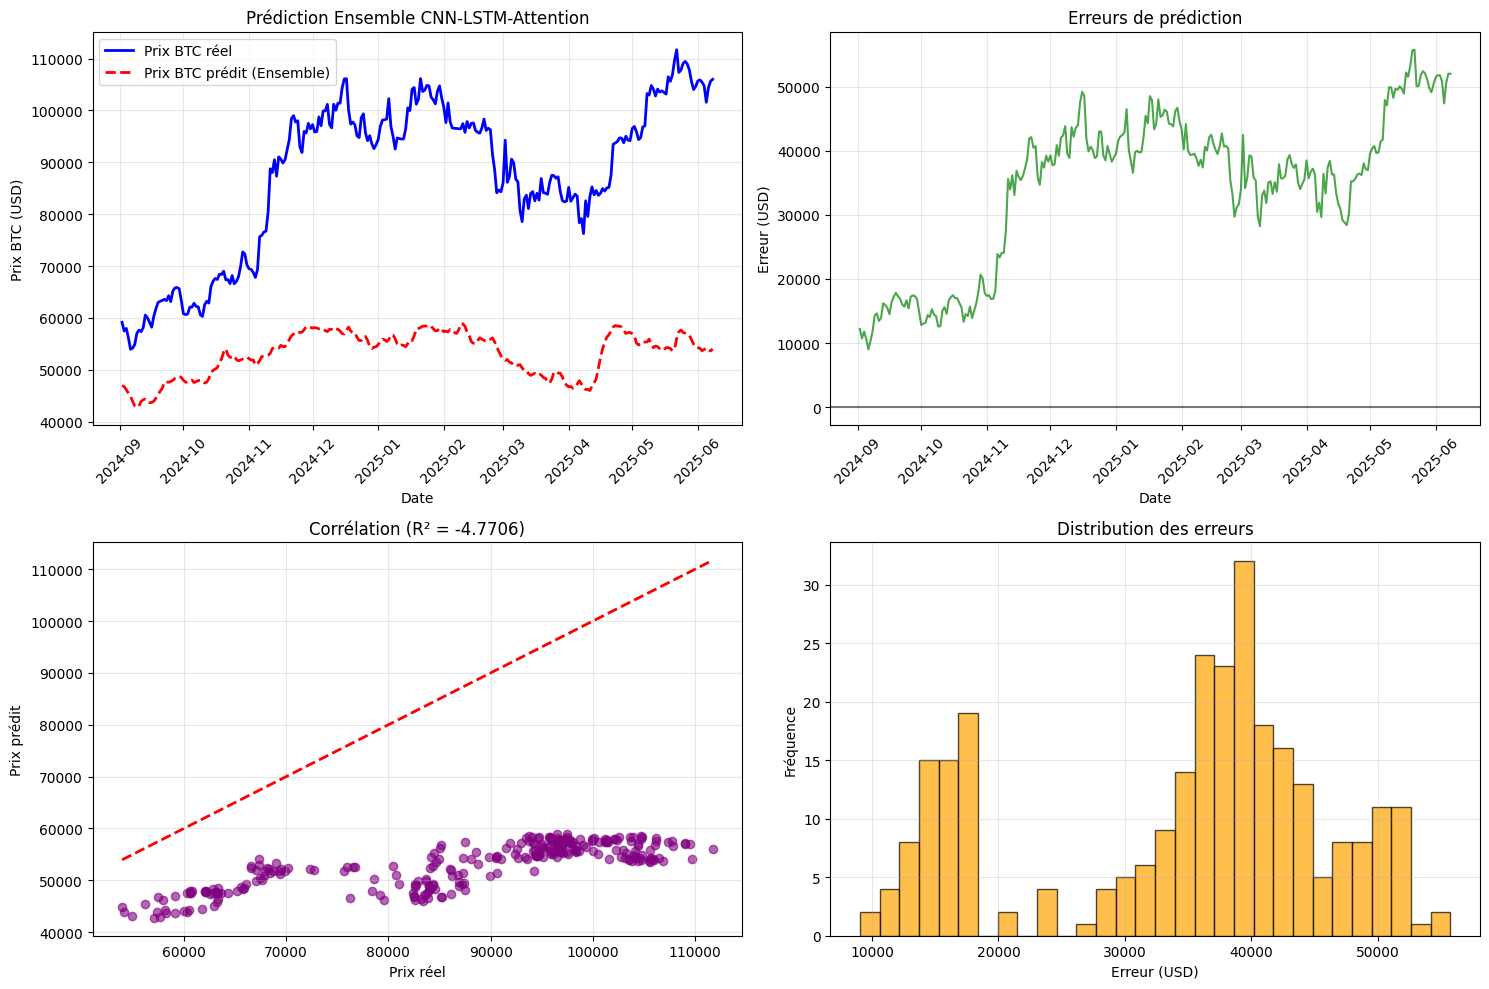


Modèle avancé entraîné avec succès!


In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, Bidirectional, Dense, Dropout,
                                   BatchNormalization, Conv1D, MaxPooling1D,
                                   Flatten, Input, concatenate, Attention,
                                   MultiHeadAttention, LayerNormalization)
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l1_l2
from scipy import stats

# Fonction pour récupérer les données historiques de CryptoCompare
def collect_data_crypto_compare(crypto_symbol, start_timestamp, end_timestamp):
    url = f'https://min-api.cryptocompare.com/data/v2/histoday'
    params = {
        'fsym': crypto_symbol,
        'tsym': 'USD',
        'limit': 2000,
        'toTs': end_timestamp,
        'extraParams': 'crypto_prediction'
    }
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()['Data']['Data']
        df = pd.DataFrame(data)
        df['time'] = pd.to_datetime(df['time'], unit='s')
        return df
    else:
        print(f"Erreur lors de la récupération des données: {response.status_code}")
        return None

# Fonction avancée pour créer des indicateurs techniques manuellement
def create_technical_indicators(df):
    """Créer des indicateurs techniques avancés sans talib"""

    # Moyennes mobiles
    df['sma_7'] = df['close'].rolling(window=7).mean()
    df['sma_21'] = df['close'].rolling(window=21).mean()
    df['sma_50'] = df['close'].rolling(window=50).mean()

    # EMA (Exponential Moving Average)
    df['ema_12'] = df['close'].ewm(span=12).mean()
    df['ema_26'] = df['close'].ewm(span=26).mean()

    # MACD
    df['macd'] = df['ema_12'] - df['ema_26']
    df['macd_signal'] = df['macd'].ewm(span=9).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']

    # RSI (Relative Strength Index)
    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['rsi'] = calculate_rsi(df['close'])

    # Bollinger Bands
    bb_period = 20
    df['bb_middle'] = df['close'].rolling(window=bb_period).mean()
    bb_std = df['close'].rolling(window=bb_period).std()
    df['bb_upper'] = df['bb_middle'] + (bb_std * 2)
    df['bb_lower'] = df['bb_middle'] - (bb_std * 2)
    df['bb_width'] = df['bb_upper'] - df['bb_lower']
    df['bb_position'] = (df['close'] - df['bb_lower']) / df['bb_width']

    # Stochastic Oscillator
    def calculate_stochastic(high, low, close, k_period=14, d_period=3):
        lowest_low = low.rolling(window=k_period).min()
        highest_high = high.rolling(window=k_period).max()
        k_percent = 100 * ((close - lowest_low) / (highest_high - lowest_low))
        d_percent = k_percent.rolling(window=d_period).mean()
        return k_percent, d_percent

    df['stoch_k'], df['stoch_d'] = calculate_stochastic(df['high'], df['low'], df['close'])

    # Williams %R
    def calculate_williams_r(high, low, close, period=14):
        highest_high = high.rolling(window=period).max()
        lowest_low = low.rolling(window=period).min()
        williams_r = -100 * ((highest_high - close) / (highest_high - lowest_low))
        return williams_r

    df['williams_r'] = calculate_williams_r(df['high'], df['low'], df['close'])

    # CCI (Commodity Channel Index)
    def calculate_cci(high, low, close, period=20):
        typical_price = (high + low + close) / 3
        sma = typical_price.rolling(window=period).mean()
        mean_deviation = typical_price.rolling(window=period).apply(
            lambda x: np.mean(np.abs(x - x.mean()))
        )
        cci = (typical_price - sma) / (0.015 * mean_deviation)
        return cci

    df['cci'] = calculate_cci(df['high'], df['low'], df['close'])

    # ADX (Average Directional Index) - Version simplifiée
    def calculate_adx(high, low, close, period=14):
        # True Range
        tr1 = high - low
        tr2 = np.abs(high - close.shift())
        tr3 = np.abs(low - close.shift())
        tr = np.maximum(tr1, np.maximum(tr2, tr3))

        # Directional Movement
        dm_plus = np.where((high - high.shift()) > (low.shift() - low),
                          np.maximum(high - high.shift(), 0), 0)
        dm_minus = np.where((low.shift() - low) > (high - high.shift()),
                           np.maximum(low.shift() - low, 0), 0)

        # Smoothed values
        tr_smooth = pd.Series(tr).rolling(window=period).mean()
        dm_plus_smooth = pd.Series(dm_plus).rolling(window=period).mean()
        dm_minus_smooth = pd.Series(dm_minus).rolling(window=period).mean()

        # Directional Indicators
        di_plus = 100 * (dm_plus_smooth / tr_smooth)
        di_minus = 100 * (dm_minus_smooth / tr_smooth)

        # ADX
        dx = 100 * np.abs(di_plus - di_minus) / (di_plus + di_minus)
        adx = dx.rolling(window=period).mean()

        return adx

    df['adx'] = calculate_adx(df['high'], df['low'], df['close'])

    # Volume indicators
    if 'volumefrom' in df.columns:
        df['volume_sma'] = df['volumefrom'].rolling(window=10).mean()
        df['volume_ratio'] = df['volumefrom'] / df['volume_sma']
    else:
        df['volume_sma'] = 1
        df['volume_ratio'] = 1

    # Patterns de chandelier simplifiés
    def is_doji(open_price, high, low, close, threshold=0.1):
        body = np.abs(close - open_price)
        range_hl = high - low
        return (body / range_hl) < threshold

    def is_hammer(open_price, high, low, close):
        body = np.abs(close - open_price)
        lower_shadow = np.minimum(open_price, close) - low
        upper_shadow = high - np.maximum(open_price, close)
        return (lower_shadow > 2 * body) & (upper_shadow < body)

    df['doji'] = is_doji(df['open'], df['high'], df['low'], df['close']).astype(int)
    df['hammer'] = is_hammer(df['open'], df['high'], df['low'], df['close']).astype(int)

    # Pattern engulfing simplifié
    df['engulfing'] = ((df['close'] > df['open']) &
                      (df['close'].shift() < df['open'].shift()) &
                      (df['close'] > df['open'].shift()) &
                      (df['open'] < df['close'].shift())).astype(int)

    # Volatilité et momentum
    df['volatility'] = df['close'].rolling(window=10).std()
    df['price_change'] = df['close'].pct_change()
    df['high_low_ratio'] = df['high'] / df['low']

    # Momentum indicators
    df['momentum'] = df['close'] - df['close'].shift(10)
    df['rate_of_change'] = df['close'].pct_change(periods=10) * 100

    return df

# Fonction pour prétraiter les données avec des features avancées
def preprocess_data_advanced(btc_df, eth_df):
    # Ajouter des indicateurs techniques pour chaque crypto
    btc_enhanced = create_technical_indicators(btc_df.copy())
    eth_enhanced = create_technical_indicators(eth_df.copy())

    # Fusionner les données avec suffixes
    df = pd.merge(btc_enhanced, eth_enhanced, on='time', suffixes=('_btc', '_eth'))

    # Ajouter des features de corrélation et de relation entre BTC et ETH
    df['btc_eth_ratio'] = df['close_btc'] / df['close_eth']
    df['btc_eth_correlation'] = df['close_btc'].rolling(window=30).corr(df['close_eth'])
    df['price_spread'] = df['close_btc'] - df['close_eth'] * df['btc_eth_ratio'].rolling(30).mean()

    # Features temporelles
    df['day_of_week'] = df['time'].dt.dayofweek
    df['month'] = df['time'].dt.month
    df['quarter'] = df['time'].dt.quarter
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Features cycliques pour capturer la saisonnalité
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Trier par ordre chronologique
    df = df.sort_values('time')

    # Supprimer les lignes avec des valeurs NaN
    df.dropna(inplace=True)

    return df

# Fonction pour créer des séquences avancées avec multi-features
def create_advanced_sequences(data, target_col, feature_cols, seq_length=60):
    X, y = [], []

    for i in range(len(data) - seq_length):
        # Extraire la séquence de features
        sequence = data[feature_cols].iloc[i:i+seq_length].values
        X.append(sequence)

        # Target (prix BTC au temps t+1)
        y.append(data[target_col].iloc[i+seq_length])

    return np.array(X), np.array(y)

# Modèle hybride CNN-LSTM-Attention
def build_advanced_model(seq_length, n_features):
    # Input layer
    input_layer = Input(shape=(seq_length, n_features))

    # CNN branch pour capturer les patterns locaux
    conv1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_layer)
    conv1 = BatchNormalization()(conv1)
    conv1 = Dropout(0.2)(conv1)

    conv2 = Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')(conv1)
    conv2 = BatchNormalization()(conv2)
    conv2 = Dropout(0.2)(conv2)

    # LSTM bidirectionnel pour capturer les dépendances temporelles
    lstm1 = Bidirectional(LSTM(128, return_sequences=True,
                              kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))(conv2)
    lstm1 = BatchNormalization()(lstm1)
    lstm1 = Dropout(0.3)(lstm1)

    lstm2 = Bidirectional(LSTM(64, return_sequences=True,
                              kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))(lstm1)
    lstm2 = BatchNormalization()(lstm2)
    lstm2 = Dropout(0.3)(lstm2)

    # Attention mechanism
    attention = MultiHeadAttention(num_heads=8, key_dim=64)(lstm2, lstm2)
    attention = LayerNormalization()(attention)
    attention = Dropout(0.2)(attention)

    # GRU layer pour plus de complexité
    gru = GRU(64, return_sequences=False,
              kernel_regularizer=l1_l2(l1=0.01, l2=0.01))(attention)
    gru = BatchNormalization()(gru)
    gru = Dropout(0.3)(gru)

    # Dense layers avec regularisation
    dense1 = Dense(128, activation='relu',
                   kernel_regularizer=l1_l2(l1=0.01, l2=0.01))(gru)
    dense1 = BatchNormalization()(dense1)
    dense1 = Dropout(0.4)(dense1)

    dense2 = Dense(64, activation='relu',
                   kernel_regularizer=l1_l2(l1=0.01, l2=0.01))(dense1)
    dense2 = BatchNormalization()(dense2)
    dense2 = Dropout(0.3)(dense2)

    dense3 = Dense(32, activation='relu')(dense2)
    dense3 = Dropout(0.2)(dense3)

    # Output layer
    output = Dense(1, activation='linear')(dense3)

    model = Model(inputs=input_layer, outputs=output)

    # Optimizer avec learning rate adaptatif
    optimizer = Adam(learning_rate=0.0005, beta_1=0.9, beta_2=0.999, epsilon=1e-07)

    model.compile(optimizer=optimizer,
                  loss='huber',  # Plus robuste aux outliers que MSE
                  metrics=['mae', 'mse'])

    return model

# Fonction d'ensemble avec plusieurs modèles
def create_ensemble_models(seq_length, n_features):
    models = []

    # Modèle 1: CNN-LSTM
    model1 = build_advanced_model(seq_length, n_features)
    models.append(model1)

    # Modèle 2: LSTM simple mais profond
    model2 = Sequential([
        LSTM(256, return_sequences=True, input_shape=(seq_length, n_features)),
        Dropout(0.3),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    model2.compile(optimizer=Adam(learning_rate=0.001),
                   loss='huber', metrics=['mae', 'mse'])
    models.append(model2)

    # Modèle 3: GRU bidirectionnel
    model3 = Sequential([
        Bidirectional(GRU(128, return_sequences=True, input_shape=(seq_length, n_features))),
        Dropout(0.3),
        Bidirectional(GRU(64, return_sequences=False)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    model3.compile(optimizer=RMSprop(learning_rate=0.001),
                   loss='huber', metrics=['mae', 'mse'])
    models.append(model3)

    return models

def main_advanced(bitcoin_data, ethereum_data):
    if bitcoin_data is None or ethereum_data is None:
        print("Erreur : Les données n'ont pas pu être récupérées correctement.")
        return None

    # Prétraitement avancé des données
    print("Prétraitement des données avec indicateurs techniques...")
    data = preprocess_data_advanced(bitcoin_data, ethereum_data)

    # Sélection des features importantes
    feature_cols = [
        'close_btc', 'close_eth',
        'sma_7_btc', 'sma_21_btc', 'sma_50_btc', 'ema_12_btc', 'ema_26_btc',
        'sma_7_eth', 'sma_21_eth', 'sma_50_eth', 'ema_12_eth', 'ema_26_eth',
        'macd_btc', 'macd_signal_btc', 'macd_hist_btc',
        'macd_eth', 'macd_signal_eth', 'macd_hist_eth',
        'rsi_btc', 'rsi_eth', 'bb_position_btc', 'bb_position_eth',
        'stoch_k_btc', 'stoch_d_btc', 'stoch_k_eth', 'stoch_d_eth',
        'adx_btc', 'adx_eth', 'williams_r_btc', 'williams_r_eth',
        'cci_btc', 'cci_eth', 'volatility_btc', 'volatility_eth',
        'momentum_btc', 'momentum_eth', 'rate_of_change_btc', 'rate_of_change_eth',
        'btc_eth_ratio', 'btc_eth_correlation', 'price_spread',
        'day_sin', 'day_cos', 'month_sin', 'month_cos', 'is_weekend',
        'volume_ratio_btc', 'volume_ratio_eth'
    ]

    # Garder seulement les colonnes existantes
    available_cols = [col for col in feature_cols if col in data.columns]
    print(f"Utilisation de {len(available_cols)} features")

    # Normalisation robuste
    scaler = RobustScaler()  # Plus robuste aux outliers
    scaled_data = pd.DataFrame(
        scaler.fit_transform(data[available_cols]),
        columns=available_cols,
        index=data.index
    )

    # Scaler séparé pour le target
    target_scaler = MinMaxScaler()
    target_col = 'close_btc'
    scaled_target = target_scaler.fit_transform(data[[target_col]])
    scaled_data[target_col] = scaled_target

    # Création des séquences avec une longueur plus importante
    seq_length = 90  # Séquences plus longues pour capturer plus de patterns
    X, y = create_advanced_sequences(scaled_data, target_col, available_cols, seq_length)

    print(f"Shape des données: X={X.shape}, y={y.shape}")

    # Division train/validation/test
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)

    X_train = X[:train_size]
    X_val = X[train_size:train_size+val_size]
    X_test = X[train_size+val_size:]

    y_train = y[:train_size]
    y_val = y[train_size:train_size+val_size]
    y_test = y[train_size+val_size:]

    # Créer les modèles d'ensemble
    models = create_ensemble_models(seq_length, len(available_cols))

    # Callbacks avancés
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1),
        ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
    ]

    # Entraîner les modèles
    trained_models = []
    predictions = []

    for i, model in enumerate(models):
        print(f"\nEntraînement du modèle {i+1}/3...")

        history = model.fit(
            X_train, y_train,
            epochs=150,
            batch_size=64,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )

        # Prédictions
        y_pred = model.predict(X_test, verbose=0)
        predictions.append(y_pred.flatten())
        trained_models.append(model)

    # Ensemble des prédictions (moyenne pondérée)
    weights = [0.4, 0.35, 0.25]  # Poids pour chaque modèle
    ensemble_pred = np.average(predictions, axis=0, weights=weights)

    # Inverser la normalisation
    y_test_real = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_real = target_scaler.inverse_transform(ensemble_pred.reshape(-1, 1)).flatten()

    # Évaluation avancée
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)

    # Métriques additionnelles
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
    directional_accuracy = np.mean(np.sign(np.diff(y_test_real)) == np.sign(np.diff(y_pred_real))) * 100

    print(f"\n=== RÉSULTATS DU MODÈLE AVANCÉ ===")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Précision directionnelle: {directional_accuracy:.2f}%")

    # Visualisation avancée
    plt.figure(figsize=(15, 10))

    # Récupérer les dates correspondantes
    test_dates = data['time'].iloc[-len(y_test):].values

    # Graphique principal
    plt.subplot(2, 2, 1)
    plt.plot(test_dates, y_test_real, label='Prix BTC réel', color='blue', linewidth=2)
    plt.plot(test_dates, y_pred_real, label='Prix BTC prédit (Ensemble)',
             color='red', linestyle='--', linewidth=2)
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.title('Prédiction Ensemble CNN-LSTM-Attention')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    # Graphique des erreurs
    plt.subplot(2, 2, 2)
    errors = y_test_real - y_pred_real
    plt.plot(test_dates, errors, color='green', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.xlabel('Date')
    plt.ylabel('Erreur (USD)')
    plt.title('Erreurs de prédiction')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    # Scatter plot
    plt.subplot(2, 2, 3)
    plt.scatter(y_test_real, y_pred_real, alpha=0.6, color='purple')
    plt.plot([y_test_real.min(), y_test_real.max()],
             [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
    plt.xlabel('Prix réel')
    plt.ylabel('Prix prédit')
    plt.title(f'Corrélation (R² = {r2:.4f})')
    plt.grid(True, alpha=0.3)

    # Distribution des erreurs
    plt.subplot(2, 2, 4)
    plt.hist(errors, bins=30, alpha=0.7, color='orange', edgecolor='black')
    plt.xlabel('Erreur (USD)')
    plt.ylabel('Fréquence')
    plt.title('Distribution des erreurs')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return trained_models, scaler, target_scaler, available_cols

# Exécution du script principal
if __name__ == "__main__":
    # Récupérer les données
    today = datetime.today()
    end_timestamp = int(time.mktime(today.timetuple()))
    start_timestamp = 1577836800  # Début 2020 pour plus de données

    print("Récupération des données Bitcoin...")
    btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)

    print("Récupération des données Ethereum...")
    eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

    if btc_data is not None and eth_data is not None:
        print(f"Données récupérées: BTC={len(btc_data)} jours, ETH={len(eth_data)} jours")
        models, scaler, target_scaler, feature_cols = main_advanced(btc_data, eth_data)
        print("\nModèle avancé entraîné avec succès!")
    else:
        print("Erreur lors de la récupération des données.")

### Utilisation des autoencodeurs

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6429 - mae: 0.5729 - val_loss: 0.0980 - val_mae: 0.2164
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1147 - mae: 0.2471 - val_loss: 0.0569 - val_mae: 0.1555
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0654 - mae: 0.1937 - val_loss: 0.0490 - val_mae: 0.1410
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0450 - mae: 0.1612 - val_loss: 0.0550 - val_mae: 0.1486
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0382 - mae: 0.1535 - val_loss: 0.0439 - val_mae: 0.1348
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0391 - mae: 0.1518 - val_loss: 0.0411 - val_mae: 0.1307
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0304 - mae: 0.1367 - val_loss: 0.0384 - val_mae: 0.1263
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0296 - mae: 0.1333 - val_loss: 0.0466 - v

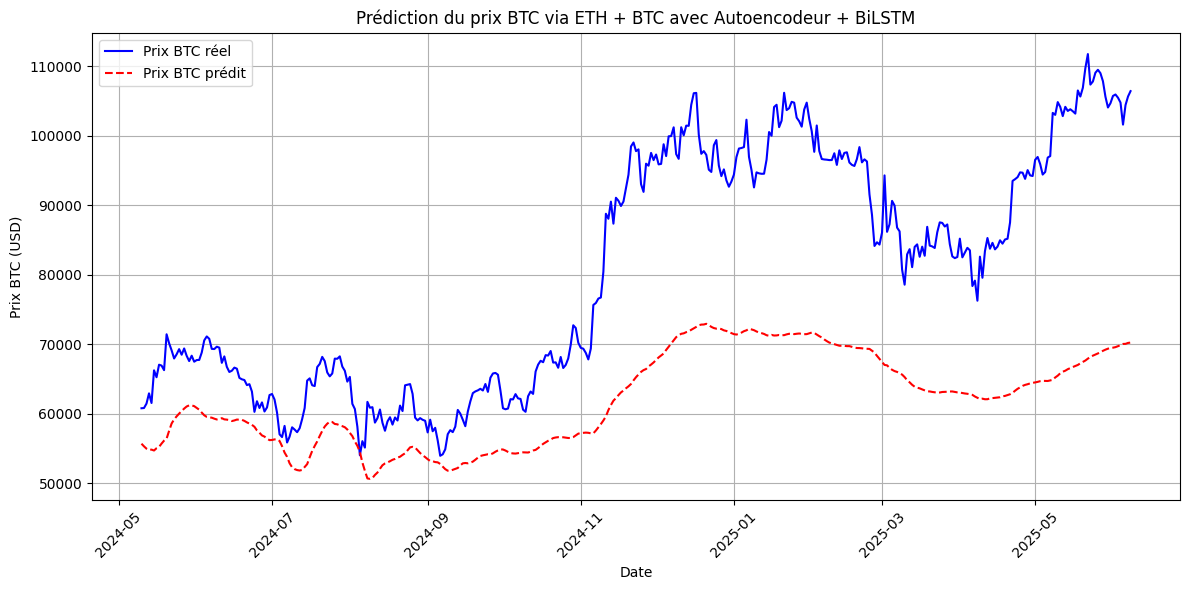

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Simuler ta fonction de récupération ici (à adapter)
def collect_data_crypto_compare(symbol, start_ts, end_ts):
    url = f"https://min-api.cryptocompare.com/data/v2/histoday?fsym={symbol}&tsym=USD&limit=2000&toTs={end_ts}"
    import requests
    r = requests.get(url)
    df = pd.DataFrame(r.json()['Data']['Data'])
    df['time'] = pd.to_datetime(df['time'], unit='s')
    return df

# 1. Récupération des données
start_timestamp = int(datetime(2017, 1, 1).timestamp())
end_timestamp = int(datetime.now().timestamp())

btc_data = collect_data_crypto_compare('BTC', start_timestamp, end_timestamp)
eth_data = collect_data_crypto_compare('ETH', start_timestamp, end_timestamp)

# 2. Prétraitement
def preprocess_data(btc_df, eth_df):
    df = pd.merge(btc_df[['time', 'close']], eth_df[['time', 'close']], on='time', suffixes=('_btc', '_eth'))
    df = df.sort_values('time')
    df.dropna(inplace=True)
    return df

data = preprocess_data(btc_data, eth_data)

# 3. Normalisation (StandardScaler)
btc_scaler = StandardScaler()
eth_scaler = StandardScaler()

btc_scaled = btc_scaler.fit_transform(data[['close_btc']])
eth_scaled = eth_scaler.fit_transform(data[['close_eth']])

# 4. Création de séquences (BTC + ETH)
def create_sequences(features, targets, seq_length=30):
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i+seq_length])
        y.append(targets[i+seq_length])
    return np.array(X), np.array(y)

features_scaled = np.hstack((eth_scaled, btc_scaled))
X, y = create_sequences(features_scaled, btc_scaled, seq_length=30)

# Division train/test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. Autoencodeur pour encoder X en représentations latentes
timesteps = X.shape[1]
n_features = X.shape[2]
encoding_dim = 32

# Autoencoder
input_seq = Input(shape=(timesteps, n_features))
encoded = Bidirectional(LSTM(64, return_sequences=False))(input_seq)
bottleneck = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(timesteps * n_features)(bottleneck)

autoencoder = Model(input_seq, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train, X_train.reshape((X_train.shape[0], -1)),
                epochs=50, batch_size=32, validation_split=0.2,
                callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
                verbose=0)

# Encoder
encoder = Model(input_seq, bottleneck)
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

# 6. Modèle BiLSTM pour prédiction
def build_predictor_model(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(64, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)
    model = Model(inputs, output)
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

model = build_predictor_model(encoding_dim)
history = model.fit(X_train_encoded, y_train, epochs=100, batch_size=32,
                    validation_split=0.2, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
                    verbose=1)

# 7. Prédiction et évaluation
y_pred = model.predict(X_test_encoded)

y_test_inv = btc_scaler.inverse_transform(y_test)
y_pred_inv = btc_scaler.inverse_transform(y_pred)

mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

# 8. Visualisation
dates = data['time'].iloc[-len(y_test):]

plt.figure(figsize=(12,6))
plt.plot(dates, y_test_inv, label="Prix BTC réel", color="blue")
plt.plot(dates, y_pred_inv, label="Prix BTC prédit", color="red", linestyle="--")
plt.title("Prédiction du prix BTC via ETH + BTC avec Autoencodeur + BiLSTM")
plt.xlabel("Date")
plt.ylabel("Prix BTC (USD)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Récupération des données BTC...
Données BTC récupérées: 1987 jours
Récupération des données ETH...
Données ETH récupérées: 1987 jours
Données BTC: 1987 points
Données ETH: 1987 points
Données fusionnées: 1987 points
Après nettoyage: 1986 points
Features utilisées: 14
Séquences créées: (1925, 60, 14), (1925,)
Train: (1473, 60, 14), Val: (163, 60, 14), Test: (289, 60, 14)
Modèle créé avec 86983 paramètres

Début de l'entraînement...
Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 35s 306ms/step - loss: 0.6018 - mae: 0.5611 - mse: 0.5423 - val_loss: 0.5938 - val_mae: 0.6903 - val_mse: 0.4895 - learning_rate: 0.0010
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - loss: 0.4070 - mae: 0.2781 - mse: 0.1267 - val_loss: 0.5471 - val_mae: 0.6554 - val_mse: 0.4404 - learning_rate: 0.0010
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 261ms/step - loss: 0.3647 - mae: 0.2353 - mse: 0.0876 - val_loss: 0.4945 - val_mae: 0.6135 - val_mse: 0.3840 - learning_rate: 0.0010
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━

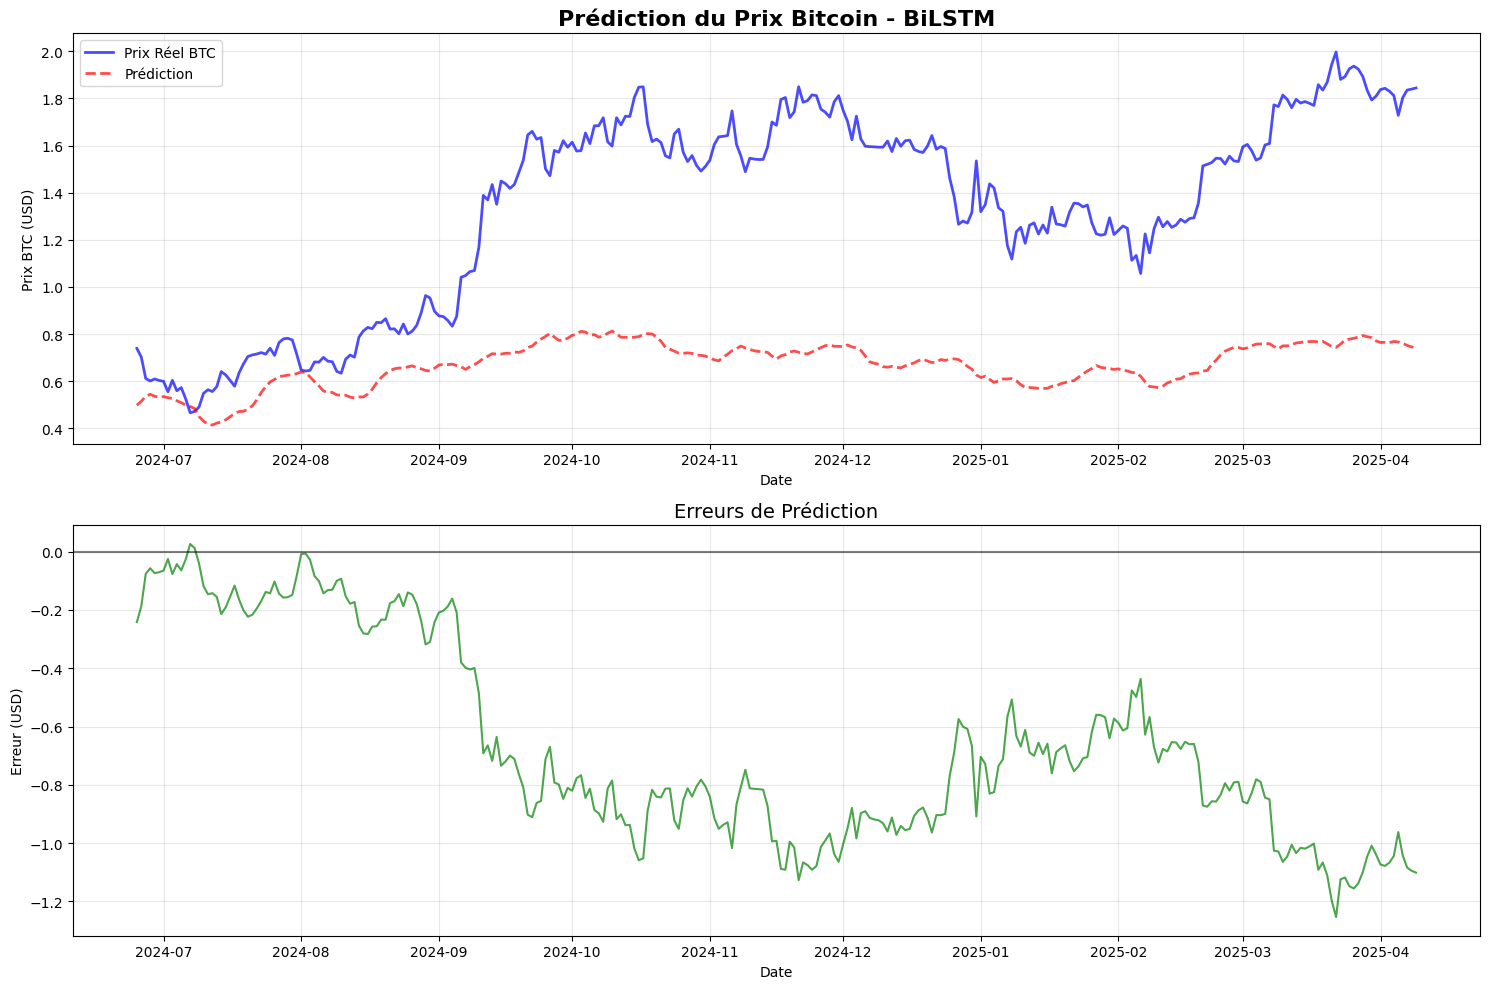

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber
import time
import warnings
warnings.filterwarnings('ignore')

# Configuration
START_DATE = '2020-01-01'  # Période plus récente pour plus de données
SEQ_LENGTH = 60
TEST_SIZE = 0.15
FEATURES = [
    'close_eth', 'volume_eth', 'eth_ma7', 'eth_ma21', 'eth_rsi', 'eth_macd',
    'close_btc', 'volume_btc', 'btc_ma7', 'btc_ma21', 'btc_rsi', 'btc_macd',
    'btc_eth_ratio', 'correlation_7d'
]

def fetch_crypto_data(symbol, start_timestamp, end_timestamp):
    """Récupère les données historiques avec gestion d'erreurs améliorée"""
    url = 'https://min-api.cryptocompare.com/data/v2/histoday'
    all_data = []
    toTs = end_timestamp

    print(f"Récupération des données {symbol}...")

    while True:
        params = {
            'fsym': symbol,
            'tsym': 'USD',
            'limit': 2000,
            'toTs': toTs
        }

        success = False
        for attempt in range(3):
            try:
                response = requests.get(url, params=params, timeout=15)
                response.raise_for_status()

                data_json = response.json()
                if 'Data' not in data_json or 'Data' not in data_json['Data']:
                    print(f"Structure de données inattendue pour {symbol}")
                    return None

                data = data_json['Data']['Data']
                if not data:
                    break

                all_data.extend(data)
                toTs = data[0]['time'] - 86400  # -1 jour
                success = True
                break

            except Exception as e:
                print(f"Tentative {attempt + 1} échouée pour {symbol}: {e}")
                if attempt < 2:
                    time.sleep(3)

        if not success:
            print(f"Impossible de récupérer les données pour {symbol}")
            return None

        if toTs < start_timestamp:
            break

        time.sleep(0.5)  # Rate limiting

    if not all_data:
        print(f"Aucune donnée récupérée pour {symbol}")
        return None

    df = pd.DataFrame(all_data)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df = df[df['time'] >= pd.to_datetime(START_DATE)].copy()

    # Vérification des colonnes nécessaires
    required_cols = ['close', 'volumefrom']
    if not all(col in df.columns for col in required_cols):
        print(f"Colonnes manquantes dans les données {symbol}")
        return None

    print(f"Données {symbol} récupérées: {len(df)} jours")
    return df.sort_values('time').reset_index(drop=True)

def calculate_technical_indicators(df, prefix):
    """Calcule les indicateurs techniques avec gestion des NaN"""
    close_col = f'close_{prefix}'

    if close_col not in df.columns:
        print(f"Colonne {close_col} manquante")
        return df

    # Moyennes Mobiles
    df[f'{prefix}_ma7'] = df[close_col].rolling(window=7, min_periods=1).mean()
    df[f'{prefix}_ma21'] = df[close_col].rolling(window=21, min_periods=1).mean()

    # RSI
    delta = df[close_col].diff()
    gain = delta.where(delta > 0, 0).rolling(window=14, min_periods=1).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14, min_periods=1).mean()

    # Éviter la division par zéro
    rs = gain / (loss + 1e-10)
    df[f'{prefix}_rsi'] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = df[close_col].ewm(span=12, adjust=False).mean()
    ema26 = df[close_col].ewm(span=26, adjust=False).mean()
    df[f'{prefix}_macd'] = ema12 - ema26

    return df

def create_sequences(data, features, target, seq_length):
    """Crée des séquences 3D pour le LSTM avec validation"""
    if len(data) < seq_length + 2:
        raise ValueError(f"Pas assez de données. Besoin d'au moins {seq_length + 2} points.")

    X, y = [], []
    feature_data = data[features].values
    target_data = data[target].values

    for i in range(seq_length, len(data) - 1):
        X.append(feature_data[i-seq_length:i])
        y.append(target_data[i+1])  # Prédiction t+1

    return np.array(X), np.array(y)

def build_enhanced_model(input_shape):
    """Architecture BiLSTM optimisée"""
    model = Sequential([
        # Première couche BiLSTM
        Bidirectional(
            LSTM(64, return_sequences=True,
                 dropout=0.2, recurrent_dropout=0.2,
                 kernel_regularizer=l2(0.001)),
            input_shape=input_shape
        ),
        BatchNormalization(),

        # Deuxième couche BiLSTM
        Bidirectional(
            LSTM(32, return_sequences=False,
                 dropout=0.2, recurrent_dropout=0.2,
                 kernel_regularizer=l2(0.001))
        ),
        BatchNormalization(),
        Dropout(0.3),

        # Couches denses
        Dense(50, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])

    # Optimiseur avec taux d'apprentissage adaptatif
    optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
    model.compile(optimizer=optimizer,
                 loss=Huber(delta=1.0),
                 metrics=['mae', 'mse'])

    print(f"Modèle créé avec {model.count_params()} paramètres")
    return model

def evaluate_model(model, X_test, y_test, target_scaler):
    """Évalue le modèle avec métriques détaillées"""
    y_pred = model.predict(X_test, verbose=0)

    # Inverse transform
    y_test_orig = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_orig = target_scaler.inverse_transform(y_pred).flatten()

    # Métriques
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    r2 = r2_score(y_test_orig, y_pred_orig)

    # Précision directionnelle
    actual_direction = np.diff(y_test_orig) > 0
    pred_direction = np.diff(y_pred_orig) > 0
    directional_accuracy = np.mean(actual_direction == pred_direction) * 100

    return {
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'directional_accuracy': directional_accuracy,
        'y_test_orig': y_test_orig,
        'y_pred_orig': y_pred_orig
    }

def plot_results(results, dates):
    """Visualisation améliorée des résultats"""
    plt.figure(figsize=(15, 10))

    # Graphique principal
    plt.subplot(2, 1, 1)
    plt.plot(dates, results['y_test_orig'], label='Prix Réel BTC',
             linewidth=2, color='blue', alpha=0.7)
    plt.plot(dates, results['y_pred_orig'], label='Prédiction',
             linewidth=2, color='red', alpha=0.7, linestyle='--')

    plt.title('Prédiction du Prix Bitcoin - BiLSTM', fontsize=16, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Prix BTC (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Graphique des erreurs
    plt.subplot(2, 1, 2)
    errors = results['y_pred_orig'] - results['y_test_orig']
    plt.plot(dates, errors, color='green', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.title('Erreurs de Prédiction', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Erreur (USD)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def main():
    try:
        # 1. Récupération des données
        end_timestamp = int(datetime.now().timestamp())
        start_timestamp = int(datetime.strptime(START_DATE, '%Y-%m-%d').timestamp())

        btc_data = fetch_crypto_data('BTC', start_timestamp, end_timestamp)
        eth_data = fetch_crypto_data('ETH', start_timestamp, end_timestamp)

        if btc_data is None or eth_data is None:
            print("Erreur: Impossible de récupérer les données")
            return None, None, None

        print(f"Données BTC: {len(btc_data)} points")
        print(f"Données ETH: {len(eth_data)} points")

        # 2. Fusion des données
        merged_data = pd.merge(
            btc_data[['time', 'close', 'volumefrom']].rename(columns={
                'close': 'close_btc',
                'volumefrom': 'volume_btc'
            }),
            eth_data[['time', 'close', 'volumefrom']].rename(columns={
                'close': 'close_eth',
                'volumefrom': 'volume_eth'
            }),
            on='time', how='inner'
        ).sort_values('time').reset_index(drop=True)

        print(f"Données fusionnées: {len(merged_data)} points")

        if len(merged_data) < 100:
            print("Pas assez de données pour l'entraînement")
            return None, None, None

        # 3. Feature Engineering
        merged_data = calculate_technical_indicators(merged_data, 'btc')
        merged_data = calculate_technical_indicators(merged_data, 'eth')

        # Features supplémentaires
        merged_data['btc_eth_ratio'] = merged_data['close_btc'] / (merged_data['close_eth'] + 1e-10)
        merged_data['correlation_7d'] = merged_data['close_btc'].rolling(
            window=7, min_periods=1
        ).corr(merged_data['close_eth'])

        # Nettoyage des NaN
        merged_data.dropna(inplace=True)
        print(f"Après nettoyage: {len(merged_data)} points")

        if len(merged_data) < SEQ_LENGTH + 50:
            print(f"Pas assez de données après nettoyage. Besoin d'au moins {SEQ_LENGTH + 50}")
            return None, None, None

        # 4. Normalisation
        scalers = {}
        for col in FEATURES:
            if col in merged_data.columns:
                scalers[col] = RobustScaler()
                merged_data[col] = scalers[col].fit_transform(merged_data[[col]]).flatten()

        target_scaler = RobustScaler()
        merged_data['target'] = target_scaler.fit_transform(merged_data[['close_btc']]).flatten()

        # 5. Création des séquences
        available_features = [f for f in FEATURES if f in merged_data.columns]
        print(f"Features utilisées: {len(available_features)}")

        X, y = create_sequences(merged_data, available_features, 'target', SEQ_LENGTH)
        print(f"Séquences créées: {X.shape}, {y.shape}")

        # 6. Division des données
        train_size = int(len(X) * (1 - TEST_SIZE))
        val_size = int(train_size * 0.1)

        X_train = X[:train_size-val_size]
        y_train = y[:train_size-val_size]
        X_val = X[train_size-val_size:train_size]
        y_val = y[train_size-val_size:train_size]
        X_test = X[train_size:]
        y_test = y[train_size:]

        print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

        # 7. Construction et entraînement du modèle
        model = build_enhanced_model((SEQ_LENGTH, len(available_features)))

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=10,
                            min_lr=1e-6, verbose=1)
        ]

        print("\nDébut de l'entraînement...")
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=32,
            callbacks=callbacks,
            verbose=1
        )

        # 8. Évaluation
        results = evaluate_model(model, X_test, y_test, target_scaler)

        print("\n" + "="*50)
        print("RÉSULTATS FINAUX")
        print("="*50)
        print(f"MAE: {results['mae']:.2f} USD")
        print(f"RMSE: {results['rmse']:.2f} USD")
        print(f"R²: {results['r2']:.4f}")
        print(f"Précision directionnelle: {results['directional_accuracy']:.1f}%")
        print("="*50)

        # 9. Visualisation
        test_dates = merged_data['time'].iloc[train_size:train_size+len(y_test)].values
        plot_results(results, test_dates)

        return model, scalers, target_scaler

    except Exception as e:
        print(f"Erreur dans main(): {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

if __name__ == "__main__":
    model, scalers, target_scaler = main()